# Complete Analysis: Computational Thinking + History
## Project: CT and History Assessment — Juan Echegaray School

---

| Metadata | Value |
|----------|-------|
| **School** | Juan Echegaray Elementary School |
| **Grade** | 5th Grade Primary — 4 classes (A, B, C, D) |
| **CT Test** | 28 multiple-choice items (A/B/C/D) |
| **History pre-test** | 8 binary-response items (P1–P8) |
| **History post-test** | 11 binary-response items (P1–P11) |
| **Data** | `./data/{test_inicial_pc_echegaray.csv, especificacion_items.csv, autoperception_test_inicial_pc_echegaray.csv, Test_iniciales_v_finales.xlsx}` |
| **Outputs** | `./outputs/{tables/, figures/en/, logs/}` |
| **Seed** | `numpy.random.seed(42)` |

---

### Analysis Objectives

1. **Describe the initial CT performance** of Echegaray students: global distribution, by class, gender and SEN; psychometric item analysis by computational concept and required task.
2. **Examine students' self-perception** about their performance and its relationship with actual performance (at aggregate group level, given the absence of individual ID).
3. **Classify classes by CT level** (Low / Medium / High using tertiles on the class mean) to use as a moderating variable in sections 7 and 8.
4. **Analyse History learning** (pre-post design, **independent samples** by class): Hake **group-level gain** per class (without individual matching) and the effect of CT level on the gain.
5. **Explore satisfaction ratings** for activities, crossed with the CT level of the class, and their possible relationship with learning gain.
6. **Export and verify** all outputs through automatic quality gates that guarantee reproducibility of the analysis.

---

### Notebook Structure

| Section | Content |
|---------|-----------|
| **0 · Setup** | Libraries, seed, paths, logger, utility functions and table-styling helper |
| **1 · Loading & Audit** | Robust loading of all datasets; data-quality audit table exported |
| **2 · CT Test: Format + Correct Answers** | Automatic detection of response format; score per student, task and concept |
| **3 · CT Descriptives** | Global and group distribution; items × class heatmap; barplots by concept |
| **4 · CT Contrasts** | Significant differences by Gender and SEN; automatic methodological decision |
| **5 · Self-Perception** | Self-perception vs. actual performance contrast at aggregate group level |
| **6 · CT Level by Class** | Tertile classification (Low/Medium/High) as moderating variable |
| **7 · History** | Pre-post analysis (independent samples); group Hake gain per class; ANOVA; OLS model |
| **8 · Ratings** | Activity satisfaction by activity × CT level; ranking; rating–gain correlation |
| **9 · Methodological Reflection** | The five pillars of CT applied to the analysis pipeline |
| **10 · Quality Gates** | Automatic verification of all outputs and data invariants |

---

### Key Methodological Note

> **History — independent samples design:** The `Student` index in the data represents the response order, not the same student across both tests. Therefore, **individual observations cannot be paired**. The Hake gain is calculated at the **class** level (over group means):
>
> $$g = \frac{\text{pct\_fin} - \text{pct\_ini}}{1 - \text{pct\_ini}}$$
>
> **CT level as moderator:** The level (Low/Medium/High) is assigned at the **class** level, not the individual student level. It is only applied to Echegaray classes to avoid imputing levels to schools without CT data.
>
> **Self-perception — explicit limitation:** Without an ID column in the self-perception dataset, comparison with actual performance is only possible at the group mean level. No individual correlations are performed.

### Reproducibility Note

> This notebook is **self-contained**. Install dependencies with `pip install -r requirements.txt`.
> Running all cells in order (with seed `np.random.seed(42)`) fully regenerates all outputs in `./outputs/`.
> **Section 10 (Quality Gates)** automatically verifies the integrity of each output file.


## 0. Setup and Configuration

**What this section does:** Imports all libraries, fixes the random seed (`np.random.seed(42)`), creates output directories, configures the data-quality logger and defines shared utility functions: robust CSV/Excel reading, normality detection, Hedges g, rank-biserial, bootstrap CI and permutation test. Finally adds the `style_table()` helper for uniform-style tables throughout the notebook.

**Why:** Centralising configuration and functions in the first block guarantees exact reproducibility (same seed → same results in bootstrap and permutations) and allows reusing utilities in any section without duplicating code.


In [2]:
# ─────────────────────────────────────────────────────────────────
# 0.1  Imports y semilla
# ─────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import os
import sys
# Ensure stdout/stderr use UTF-8 on Windows to avoid cp1252 issues
if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8", errors="replace")
if hasattr(sys.stderr, "reconfigure"):
    sys.stderr.reconfigure(encoding="utf-8", errors="replace")

import logging
import pathlib
import re
import itertools

import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.weightstats import DescrStatsW

import matplotlib
# Use Agg backend when running as plain script (non-interactive / CI)
# In a Jupyter kernel the inline magic overrides this automatically.
import sys as _sys
if not hasattr(_sys, "ps1") and "ipykernel" not in _sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

np.random.seed(42)

# ─────────────────────────────────────────────────────────────────
# 0.2  Opciones de pandas y estilo básico
# ─────────────────────────────────────────────────────────────────
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 80)
pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.width", 120)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
matplotlib.rcParams.update({"figure.dpi": 110, "figure.figsize": (9, 5)})

# ─────────────────────────────────────────────────────────────────
# 0.3  Rutas
# ─────────────────────────────────────────────────────────────────
ROOT   = pathlib.Path(".")
DATA   = ROOT / "data"
OUT    = ROOT / "outputs"
FIGS   = OUT / "figures" / "en"
TABS   = OUT / "tables"
LOGS   = OUT / "logs"

for d in [FIGS, TABS, LOGS]:
    d.mkdir(parents=True, exist_ok=True)

# ─────────────────────────────────────────────────────────────────
# 0.4  Logger
# ─────────────────────────────────────────────────────────────────
log_path = LOGS / "data_quality.log"
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    handlers=[
        logging.FileHandler(log_path, mode="w", encoding="utf-8"),
        logging.StreamHandler(sys.stdout),
    ],
)
logger = logging.getLogger("pc_hist")
logger.info("=== Start of CT + History Analysis ===")

# ─────────────────────────────────────────────────────────────────
# 0.5  Funciones utilitarias
# ─────────────────────────────────────────────────────────────────
def safe_read_csv(path, **kwargs):
    """Reads CSV with automatic separator and encoding detection."""
    path = pathlib.Path(path)
    for enc in ["utf-8", "latin-1", "cp1252"]:
        for sep in [",", ";", "\t"]:
            try:
                df = pd.read_csv(path, encoding=enc, sep=sep, **kwargs)
                if df.shape[1] > 1:
                    logger.info(f"CSV loaded: {path.name} | enc={enc} sep='{sep}' | {df.shape}")
                    return df
            except Exception:
                pass
    # Fallback: engine python, sep=None
    df = pd.read_csv(path, sep=None, engine="python", **kwargs)
    logger.info(f"CSV loaded (fallback python engine): {path.name} | {df.shape}")
    return df


def safe_read_excel(path, sheet_name=0, **kwargs):
    """Reads Excel sheet with error handling."""
    path = pathlib.Path(path)
    try:
        df = pd.read_excel(path, sheet_name=sheet_name, **kwargs)
        logger.info(f"Excel loaded: {path.name} sheet='{sheet_name}' | {df.shape}")
        return df
    except Exception as e:
        logger.error(f"Error reading {path.name} sheet={sheet_name}: {e}")
        return pd.DataFrame()


def ensure_numeric(series, col_name=""):
    """Converts to numeric; invalid values → NaN."""
    result = pd.to_numeric(series, errors="coerce")
    n_bad = series.notna().sum() - result.notna().sum()
    if n_bad > 0:
        logger.warning(f"  '{col_name}': {n_bad} non-numeric values → NaN")
    return result


def coerce_01(series, col_name=""):
    """Forces to {0,1,NaN}; any value outside → NaN."""
    s = ensure_numeric(series, col_name)
    mask_invalid = s.notna() & ~s.isin([0, 1])
    if mask_invalid.sum() > 0:
        logger.warning(f"  '{col_name}': {mask_invalid.sum()} values ∉ {{0,1}} → NaN")
        s.loc[mask_invalid] = np.nan
    return s


def log_anomaly(msg):
    """Records an anomaly in the log."""
    logger.warning(f"[ANOMALY] {msg}")


def bootstrap_ci(data, stat_fn=np.mean, n_boot=2000, ci=95, seed=42):
    """Percentile bootstrap CI for a statistic."""
    rng = np.random.default_rng(seed)
    data = np.asarray(data, dtype=float)
    data = data[~np.isnan(data)]
    if len(data) < 2:
        return (np.nan, np.nan)
    boots = [stat_fn(rng.choice(data, size=len(data), replace=True)) for _ in range(n_boot)]
    lo = np.percentile(boots, (100 - ci) / 2)
    hi = np.percentile(boots, 100 - (100 - ci) / 2)
    return (lo, hi)


def hedges_g(a, b):
    """Hedges g with approximate 95% CI (Borenstein 2009)."""
    a, b = np.asarray(a, float), np.asarray(b, float)
    a, b = a[~np.isnan(a)], b[~np.isnan(b)]
    n1, n2 = len(a), len(b)
    if n1 < 2 or n2 < 2:
        return np.nan, (np.nan, np.nan)
    d = (np.mean(a) - np.mean(b)) / np.sqrt(
        ((n1 - 1) * np.var(a, ddof=1) + (n2 - 1) * np.var(b, ddof=1)) / (n1 + n2 - 2)
    )
    j = 1 - 3 / (4 * (n1 + n2 - 2) - 1)
    g = d * j
    se_g = np.sqrt((n1 + n2) / (n1 * n2) + g**2 / (2 * (n1 + n2 - 2)))
    return g, (g - 1.96 * se_g, g + 1.96 * se_g)


def rank_biserial(a, b):
    """Rank-biserial correlation (Cliff's delta) for Mann-Whitney."""
    a, b = np.asarray(a, float), np.asarray(b, float)
    a, b = a[~np.isnan(a)], b[~np.isnan(b)]
    n1, n2 = len(a), len(b)
    if n1 < 1 or n2 < 1:
        return np.nan
    stat, _ = stats.mannwhitneyu(a, b, alternative="two-sided")
    r = 1 - (2 * stat) / (n1 * n2)
    return r


def permutation_test(a, b, n_perm=5000, seed=42):
    """Permutation test on mean difference."""
    rng = np.random.default_rng(seed)
    a, b = np.asarray(a, float), np.asarray(b, float)
    a, b = a[~np.isnan(a)], b[~np.isnan(b)]
    if len(a) < 2 or len(b) < 2:
        return np.nan
    obs = np.abs(np.mean(a) - np.mean(b))
    combined = np.concatenate([a, b])
    count = 0
    for _ in range(n_perm):
        rng.shuffle(combined)
        count += np.abs(np.mean(combined[:len(a)]) - np.mean(combined[len(a):])) >= obs
    return count / n_perm


def shapiro_ok(x, alpha=0.05):
    """True if normality not rejected (N < 50) or N >= 50 (not applicable)."""
    x = np.asarray(x, float)
    x = x[~np.isnan(x)]
    if len(x) < 3:
        return False
    if len(x) >= 50:
        return False  # Shapiro no fiable con N>=50; preferir MWU
    _, p = stats.shapiro(x)
    return p > alpha


def choose_test(a, b, alpha=0.05):
    """Selects Welch t or Mann-Whitney based on assumptions."""
    norm_a = shapiro_ok(a, alpha)
    norm_b = shapiro_ok(b, alpha)
    use_t = norm_a and norm_b
    return "welch_t" if use_t else "mann_whitney"



# ── Helper de estilo de tablas ──────────────────────────────────────────────
_HEADER_STYLE = [
    {"selector": "caption",
     "props": [("font-size", "13px"), ("font-weight", "bold"),
               ("color", "#1a1a2e"), ("margin-bottom", "6px"),
               ("text-align", "left")]},
    {"selector": "thead th",
     "props": [("background-color", "#2c3e50"), ("color", "white"),
               ("font-size", "12px"), ("padding", "7px 12px"),
               ("text-align", "center"), ("border", "none")]},
    {"selector": "tbody td",
     "props": [("padding", "5px 12px"), ("font-size", "12px"),
               ("border-bottom", "1px solid #e8e8e8")]},
    {"selector": "tbody tr:nth-child(even)",
     "props": [("background-color", "#f5f7fa")]},
    {"selector": "tbody tr:hover",
     "props": [("background-color", "#eaf4fb")]},
    {"selector": "table",
     "props": [("border-collapse", "collapse"), ("width", "auto"),
               ("margin-top", "4px")]},
]

def style_table(df, caption="", fmt_float="{:.3f}", fmt_cols=None,
                bar_col=None, bar_range=(0, 1), pval_cols=None,
                highlight_max_col=None, highlight_min_col=None,
                hide_index=True):
    """
    Returns a pandas Styler with consistent styles for notebook display.
    Parameters
    ----------
    caption          : str   – Title shown above the table.
    fmt_float        : str   – Format for float columns (default 3 decimals).
    fmt_cols         : dict  – Overrides format for specific columns.
    bar_col          : str   – Column name where to add a progress bar.
    bar_range        : tuple – (vmin, vmax) for the progress bar.
    pval_cols        : list  – p-value columns; highlighted in green if < 0.05.
    highlight_max_col: str   – Column whose maximum is highlighted in yellow.
    highlight_min_col: str   – Column whose minimum is highlighted in light red.
    hide_index       : bool  – Hide the DataFrame index (default True).
    """
    float_cols = df.select_dtypes(include="float").columns.tolist()
    fmt_dict = {col: fmt_float for col in float_cols}
    if fmt_cols:
        fmt_dict.update(fmt_cols)
    styler = (
        df.style
        .set_caption(caption)
        .format(fmt_dict, na_rep="—")
        .set_table_styles(_HEADER_STYLE)
    )
    if hide_index:
        styler = styler.hide(axis="index")
    if bar_col and bar_col in df.columns:
        styler = styler.bar(
            subset=[bar_col], vmin=bar_range[0], vmax=bar_range[1],
            color=["#d65f5f", "#5fba7d"],
        )
    if pval_cols:
        for pcol in pval_cols:
            if pcol in df.columns:
                styler = styler.map(
                    lambda v: "background-color: #d4edda; color: #155724;"
                              if isinstance(v, float) and v < 0.05 else "",
                    subset=[pcol],
                )
    if highlight_max_col and highlight_max_col in df.columns:
        styler = styler.highlight_max(subset=[highlight_max_col], color="#fff3cd")
    if highlight_min_col and highlight_min_col in df.columns:
        styler = styler.highlight_min(subset=[highlight_min_col], color="#fde8e8")
    return styler

print("Setup complete OK")
print(f"  Figures → {FIGS.resolve()}")
print(f"  Tables  → {TABS.resolve()}")
print(f"  Logs    → {LOGS.resolve()}")

2026-06-22 12:42:00,100 [INFO] === Inicio del análisis PC + Historia ===
Setup completo OK
  Figures → H:\Proyectos\Analysis_PC_History\outputs\figures
  Tables  → H:\Proyectos\Analysis_PC_History\outputs\tables
  Logs    → H:\Proyectos\Analysis_PC_History\outputs\logs


## 1. Load + Audit of All Data

**What this section does:** Loads all project files — CT CSV, item specification, self-perception, History Excel with all its sheets and `category_questions.xlsx` — using robust functions with automatic separator and encoding detection. Shows the first rows of each dataset and calls the audit function.

**Why:** Before any analysis it is essential to know the data quality: dimensions, column types, presence of NaN and outliers. Robust loading avoids silent errors due to separator differences (`,` vs `;`) or encoding (`utf-8` vs `latin-1`).


In [3]:
# ─────────────────────────────────────────────────────────────────
# 1.1  Carga de archivos
# ─────────────────────────────────────────────────────────────────
logger.info("--- SECTION 1: Data Loading ---")

# PC test inicial
df_pc_raw = safe_read_csv(DATA / "test_inicial_pc_echegaray.csv")

# Especificación de ítems
df_spec = safe_read_csv(DATA / "especificacion_items.csv")

# Autopercepción
df_auto_raw = safe_read_csv(DATA / "autoperception_test_inicial_pc_echegaray.csv")

# Excel Historia
xl_path = DATA / "Test_iniciales_v_finales.xlsx"
xl = pd.ExcelFile(xl_path)
print(f"\nSheets in {xl_path.name}:")
for s in xl.sheet_names:
    print(f"  • {s}")

df_hist_ini  = safe_read_excel(xl_path, sheet_name="Test inicial")
df_hist_fin  = safe_read_excel(xl_path, sheet_name="Test final")

# Hojas de votaciones
voting_sheets = [s for s in xl.sheet_names if "Votaci" in s]
dfs_votes = {}
for sh in voting_sheets:
    dfs_votes[sh] = safe_read_excel(xl_path, sheet_name=sh)
print(f"\nRating sheets: {voting_sheets}")

# Category questions
xl_cat = pd.ExcelFile(DATA / "category_questions.xlsx")
print(f"\nHojas category_questions.xlsx: {xl_cat.sheet_names}")
df_cat = safe_read_excel(DATA / "category_questions.xlsx", sheet_name=xl_cat.sheet_names[0])

2026-06-22 12:42:00,118 [INFO] --- SECCIÓN 1: Carga de datos ---
2026-06-22 12:42:00,141 [INFO] CSV cargado: test_inicial_pc_echegaray.csv | enc=utf-8 sep=',' | (97, 32)
2026-06-22 12:42:00,145 [INFO] CSV cargado: especificacion_items.csv | enc=utf-8 sep=',' | (28, 7)
2026-06-22 12:42:00,149 [INFO] CSV cargado: autoperception_test_inicial_pc_echegaray.csv | enc=utf-8 sep=',' | (97, 4)

Hojas en Test_iniciales_v_finales.xlsx:
  • Test inicial
  • Test inicial totales
  • Test final totales
  • Test final
  • Votaciones actividad primer dia
  • Votaciones actividad prehistori
  • Votaciones actividad edad antig
  • Votaciones actividad Edad Media
  • Votaciones actividad Edad Moder
  • Votaciones Edad Contemporanea
  • Votaciones actividad ult dia
2026-06-22 12:42:00,673 [INFO] Excel cargado: Test_iniciales_v_finales.xlsx hoja='Test inicial' | (93, 13)
2026-06-22 12:42:00,732 [INFO] Excel cargado: Test_iniciales_v_finales.xlsx hoja='Test final' | (82, 16)
2026-06-22 12:42:00,821 [INFO] E

### 1.2 Dataset Audit

**What this subsection does:** For each loaded dataset, calculates quality statistics: number of rows/columns, NaN percentage per column, unique values per variable and min–max range for numeric ones. Records the result in `auditoria_datasets.csv` and in the quality log.

**Why:** The audit is the first quality control of the pipeline. Detecting columns with excess NaN, unexpected duplicates or out-of-range values at this stage prevents data errors from contaminating all subsequent analyses and makes any cleaning decision traceable.


In [4]:
def audit_df(df, name, key_cols=None):
    """Generates audit table for a DataFrame."""
    n_rows, n_cols = df.shape
    pct_nan = (df.isna().mean() * 100).round(1)
    dups = df.duplicated(subset=key_cols).sum() if key_cols else np.nan
    audit_rows = []
    for col in df.columns:
        s = df[col]
        row = {
            "dataset": name,
            "column": col,
            "dtype": str(s.dtype),
            "n_non_null": int(s.notna().sum()),
            "pct_nan": round(s.isna().mean() * 100, 1),
            "n_unique": int(s.nunique()),
            "min": s.min() if pd.api.types.is_numeric_dtype(s) else None,
            "max": s.max() if pd.api.types.is_numeric_dtype(s) else None,
        }
        audit_rows.append(row)
    logger.info(
        f"[AUDIT] {name}: {n_rows} rows × {n_cols} cols | "
        f"dup_key={dups} | NaN_max={pct_nan.max():.1f}%"
    )
    return pd.DataFrame(audit_rows)


audits = []
audits.append(audit_df(df_pc_raw, "PC_test_inicial",
                        key_cols=["ID"] if "ID" in df_pc_raw.columns else None))
audits.append(audit_df(df_spec, "Especificacion_items"))
audits.append(audit_df(df_auto_raw, "Autoperception"))
audits.append(audit_df(df_hist_ini, "Historia_inicial",
                        key_cols=["Alumno", "Clase", "Colegio"]))
audits.append(audit_df(df_hist_fin, "Historia_final",
                        key_cols=["Alumno", "Clase", "Colegio"]))
audits.append(audit_df(df_cat, "category_questions"))

df_audit = pd.concat(audits, ignore_index=True)
df_audit.to_csv(TABS / "auditoria_datasets.csv", index=False, encoding="utf-8-sig")
print(f"Audit saved → {TABS / 'auditoria_datasets.csv'}")
print("\nSummary by dataset:")
display(style_table(
    df_audit.groupby("dataset")[["pct_nan"]].agg(["max", "mean"]).round(1).reset_index(),
    caption="% NaN by dataset (max and mean)",
))

2026-06-22 12:42:01,136 [INFO] [AUDITORÍA] PC_test_inicial: 97 filas × 32 cols | dup_key=0 | NaN_max=6.2%


2026-06-22 12:42:01,162 [INFO] [AUDITORÍA] Especificacion_items: 28 filas × 7 cols | dup_key=nan | NaN_max=85.7%
2026-06-22 12:42:01,169 [INFO] [AUDITORÍA] Autoperception: 97 filas × 4 cols | dup_key=nan | NaN_max=0.0%
2026-06-22 12:42:01,193 [INFO] [AUDITORÍA] Historia_inicial: 93 filas × 13 cols | dup_key=0 | NaN_max=1.1%
2026-06-22 12:42:01,206 [INFO] [AUDITORÍA] Historia_final: 82 filas × 16 cols | dup_key=0 | NaN_max=2.4%
2026-06-22 12:42:01,212 [INFO] [AUDITORÍA] category_questions: 21 filas × 3 cols | dup_key=nan | NaN_max=0.0%
Auditoría guardada → outputs\tables\auditoria_datasets.csv

Resumen por dataset:


## 2. Initial CT Test: Format Detection + Correct Answers

**What this section does:** Standardises column names, automatically detects the response format of the CT test (binary `{0,1}` or letters `A/B/C/D`), converts responses to correct/incorrect by comparing against the correction key (`especificacion_items.csv`) and calculates the total score per student, plus scores broken down by **required task** (Sequencing, Completion, Debugging) and **computational concept** (Directions, Loops, Conditionals, Functions).

**Why:** The CT CSV may come in two different formats depending on the export process. Automatically detecting the format makes the notebook robust to different file versions. The breakdown by task and concept allows identifying in which dimension of computational thinking students show more or less mastery, guiding potential pedagogical interventions.


In [5]:
# ─────────────────────────────────────────────────────────────────
# 2.1  Estandarizar nombres de columnas
# ─────────────────────────────────────────────────────────────────
logger.info("--- SECTION 2: CT Format Detection + Correct Answers ---")

df_pc = df_pc_raw.copy()
# Limpiar nombres (quitar \n y espacios sobrantes)
df_pc.columns = [c.strip().replace("\n", "") for c in df_pc.columns]

# Columna Clase
col_clase_pc = [c for c in df_pc.columns if "clase" in c.lower()]
assert len(col_clase_pc) >= 1, "No se encontró columna 'Clase' en PC"
col_clase_pc = col_clase_pc[0]
df_pc.rename(columns={col_clase_pc: "Clase"}, inplace=True)

# Columna NEE
col_nee = [c for c in df_pc.columns if "necesidad" in c.lower() or "nee" in c.lower()]
assert len(col_nee) >= 1, "No se encontró columna NEE en PC"
df_pc.rename(columns={col_nee[0]: "NEE"}, inplace=True)

# Estandarizar Género
genero_map = {
    "chico": "Boy", "masculino": "Boy", "hombre": "Boy", "m": "Boy",
    "chica": "Girl", "femenino": "Girl", "mujer": "Girl", "f": "Girl",
}
df_pc["Género"] = df_pc["Género"].str.strip().str.lower().map(genero_map).fillna(df_pc["Género"])

# Estandarizar NEE
nee_map = {"si": "Yes", "sí": "Yes", "yes": "Yes", "1": "Yes",
           "no": "No", "0": "No"}
df_pc["NEE"] = df_pc["NEE"].str.strip().str.lower().map(nee_map).fillna(df_pc["NEE"])

# Estandarizar Clase
df_pc["Clase"] = df_pc["Clase"].str.strip().str.upper()

print("Group distribution:")
print("  Clase:", df_pc["Clase"].value_counts().to_dict())
print("  Género:", df_pc["Género"].value_counts().to_dict())
print("  NEE:", df_pc["NEE"].value_counts().to_dict())

# ─────────────────────────────────────────────────────────────────
# 2.2  Detectar columnas de Preguntas (1..28)
# ─────────────────────────────────────────────────────────────────
pregunta_cols = []
for i in range(1, 29):
    matches = [c for c in df_pc.columns if re.search(rf"pregunta\s*{i}$", c, re.IGNORECASE)]
    if matches:
        pregunta_cols.append(matches[0])
    else:
        log_anomaly(f"No se encontró 'Pregunta {i}' en el CSV de PC")

logger.info(f"Question columns detected: {len(pregunta_cols)}/28")
print(f"Question columns found: {len(pregunta_cols)}")
print(f"  Ejemplo de valores: {df_pc[pregunta_cols[:3]].iloc[0].to_dict()}")

# ─────────────────────────────────────────────────────────────────
# 2.3  Detección de formato: {0,1} o letras
# ─────────────────────────────────────────────────────────────────
sample_vals = df_pc[pregunta_cols].stack().dropna().unique()
is_binary = all(v in [0, 1, "0", "1"] for v in sample_vals)

if is_binary:
    fmt_detected = "BINARY (0/1)"
    logger.info(f"CT format detected: {fmt_detected}")
    for col in pregunta_cols:
        df_pc[col] = coerce_01(df_pc[col], col)
    n_conversiones = 0
else:
    fmt_detected = "LETTERS (A/B/C/D)"
    logger.info(f"CT format detected: {fmt_detected} → converting to 0/1")
    spec_clean = df_spec.copy()
    spec_clean["Item_num"] = spec_clean["Item"].str.extract(r"(\d+)").astype(int)
    spec_clean = spec_clean.sort_values("Item_num")
    respuestas_correctas = dict(zip(spec_clean["Item_num"], spec_clean["Respuesta_correcta"].str.strip()))

    n_conversiones = 0
    for i, col in enumerate(pregunta_cols, start=1):
        correcto = respuestas_correctas.get(i)
        if correcto is None:
            log_anomaly(f"No hay respuesta correcta para Pregunta {i}")
            df_pc[col] = np.nan
            continue
        original = df_pc[col].str.strip().str.upper()
        df_pc[col] = (original == correcto.upper()).astype(float)
        n_conversiones += (df_pc[col].notna()).sum()

    logger.info(f"  Conversiones realizadas: {n_conversiones} celdas (letras→0/1)")

print(f"\nDetected format: {fmt_detected}")
print(f"Conversions performed: {n_conversiones}")

# ─────────────────────────────────────────────────────────────────
# 2.4  Construir variables de score
# ─────────────────────────────────────────────────────────────────
pc_mat = df_pc[pregunta_cols].apply(pd.to_numeric, errors="coerce")

df_pc["score_pc"] = pc_mat.sum(axis=1)
df_pc["pct_pc"]   = df_pc["score_pc"] / len(pregunta_cols)

# Preparar spec limpio (usado en ambos loops)
spec_clean = df_spec.copy()
spec_clean["Item_num"] = spec_clean["Item"].str.extract(r"(\d+)").astype(int)
spec_clean = spec_clean.sort_values("Item_num").reset_index(drop=True)

# — Por Tarea_requerida (Secuenciación / Completamiento / Depuración) —
tarea_pct_cols = []   # lista de columnas creadas para este análisis
tareas = spec_clean["Required_Task"].str.strip().unique()
for tarea in tareas:
    items_idx = spec_clean.loc[
        spec_clean["Required_Task"].str.strip() == tarea, "Item_num"
    ].tolist()
    cols_t = [pregunta_cols[i - 1] for i in items_idx if i - 1 < len(pregunta_cols)]
    if cols_t:
        col_name = "pct_" + re.sub(r"\W+", "_", tarea.strip())
        df_pc[col_name] = df_pc[cols_t].apply(pd.to_numeric, errors="coerce").mean(axis=1)
        tarea_pct_cols.append(col_name)

# — Por Concepto Computacional (Direcciones / Bucles / Condicionales / Funciones) —
concepto_pct_cols = []   # lista de columnas creadas para este análisis
for concepto in ["Direcciones", "Bucles", "Condicionales", "Funciones"]:
    mask_c = spec_clean[concepto].notna()
    items_idx = spec_clean.loc[mask_c, "Item_num"].tolist()
    cols_c = [pregunta_cols[i - 1] for i in items_idx if i - 1 < len(pregunta_cols)]
    if cols_c:
        col_name = f"pct_{concepto}"
        df_pc[col_name] = df_pc[cols_c].apply(pd.to_numeric, errors="coerce").mean(axis=1)
        concepto_pct_cols.append(col_name)

print("\nConstructed variables:")
print(f"  Required_Task   : {tarea_pct_cols}")
print(f"  Concepts        : {concepto_pct_cols}")
print(f"\nScore summary:")
display(style_table(
    df_pc["score_pc"].describe().round(2).to_frame().reset_index().rename(columns={"index": "statistic"}),
    caption="Descriptive statistics: initial CT score",
))

# ─────────────────────────────────────────────────────────────────
# 2.5  Exportar tabla limpia PC
# ─────────────────────────────────────────────────────────────────
df_pc.to_csv(TABS / "pc_limpio_por_alumno.csv", index=False, encoding="utf-8-sig")
logger.info(f"Exportado: pc_limpio_por_alumno.csv | {df_pc.shape}")
print(f"\nExported → {TABS / 'pc_limpio_por_alumno.csv'}")

2026-06-22 12:42:01,498 [INFO] --- SECCIÓN 2: Detección de formato PC + cálculo de aciertos ---
Distribución de grupos:
  Clase: {'C': 26, 'A': 24, 'D': 24, 'B': 23}
  Género: {'Chico': 52, 'Chica': 45}
  NEE: {'No': 89, 'Sí': 8}
2026-06-22 12:42:01,517 [INFO] Columnas de preguntas detectadas: 28/28
Columnas de preguntas encontradas: 28
  Ejemplo de valores: {'Pregunta 1': 'B', 'Pregunta 2': 'C', 'Pregunta 3': 'D'}
2026-06-22 12:42:01,529 [INFO] Formato PC detectado: LETRAS (A/B/C/D) → convirtiendo a 0/1
2026-06-22 12:42:01,552 [INFO]   Conversiones realizadas: 2716 celdas (letras→0/1)

Formato detectado: LETRAS (A/B/C/D)
Conversiones realizadas: 2716

Variables construidas:
  Tarea_requerida : ['pct_Secuenciación', 'pct_Completamiento', 'pct_Depuración']
  Conceptos       : ['pct_Direcciones', 'pct_Bucles', 'pct_Condicionales', 'pct_Funciones']

Resumen score_pc:


estadístico,score_pc
count,97.000
mean,17.040
std,4.960
min,4.000
25%,14.000
50%,18.000
75%,21.000
max,26.000


2026-06-22 12:42:01,601 [INFO] Exportado: pc_limpio_por_alumno.csv | (97, 41)

Exportado → outputs\tables\pc_limpio_por_alumno.csv


## 3. Initial CT Descriptives

**What this section does:** Generates the complete descriptive analysis of CT test performance: histograms with KDE of the global score, box/violin plots by class, gender and SEN with 95% bootstrap CI, descriptive statistics tables globally and by group, heatmap of % correct by item × class, and barplots by required task and computational concept.

**Why:** Descriptive statistics is the essential step before any inference: it allows seeing the distribution, detecting outliers, visually comparing groups and identifying which concepts or tasks are more difficult for students, before applying formal significance tests.


2026-06-22 12:44:42,823 [INFO] --- SECCIÓN 3: Descriptivo PC ---


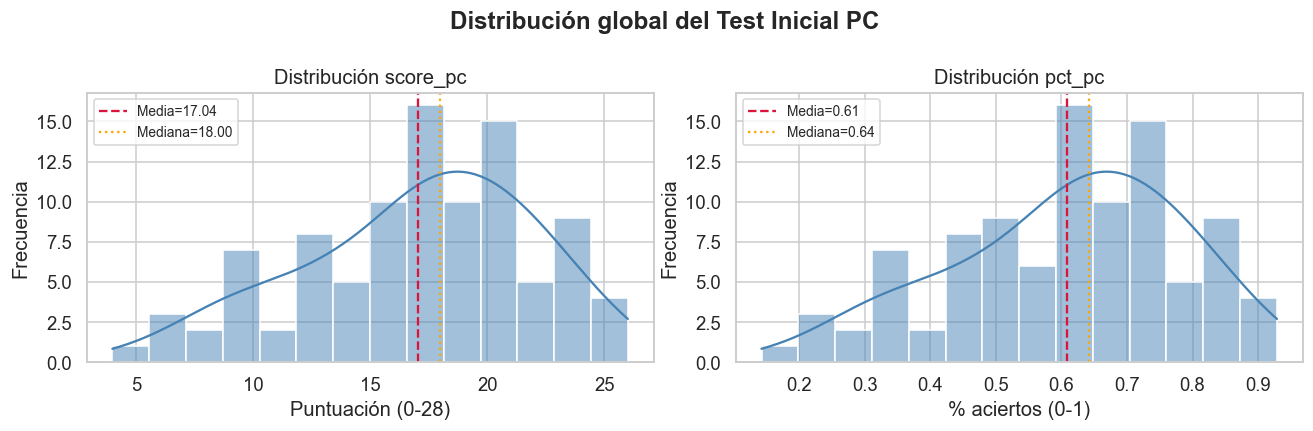

Figura guardada: pc_histograma_global.png


In [ ]:

# ─────────────────────────────────────────────────────────────────
# 3.1  Histograma + KDE de score_pc y pct_pc (global)
# ─────────────────────────────────────────────────────────────────
logger.info("--- SECTION 3: CT Descriptives ---")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, xlabel in zip(axes,
                            ["score_pc", "pct_pc"],
                            ["Score (0-28)", "% correct (0-1)"]):
    sns.histplot(df_pc[col].dropna(), kde=True, ax=ax, bins=14, color="steelblue")
    ax.axvline(df_pc[col].mean(), color="crimson", ls="--", lw=1.5, label=f"Media={df_pc[col].mean():.2f}")
    ax.axvline(df_pc[col].median(), color="orange", ls=":", lw=1.5, label=f"Mediana={df_pc[col].median():.2f}")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=9)
    ax.set_title(f"Distribution {col}")

fig.suptitle("Global Distribution of Initial CT Test", fontweight="bold")
fig.tight_layout()
fig.savefig(FIGS / "pc_histograma_global.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figure saved: pc_histograma_global.png")

# ─────────────────────────────────────────────────────────────────
# 3.2  Boxplot/Violin por Clase, Género y NEE
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
grouping_vars = [
    ("Clase", "Class (A/B/C/D)"),
    ("Género", "Género"),
    ("NEE", "Special Educational Needs (SEN)"),
]
palette = {"A": "#4E79A7", "B": "#F28E2B", "C": "#E15759", "D": "#76B7B2",
           "Boy": "#59A14F", "Girl": "#B07AA1",
           "Yes": "#FF9DA7", "No": "#9C755F"}

for ax, (gvar, glabel) in zip(axes, grouping_vars):
    order = sorted(df_pc[gvar].dropna().unique())
    data_sub = df_pc.dropna(subset=[gvar, "score_pc"])
    color_list = [palette.get(g, "steelblue") for g in order]
    vp = ax.violinplot(
        [data_sub.loc[data_sub[gvar] == g, "score_pc"].values for g in order],
        positions=range(len(order)),
        showmedians=True,
    )
    for body, color in zip(vp["bodies"], color_list):
        body.set_facecolor(color)
        body.set_alpha(0.7)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order)
    ax.set_xlabel(glabel)
    ax.set_ylabel("CT Score (0-28)")
    ax.set_title(f"CT Score by {gvar}")

fig.suptitle("Initial CT Score by groups", fontweight="bold")
fig.tight_layout()
fig.savefig(FIGS / "pc_violin_por_grupo.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figure saved: pc_violin_por_grupo.png")

# ─────────────────────────────────────────────────────────────────
# 3.3  Tabla resumen global y por grupos
# ─────────────────────────────────────────────────────────────────
def resumen_grupo(df, grupo_col=None, val_col="score_pc", n_boot=2000):
    """Calculates statistics + 95% bootstrap CI."""
    rows = []
    if grupo_col is None:
        subsets = [("Global", df)]
    else:
        subsets = [(g, df.loc[df[grupo_col] == g]) for g in sorted(df[grupo_col].dropna().unique())]
    for name, sub in subsets:
        x = sub[val_col].dropna().values
        if len(x) == 0:
            continue
        ci_lo, ci_hi = bootstrap_ci(x, np.mean, n_boot=n_boot)
        q1, q3 = np.percentile(x, 25), np.percentile(x, 75)
        rows.append({
            "Group" if grupo_col else "Global": name,
            "N": len(x),
            "Media": np.mean(x),
            "Mediana": np.median(x),
            "SD": np.std(x, ddof=1),
            "IQR": q3 - q1,
            "Min": np.min(x),
            "Max": np.max(x),
            "IC95_lo": ci_lo,
            "IC95_hi": ci_hi,
        })
    return pd.DataFrame(rows)


df_res_global = resumen_grupo(df_pc, grupo_col=None)
df_res_clase  = resumen_grupo(df_pc, grupo_col="Clase")
df_res_genero = resumen_grupo(df_pc, grupo_col="Género")
df_res_nee    = resumen_grupo(df_pc, grupo_col="NEE")

df_desc_global = pd.concat([df_res_global], ignore_index=True)
df_desc_grupos = pd.concat([
    df_res_clase.assign(Variable="Clase"),
    df_res_genero.assign(Variable="Género"),
    df_res_nee.assign(Variable="NEE"),
], ignore_index=True)

df_desc_global.to_csv(TABS / "pc_descriptivo_global.csv", index=False, encoding="utf-8-sig")
df_desc_grupos.to_csv(TABS / "pc_descriptivo_por_grupo.csv", index=False, encoding="utf-8-sig")

print("Global descriptives:")
display(style_table(df_desc_global, caption="Global Descriptive Statistics — Initial CT"))
print("\nDescriptives by group:")
display(style_table(df_desc_grupos, caption="CT Descriptives by Group (Class / Gender / SEN)"))

# ─────────────────────────────────────────────────────────────────
# 3.4  Tabla por ítem: %acierto global + por Clase
# ─────────────────────────────────────────────────────────────────
item_rows = []
for i, col in enumerate(pregunta_cols, start=1):
    vals_num = pd.to_numeric(df_pc[col], errors="coerce")
    row = {"Pregunta": i, "Global_%acierto": vals_num.mean()}
    for clase in sorted(df_pc["Clase"].dropna().unique()):
        mask = df_pc["Clase"] == clase
        row[f"Clase_{clase}_%acierto"] = vals_num[mask].mean()
    item_rows.append(row)
df_items = pd.DataFrame(item_rows)
df_items.to_csv(TABS / "pc_por_item_y_clase.csv", index=False, encoding="utf-8-sig")
print(f"\nItem table saved → {TABS / 'pc_por_item_y_clase.csv'}")
display(style_table(df_items, caption="% Correct by item and class", highlight_min_col="pct_acierto" if "pct_acierto" in df_items.columns else None))

# ─────────────────────────────────────────────────────────────────
# 3.5  Heatmap %acierto (Preguntas × Clases + Global)
# ─────────────────────────────────────────────────────────────────
heatmap_cols = [c for c in df_items.columns if c.startswith("Clase_")]
df_heat = df_items.set_index("Pregunta")[heatmap_cols].copy()
df_heat.columns = [c.replace("Clase_", "").replace("_%acierto", "") for c in df_heat.columns]
# Añadir columna Global al final
df_heat["Global"] = df_items.set_index("Pregunta")["Global_%acierto"]

n_clases = len(heatmap_cols)

fig, ax = plt.subplots(figsize=(9, 10))
sns.heatmap(
    df_heat, annot=True, fmt=".0%", cmap="RdYlGn",
    vmin=0, vmax=1, linewidths=0.4, ax=ax,
    cbar_kws={"label": "% correct"},
)
# Línea separadora entre clases y columna Global
ax.axvline(n_clases, color="black", lw=2)
ax.set_title("Heatmap % correct by Question × Class (+ Global)", fontweight="bold")
ax.set_xlabel("Clase")
ax.set_ylabel("Pregunta")
fig.tight_layout()
fig.savefig(FIGS / "pc_heatmap_items_clase.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figure saved: pc_heatmap_items_clase.png")

# ─────────────────────────────────────────────────────────────────
# 3.6a  Tabla % acierto por Tarea_requerida
#        (Secuenciación / Completamiento / Depuración)
# ─────────────────────────────────────────────────────────────────
def _make_dim_table(df, cols, group_col_name):
    """Builds descriptive table for a list of pct_* columns."""
    rows = []
    for col in cols:
        # Recuperar etiqueta original desde el spec
        label = col.replace("pct_", "").replace("_", " ").strip()
        vals = df[col].dropna()
        rows.append({
            group_col_name: label,
            "N": len(vals),
            "Media": round(vals.mean(), 3),
            "SD": round(vals.std(ddof=1), 3),
            "Min": round(vals.min(), 3),
            "Max": round(vals.max(), 3),
        })
    return pd.DataFrame(rows)

df_tarea = _make_dim_table(df_pc, tarea_pct_cols, "Required_Task")
df_tarea.to_csv(TABS / "pc_por_tarea_requerida.csv", index=False, encoding="utf-8-sig")
print(f"\nTable by Required Task → {TABS / 'pc_por_tarea_requerida.csv'}")
display(style_table(df_tarea, caption="CT Score by Required Task"))

# ─────────────────────────────────────────────────────────────────
# 3.6b  Tabla % acierto por Concepto Computacional
#        (Direcciones / Bucles / Condicionales / Funciones)
# ─────────────────────────────────────────────────────────────────
df_concepto = _make_dim_table(df_pc, concepto_pct_cols, "Concept")
df_concepto.to_csv(TABS / "pc_por_concepto_computacional.csv", index=False, encoding="utf-8-sig")
print(f"\nTable by Computational Concept → {TABS / 'pc_por_concepto_computacional.csv'}")
display(style_table(df_concepto, caption="CT Score by Computational Concept"))

# archivo combinado para compatibilidad con quality gates
df_dim = pd.concat([
    df_tarea.rename(columns={"Required_Task": "Dimensión"}),
    df_concepto.rename(columns={"Concept": "Dimensión"}),
], ignore_index=True)
df_dim.to_csv(TABS / "pc_por_dimension.csv", index=False, encoding="utf-8-sig")

# ─────────────────────────────────────────────────────────────────
# 3.7a  Barplot % acierto por Tarea_requerida
# ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
df_t_sorted = df_tarea.sort_values("Media", ascending=False)
sns.barplot(data=df_t_sorted, x="Required_Task", y="Media", palette="Blues_d", ax=ax)
ax.set_ylim(0, 1)
ax.set_ylabel("Mean % correct")
ax.set_xlabel("")
ax.set_title("% Correct by Required Task (Initial CT Test)", fontweight="bold")
plt.xticks(rotation=20, ha="right")
fig.tight_layout()
fig.savefig(FIGS / "pc_acierto_por_tarea_requerida.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figure saved: pc_acierto_por_tarea_requerida.png")

# ─────────────────────────────────────────────────────────────────
# 3.7b  Barplot % acierto por Concepto Computacional
# ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
df_c_sorted = df_concepto.sort_values("Media", ascending=False)
sns.barplot(data=df_c_sorted, x="Concept", y="Media", palette="Oranges_d", ax=ax)
ax.set_ylim(0, 1)
ax.set_ylabel("Mean % correct")
ax.set_xlabel("")
ax.set_title("% Correct by Computational Concept (Initial CT Test)\n"
             "Directions · Loops · Conditionals · Functions",
             fontweight="bold")
plt.xticks(rotation=15, ha="right")
fig.tight_layout()
fig.savefig(FIGS / "pc_acierto_por_concepto.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figure saved: pc_acierto_por_concepto.png")

import shutil as _shutil
_shutil.copy(FIGS / "pc_acierto_por_tarea_requerida.png", FIGS / "pc_acierto_por_dimension.png")

# ─────────────────────────────────────────────────────────────────
# 3.8  Histograma score en escala 0-10 (nota de examen)
# ─────────────────────────────────────────────────────────────────
# nota_10 = pct_pc * 10  (equivalente a score_pc / max_score * 10)
df_pc["nota_10"] = df_pc["pct_pc"] * 10

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df_pc["nota_10"].dropna(), kde=True, bins=14, color="steelblue", ax=ax)
ax.axvline(df_pc["nota_10"].mean(), color="crimson", ls="--", lw=1.5,
           label=f"Media = {df_pc['nota_10'].mean():.2f}")
ax.axvline(df_pc["nota_10"].median(), color="orange", ls=":", lw=1.5,
           label=f"Mediana = {df_pc['nota_10'].median():.2f}")
ax.axvspan(0, 5, alpha=0.06, color="red", zorder=0)
ax.axvspan(5, 10, alpha=0.06, color="green", zorder=0)
ax.axvline(5, color="grey", ls="-", lw=1, alpha=0.5, label="Pass (5)")
ax.set_xlim(0, 10)
ax.set_xlabel("Grade (scale 0-10)")
ax.set_ylabel("Frequency")
ax.legend(fontsize=9)
ax.set_title("Distribution of Initial CT Test — Scale 0-10", fontweight="bold")
fig.tight_layout()
fig.savefig(FIGS / "pc_histograma_nota10.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figure saved: pc_histograma_nota10.png")

# ─────────────────────────────────────────────────────────────────
# 3.9  Violin plot por Clase, Género y NEE — escala 0-10
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, (gvar, glabel) in zip(axes, grouping_vars):
    order = sorted(df_pc[gvar].dropna().unique())
    data_sub = df_pc.dropna(subset=[gvar, "nota_10"])
    color_list = [palette.get(g, "steelblue") for g in order]
    vp = ax.violinplot(
        [data_sub.loc[data_sub[gvar] == g, "nota_10"].values for g in order],
        positions=range(len(order)),
        showmedians=True,
    )
    for body, color in zip(vp["bodies"], color_list):
        body.set_facecolor(color)
        body.set_alpha(0.7)
    ax.axhline(5, color="red", ls="--", lw=1, alpha=0.6, label="Pass (5)")
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order)
    ax.set_ylim(0, 10)
    ax.set_xlabel(glabel)
    ax.set_ylabel("Grade (0-10)")
    ax.set_title(f"CT Grade (0-10) by {gvar}")
    ax.legend(fontsize=8)

fig.suptitle("Initial CT Score (scale 0-10) by groups", fontweight="bold")
fig.tight_layout()
fig.savefig(FIGS / "pc_violin_nota10_por_grupo.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figure saved: pc_violin_nota10_por_grupo.png")


## 4. Significant CT Differences: Gender and SEN

**What this section does:** Contrasts the CT score between Boys and Girls, and between students with and without SEN. The statistical test selection (Welch's t or Mann-Whitney U) is performed automatically based on normality (Shapiro-Wilk) and homoscedasticity (Levene). Calculates effect sizes (Hedges g or rank-biserial) with 95% bootstrap CI and permutation test for robustness. Documents the methodological decision in an exportable table.

**Why:** Verifying whether differences by gender or SEN exist is an educational equity question. Automatic test selection guarantees that the statistically appropriate method is applied in each case, which is especially critical when the SEN group has very few students (N < 10), a situation in which the p-value is highly unstable and an explicit warning is issued.


2026-06-22 12:42:13,921 [INFO] --- SECCIÓN 4: Contrastes género y NEE ---
2026-06-22 12:42:16,628 [INFO] Contraste Género (Chico vs Chica): test=mann_whitney p=0.0694 p_perm=0.0556 efecto=-0.215
=== Contraste Género ===
  variable: score_pc
  grupo: Género
  N_Chico: 52
  media_Chico: 17.9423
  N_Chica: 45
  media_Chica: 16.0000
  shapiro_p_Chico: 0.1801
  shapiro_p_Chica: 0.0285
  test_elegido: mann_whitney
  estadístico: 1421.0000
  p_valor: 0.0694
  efecto: -0.2145
  IC95_efecto_lo: -0.2210
  IC95_efecto_hi: 0.2184
  tipo_efecto: rank_biserial
  p_perm: 0.0556
  levene_p: 0.8222


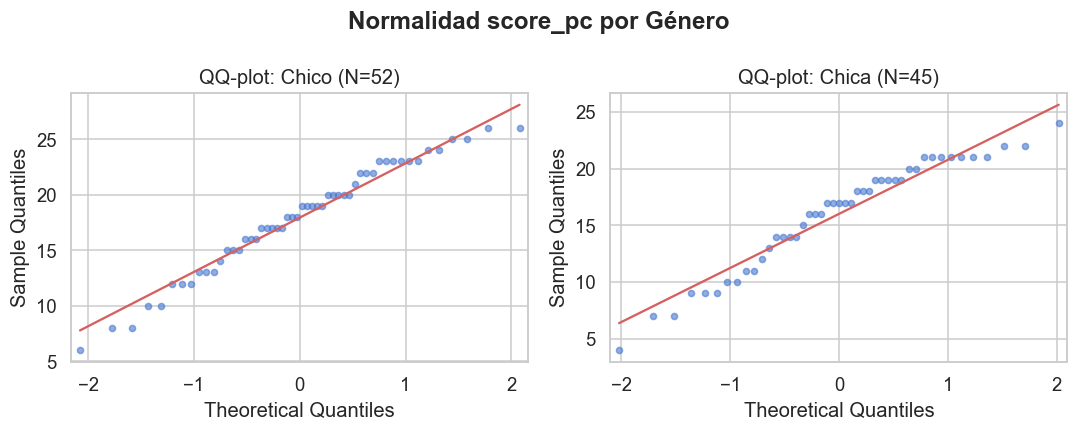


=== Contraste NEE ===
  N(NEE=Sí)=8  N(NEE=No)=89
2026-06-22 12:42:17,208 [WARNING] [NEE] Desequilibrio muestral severo: N(Sí)=8. Se prioriza descriptivo + bootstrapping. Conclusiones de p-valor con CAUTELA EXTREMA.

[!] **ADVERTENCIA:** El grupo NEE=Sí tiene solo 8 alumnos. Los p-valores son extremadamente poco fiables en muestras tan pequeñas. Se reportan descriptivos, tamaño de efecto con IC bootstrap y prueba de permutación. NO deben extraerse conclusiones fuertes sobre significación estadística.
2026-06-22 12:42:19,508 [INFO] Contraste NEE (Sí vs No): test=mann_whitney p=0.6221 p_perm=0.6410 efecto=-0.107

Resultados NEE:
  variable: score_pc
  grupo: NEE
  N_Sí: 8
  media_Sí: 17.8750
  N_No: 89
  media_No: 16.9663
  shapiro_p_Sí: 0.7445
  shapiro_p_No: 0.0427
  test_elegido: mann_whitney
  estadístico: 394.0000
  p_valor: 0.6221
  efecto: -0.1067
  IC95_efecto_lo: -0.4087
  IC95_efecto_hi: 0.4143
  tipo_efecto: rank_biserial
  p_perm: 0.6410
  levene_p: 0.9510
  metodo_elegido: 

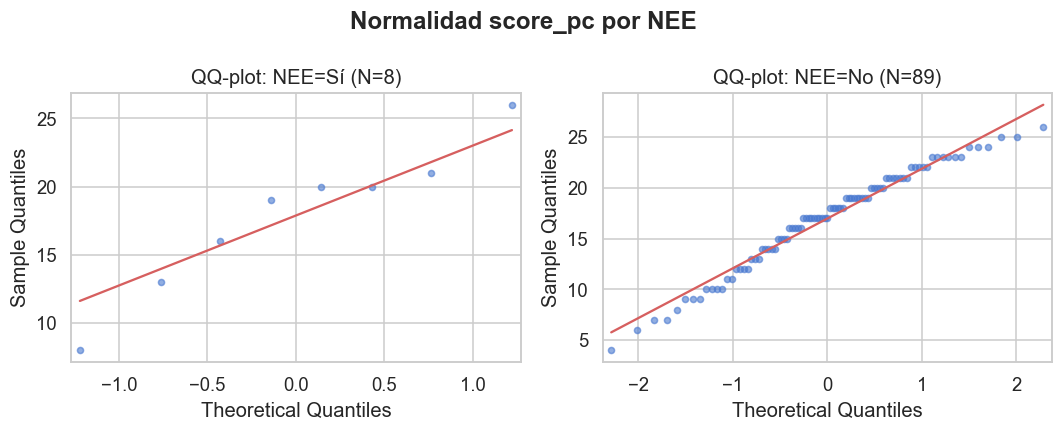


Tabla decisión metodológica → outputs\tables\pc_decision_metodologica.csv


Contraste,N_grupo1,N_grupo2,Test_elegido,p_valor,p_perm,Efecto,Tipo_efecto,Decisión
Género (Chico vs Chica),52,45,mann_whitney,0.069,0.056,-0.215,rank_biserial,Selección automática (Shapiro + Levene)
NEE (Sí vs No),8,89,mann_whitney,0.622,0.641,-0.107,rank_biserial,MWU + permutación + IC bootstrap (N<10 en NEE=Sí)


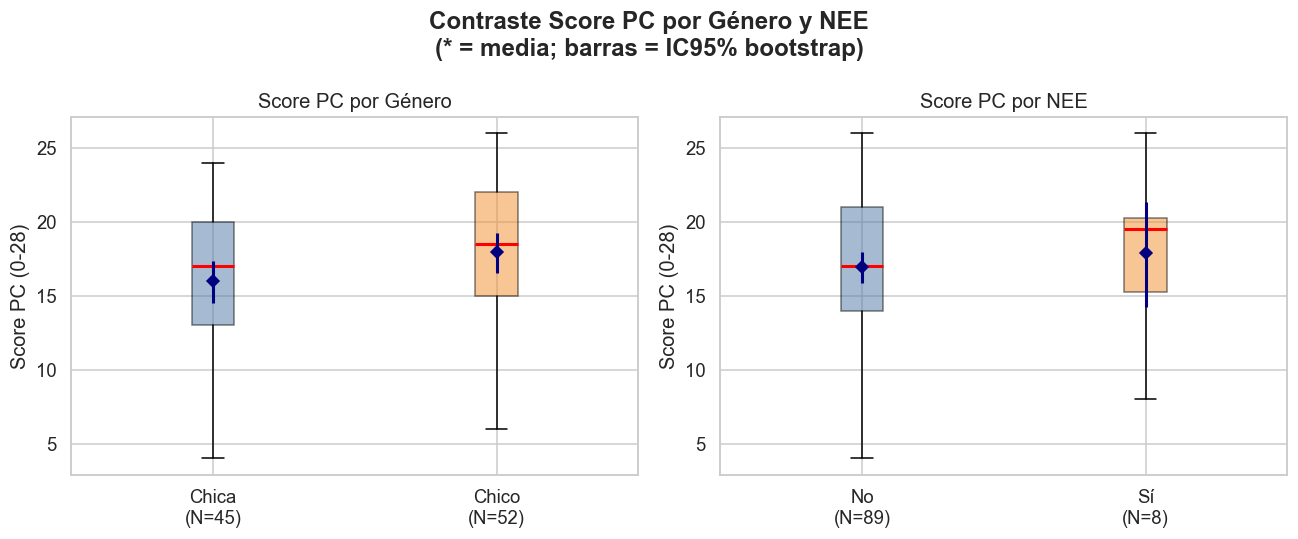

Figura guardada: pc_contraste_grupos.png


In [7]:
# ─────────────────────────────────────────────────────────────────
# 4.1  Función genérica de contraste con decisión metodológica
# ─────────────────────────────────────────────────────────────────
logger.info("--- SECTION 4: Gender and SEN Contrasts ---")

def contraste_dos_grupos(df, grupo_col, val_col="score_pc",
                          group_labels=None, n_perm=5000, n_boot=2000):
    """
    Contraste automático entre dos grupos:
    - Normalidad por Shapiro
    - Levene para varianzas
    - Welch-t si normal; Mann-Whitney si no
    - Hedges g (si t) o rank-biserial (si MWU)
    - Prueba de permutación
    Returns a dict with all results.
    """
    grupos = df[grupo_col].dropna().unique()
    if group_labels is None:
        group_labels = sorted(grupos)

    # Extraer grupos
    data_groups = {}
    for g in group_labels:
        vals = df.loc[df[grupo_col] == g, val_col].dropna().values
        data_groups[g] = vals

    result = {"variable": val_col, "grupo": grupo_col}
    for g, vals in data_groups.items():
        result[f"N_{g}"] = len(vals)
        result[f"media_{g}"] = np.mean(vals) if len(vals) > 0 else np.nan

    if len(data_groups) != 2:
        result["nota"] = "Requires exactly 2 groups"
        return result

    a, b = [data_groups[g] for g in group_labels]
    g1, g2 = group_labels

    # Shapiro
    sw_p_a = stats.shapiro(a).pvalue if len(a) >= 3 else np.nan
    sw_p_b = stats.shapiro(b).pvalue if len(b) >= 3 else np.nan
    result["shapiro_p_" + str(g1)] = sw_p_a
    result["shapiro_p_" + str(g2)] = sw_p_b

    # Decisión de test
    test_chosen = choose_test(a, b)
    result["test_elegido"] = test_chosen

    if test_chosen == "welch_t":
        stat, p = stats.ttest_ind(a, b, equal_var=False)
        eff, eff_ci = hedges_g(a, b)
        result.update({
            "statistic": stat,
            "p_value": p,
            "effect": eff,
            "IC95_efecto_lo": eff_ci[0],
            "IC95_efecto_hi": eff_ci[1],
            "effect_type": "Hedges_g",
        })
    else:
        stat, p = stats.mannwhitneyu(a, b, alternative="two-sided")
        eff = rank_biserial(a, b)
        ci_lo, ci_hi = bootstrap_ci(
            np.concatenate([a, b]),
            lambda x: rank_biserial(x[:len(a)], x[len(a):]),
            n_boot=n_boot,
        )
        result.update({
            "statistic": stat,
            "p_value": p,
            "effect": eff,
            "IC95_efecto_lo": ci_lo,
            "IC95_efecto_hi": ci_hi,
            "effect_type": "rank_biserial",
        })

    # Prueba de permutación
    p_perm = permutation_test(a, b, n_perm=n_perm)
    result["p_perm"] = p_perm

    # Levene
    lev_stat, lev_p = stats.levene(a, b)
    result["levene_p"] = lev_p

    logger.info(
        f"Contraste {grupo_col} ({g1} vs {g2}): test={test_chosen} "
        f"p={p:.4f} p_perm={p_perm:.4f} efecto={eff:.3f}"
    )
    return result


# ─────────────────────────────────────────────────────────────────
# 4.1  Contraste Género
# ─────────────────────────────────────────────────────────────────
res_genero = contraste_dos_grupos(df_pc, "Género", val_col="score_pc",
                                   group_labels=["Boy", "Girl"])
df_contraste_genero = pd.DataFrame([res_genero])
df_contraste_genero.to_csv(TABS / "pc_contraste_genero.csv", index=False, encoding="utf-8-sig")

print("=== Gender Contrast ===")
for k, v in res_genero.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

# QQ-plot Género
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, gen in zip(axes, ["Boy", "Girl"]):
    vals = df_pc.loc[df_pc["Género"] == gen, "score_pc"].dropna()
    sm.qqplot(vals, line="s", ax=ax, alpha=0.6, markersize=4)
    ax.set_title(f"QQ-plot: {gen} (N={len(vals)})")
fig.suptitle("Normality of score_pc by Gender", fontweight="bold")
fig.tight_layout()
fig.savefig(FIGS / "pc_qqplot_genero.png", dpi=120, bbox_inches="tight")
plt.show()

# ─────────────────────────────────────────────────────────────────
# 4.2  Contraste NEE (con advertencia si N<10)
# ─────────────────────────────────────────────────────────────────
n_nee_si = (df_pc["NEE"] == "Yes").sum()
n_nee_no = (df_pc["NEE"] == "No").sum()
print(f"\n=== Contraste NEE ===")
print(f"  N(SEN=Yes)={n_nee_si}  N(SEN=No)={n_nee_no}")

decision_nee = {}
if n_nee_si < 10:
    logger.warning(
        f"[SEN] Severe sample imbalance: N(Yes)={n_nee_si}. "
        "Prioritising descriptive + bootstrapping. p-value conclusions with EXTREME CAUTION."
    )
    advertencia_nee = (
        f"[!] **WARNING:** The SEN=Yes group has only {n_nee_si} students. "
        "p-values are extremely unreliable in such small samples. "
        "Reporting descriptives, effect size with bootstrap CI and permutation test. "
        "Strong conclusions about statistical significance should NOT be drawn."
    )
    print("\n" + advertencia_nee)
    decision_nee["warning"] = advertencia_nee
    decision_nee["method"] = "MWU + permutation + bootstrap CI (N<10 in SEN=Yes)"
else:
    advertencia_nee = None
    decision_nee["method"] = "Automatic selection Shapiro + Levene"

res_nee = contraste_dos_grupos(df_pc, "NEE", val_col="score_pc",
                                group_labels=["Yes", "No"])
res_nee["metodo_elegido"] = decision_nee["method"]
if advertencia_nee:
    res_nee["warning"] = advertencia_nee

df_contraste_nee = pd.DataFrame([res_nee])
df_contraste_nee.to_csv(TABS / "pc_contraste_nee.csv", index=False, encoding="utf-8-sig")

print("\nResultados NEE:")
for k, v in res_nee.items():
    if k != "warning":
        print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

# QQ-plot NEE
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, nee_val in zip(axes, ["Yes", "No"]):
    vals = df_pc.loc[df_pc["NEE"] == nee_val, "score_pc"].dropna()
    if len(vals) >= 3:
        sm.qqplot(vals, line="s", ax=ax, alpha=0.6, markersize=4)
    ax.set_title(f"QQ-plot: NEE={nee_val} (N={len(vals)})")
fig.suptitle("Normality of score_pc by SEN", fontweight="bold")
fig.tight_layout()
fig.savefig(FIGS / "pc_qqplot_nee.png", dpi=120, bbox_inches="tight")
plt.show()

# ─────────────────────────────────────────────────────────────────
# 4.3  Tabla de decisión metodológica
# ─────────────────────────────────────────────────────────────────
df_decision = pd.DataFrame([
    {
        "Contrast": "Gender (Boy vs Girl)",
        "N_group1": res_genero.get("N_Chico", np.nan),
        "N_group2": res_genero.get("N_Chica", np.nan),
        "Chosen_Test": res_genero.get("test_elegido", ""),
        "p_value": res_genero.get("p_valor", np.nan),
        "p_perm": res_genero.get("p_perm", np.nan),
        "Efecto": res_genero.get("efecto", np.nan),
        "Effect_Type": res_genero.get("tipo_efecto", ""),
        "Decision": "Selección automática (Shapiro + Levene)",
    },
    {
        "Contrast": "SEN (Yes vs No)",
        "N_group1": n_nee_si,
        "N_group2": n_nee_no,
        "Chosen_Test": res_nee.get("test_elegido", ""),
        "p_value": res_nee.get("p_valor", np.nan),
        "p_perm": res_nee.get("p_perm", np.nan),
        "Efecto": res_nee.get("efecto", np.nan),
        "Effect_Type": res_nee.get("tipo_efecto", ""),
        "Decision": decision_nee["method"],
    },
])
df_decision.to_csv(TABS / "pc_decision_metodologica.csv", index=False, encoding="utf-8-sig")
print(f"\nTabla decisión metodológica → {TABS / 'pc_decision_metodologica.csv'}")
display(style_table(df_decision, caption="Methodological Decision: Gender and SEN", pval_cols=["p_valor", "p_perm"]))

# ─────────────────────────────────────────────────────────────────
# 4.4  Boxplot comparativo con IC bootstrap
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (gcol, glabel) in zip(axes, [("Género", "Género"), ("NEE", "NEE")]):
    order = sorted(df_pc[gcol].dropna().unique())
    means, ci_los, ci_his, labels = [], [], [], []
    for g in order:
        x = df_pc.loc[df_pc[gcol] == g, "score_pc"].dropna().values
        if len(x) == 0:
            continue
        labels.append(f"{g}\n(N={len(x)})")
        means.append(np.mean(x))
        lo, hi = bootstrap_ci(x, np.mean, n_boot=2000)
        ci_los.append(lo)
        ci_his.append(hi)
    # Boxplot base
    data_list = [df_pc.loc[df_pc[gcol] == g, "score_pc"].dropna().values for g in order]
    bp = ax.boxplot(data_list, labels=labels, patch_artist=True,
                    medianprops=dict(color="red", lw=2))
    colors = ["#4E79A7", "#F28E2B", "#E15759"]
    for patch, col in zip(bp["boxes"], colors):
        patch.set_facecolor(col)
        patch.set_alpha(0.5)
    # Añadir medias + IC
    for xi, (m, lo, hi) in enumerate(zip(means, ci_los, ci_his), start=1):
        ax.plot(xi, m, "D", color="navy", ms=6, zorder=5)
        ax.vlines(xi, lo, hi, color="navy", lw=2, zorder=5)
    ax.set_title(f"CT Score by {glabel}")
    ax.set_ylabel("CT Score (0-28)")

fig.suptitle("CT Score Contrast by Gender and SEN\n(* = mean; bars = 95% bootstrap CI)", fontweight="bold")
fig.tight_layout()
fig.savefig(FIGS / "pc_contraste_grupos.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figure saved: pc_contraste_grupos.png")

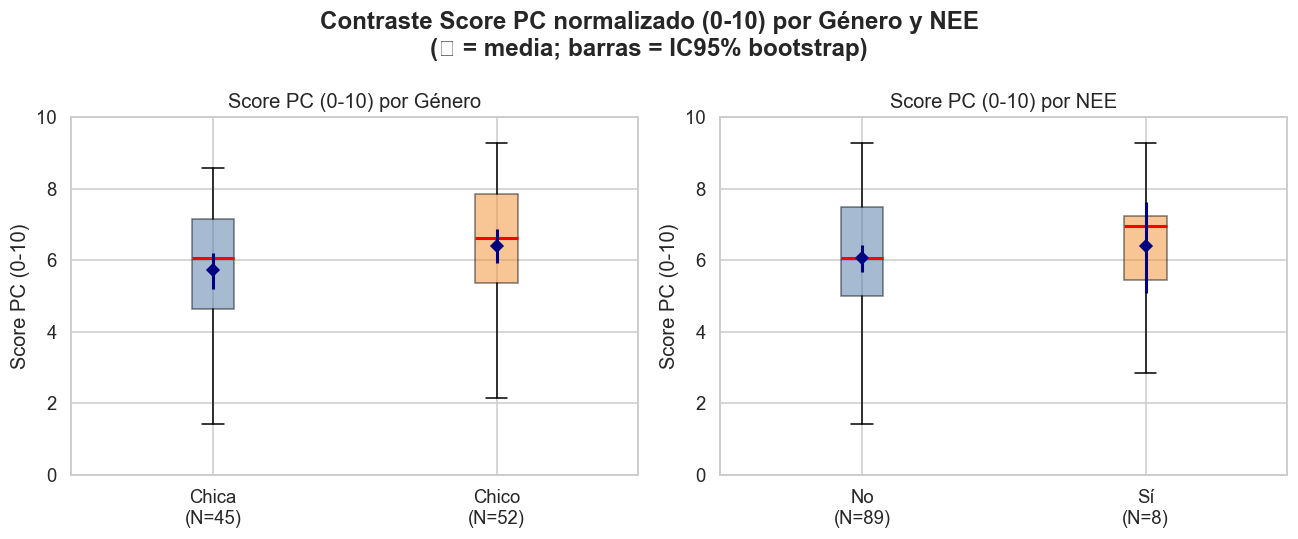

Figura guardada: pc_contraste_grupos_norm10.png


In [8]:

# ─────────────────────────────────────────────────────────────────
# 4.5  Boxplot comparativo con score normalizado 0-10
# ─────────────────────────────────────────────────────────────────
MAX_SCORE_PC = 28  # número total de ítems del test

# Añadir columna normalizada si no existe
if "score_pc_10" not in df_pc.columns:
    df_pc["score_pc_10"] = df_pc["score_pc"] / MAX_SCORE_PC * 10

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (gcol, glabel) in zip(axes, [("Género", "Género"), ("NEE", "NEE")]):
    order = sorted(df_pc[gcol].dropna().unique())
    means, ci_los, ci_his, labels = [], [], [], []
    for g in order:
        x = df_pc.loc[df_pc[gcol] == g, "score_pc_10"].dropna().values
        if len(x) == 0:
            continue
        labels.append(f"{g}\n(N={len(x)})")
        means.append(np.mean(x))
        lo, hi = bootstrap_ci(x, np.mean, n_boot=2000)
        ci_los.append(lo)
        ci_his.append(hi)
    # Boxplot base
    data_list = [df_pc.loc[df_pc[gcol] == g, "score_pc_10"].dropna().values for g in order]
    bp = ax.boxplot(data_list, labels=labels, patch_artist=True,
                    medianprops=dict(color="red", lw=2))
    colors = ["#4E79A7", "#F28E2B", "#E15759"]
    for patch, col in zip(bp["boxes"], colors):
        patch.set_facecolor(col)
        patch.set_alpha(0.5)
    # Añadir medias + IC bootstrap
    for xi, (m, lo, hi) in enumerate(zip(means, ci_los, ci_his), start=1):
        ax.plot(xi, m, "D", color="navy", ms=6, zorder=5)
        ax.vlines(xi, lo, hi, color="navy", lw=2, zorder=5)
    ax.set_title(f"CT Score (0-10) by {glabel}")
    ax.set_ylabel("CT Score (0-10)")
    ax.set_ylim(0, 10)

fig.suptitle(
    "Normalised CT Score Contrast (0-10) by Gender and SEN\n"
    "(◆ = mean; bars = 95% bootstrap CI)",
    fontweight="bold",
)
fig.tight_layout()
fig.savefig(FIGS / "pc_contraste_grupos_norm10.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figure saved: pc_contraste_grupos_norm10.png")


## 5. Self-Perception vs Actual Performance (CT)

**What this section does:** Contrasts students' self-perception about their CT performance with their actual performance. As the self-perception dataset has no individual ID column, the comparison is performed at **aggregate group level** (by gender, SEN or CT level): the group's mean self-perception is calculated and compared against its mean real CT score, identifying whether the group overestimates, underestimates or is well-calibrated.

**Why:** Metacognitive calibration (knowing one's own level well) is a key factor in learning. Students who overestimate themselves may not make sufficient effort; students who underestimate themselves may exhibit low self-efficacy. This section identifies groups with systematic self-perception mismatches.

> **Explicit limitation:** Without individual ID, student-to-student correlations cannot be calculated. All analyses are performed at group mean level and reported as such.


2026-06-12 12:49:11,656 [INFO] --- SECCIÓN 5: Autopercepción ---
Autopercepción: (97, 4)


estadístico,autopercepcion,dificultad
count,97.000,97.000
mean,7.270,5.910
std,1.880,2.650
min,0.000,0.000
25%,6.000,4.000
50%,7.000,6.000
75%,8.000,8.000
max,10.000,10.000


2026-06-12 12:49:11,697 [WARNING] [AUTOPERCEPCIÓN] No hay columna ID común con PC. No se realizará emparejamiento individual. Análisis EXCLUSIVAMENTE agregado por grupo. LIMITACIÓN: no es posible relacionar autopercepción con rendimiento a nivel individuo.

[!]  Sin ID común → Análisis AGREGADO por grupo (no individual).
   LIMITACIÓN: La comparación autopercepción vs rendimiento real
   se realiza a nivel de media de grupo, NO a nivel de alumno.

Descriptivos autopercepción → outputs\tables\autopercepcion_descriptivo.csv


Agrupación,Grupo,Variable,N,Media,Mediana,SD,IC95_lo,IC95_hi
Global,Global,autopercepcion,97,7.268,7.000,1.879,6.876,7.619
Global,Global,dificultad,97,5.907,6.000,2.650,5.381,6.454
Género,Chica,autopercepcion,45,6.933,7.000,1.671,6.400,7.400
Género,Chica,dificultad,45,6.867,7.000,2.191,6.200,7.511
Género,Chico,autopercepcion,52,7.558,8.000,2.014,6.981,8.077
Género,Chico,dificultad,52,5.077,5.000,2.750,4.346,5.827
NEE,No,autopercepcion,89,7.202,7.000,1.896,6.787,7.584
NEE,No,dificultad,89,6.022,6.000,2.598,5.483,6.551
NEE,Sí,autopercepcion,8,8.000,8.000,1.604,7.000,9.000
NEE,Sí,dificultad,8,4.625,4.000,3.068,2.750,6.625



Comparación agregada por grupo (sin emparejamiento individual):


Variable_agrupacion,Grupo,media_pct_pc,media_autopercepcion_norm,diferencia_agregada,nota
Género,Chica,0.571,0.693,0.122,"Comparación a nivel de grupo, NO individual"
Género,Chico,0.641,0.756,0.115,"Comparación a nivel de grupo, NO individual"
NEE,No,0.606,0.720,0.114,"Comparación a nivel de grupo, NO individual"
NEE,Sí,0.638,0.800,0.162,"Comparación a nivel de grupo, NO individual"


2026-06-12 12:49:27,134 [INFO] Contraste Género (Chica vs Chico): test=mann_whitney p=0.0322 p_perm=0.1042 efecto=0.249
2026-06-12 12:49:34,447 [INFO] Contraste Género (Chica vs Chico): test=mann_whitney p=0.0015 p_perm=0.0004 efecto=-0.372
2026-06-12 12:49:41,790 [INFO] Contraste NEE (No vs Sí): test=mann_whitney p=0.3128 p_perm=0.2886 efecto=0.213
2026-06-12 12:49:47,197 [INFO] Contraste NEE (No vs Sí): test=mann_whitney p=0.1632 p_perm=0.1626 efecto=-0.298

Contrastes autopercepción → outputs\tables\autopercepcion_contrastes.csv


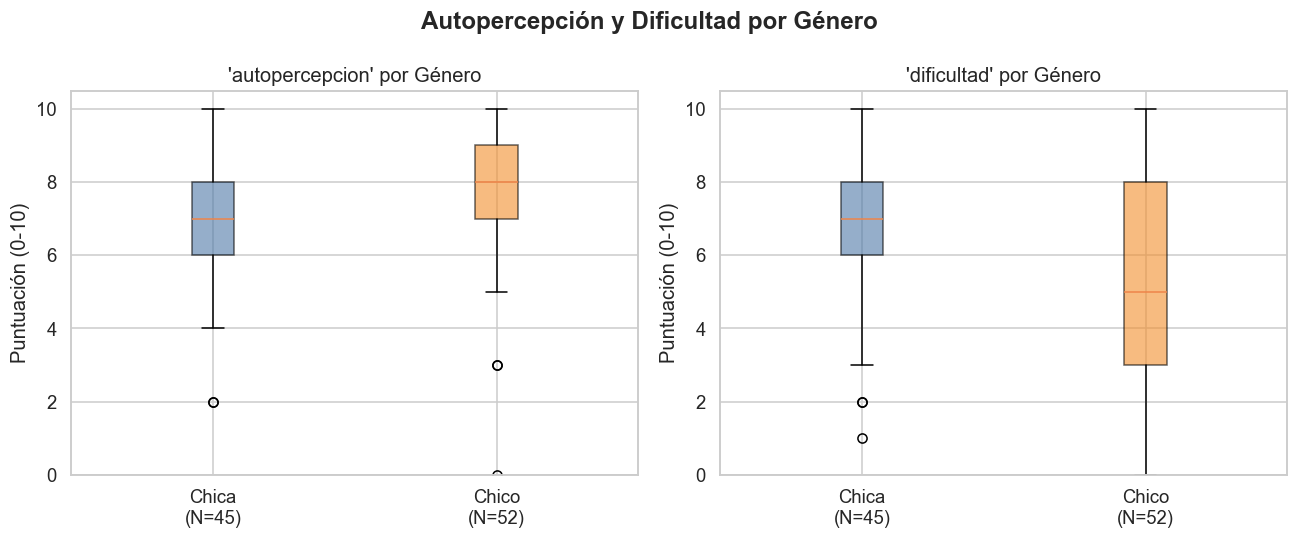

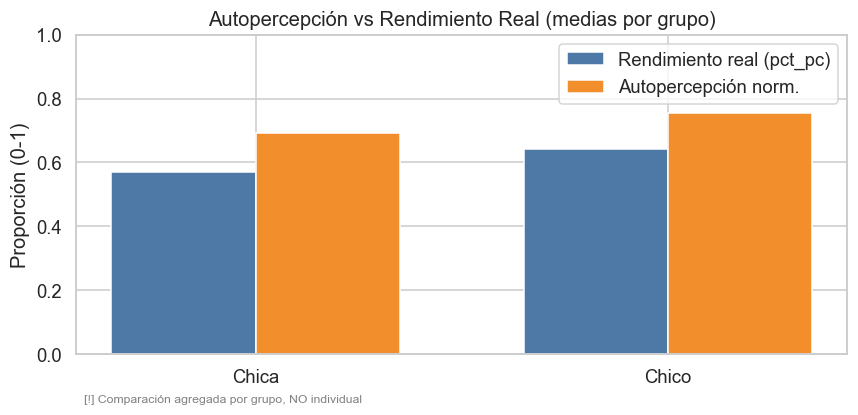

Figuras autopercepción guardadas OK


In [8]:
# ─────────────────────────────────────────────────────────────────
# 5.1  Preparar dataset de autopercepción
# ─────────────────────────────────────────────────────────────────
logger.info("--- SECTION 5: Self-Perception ---")

df_auto = df_auto_raw.copy()
df_auto.columns = [c.strip() for c in df_auto.columns]

# Detectar columnas clave
col_auto_score  = [c for c in df_auto.columns if "salido" in c.lower() or "consideras" in c.lower()]
col_auto_dif    = [c for c in df_auto.columns if "difícil" in c.lower() or "dificil" in c.lower()]
col_auto_genero = [c for c in df_auto.columns if "género" in c.lower() or "genero" in c.lower()]
col_auto_nee    = [c for c in df_auto.columns if "necesidad" in c.lower() or "nee" in c.lower()]

col_auto_score  = col_auto_score[0]  if col_auto_score  else None
col_auto_dif    = col_auto_dif[0]    if col_auto_dif    else None
col_auto_genero = col_auto_genero[0] if col_auto_genero else None
col_auto_nee    = col_auto_nee[0]    if col_auto_nee    else None

df_auto.rename(columns={
    col_auto_score:  "autopercepcion",
    col_auto_dif:    "dificultad",
    col_auto_genero: "Género",
    col_auto_nee:    "NEE",
}, inplace=True, errors="ignore")

# Limpiar y validar rangos 0-10
for col in ["autopercepcion", "dificultad"]:
    if col in df_auto.columns:
        df_auto[col] = ensure_numeric(df_auto[col], col)
        out_range = df_auto[col].notna() & ~df_auto[col].between(0, 10)
        if out_range.sum() > 0:
            log_anomaly(f"Autopercepción '{col}': {out_range.sum()} valores fuera de [0,10] → NaN")
            df_auto.loc[out_range, col] = np.nan

# Estandarizar Género y NEE en autopercepción
df_auto["Género"] = df_auto["Género"].str.strip().str.lower().map(genero_map).fillna(df_auto["Género"])
df_auto["NEE"]    = df_auto["NEE"].str.strip().str.lower().map(nee_map).fillna(df_auto["NEE"])

print(f"Autopercepción: {df_auto.shape}")
display(style_table(
    df_auto[["autopercepcion", "dificultad", "Género", "NEE"]].describe().round(2).reset_index().rename(columns={"index": "statistic"}),
    caption="Descriptive Statistics: self-perception",
))

# ─────────────────────────────────────────────────────────────────
# 5.2  Verificar si hay ID común con PC
# ─────────────────────────────────────────────────────────────────
id_cols_pc   = set(df_pc.columns)
id_cols_auto = set(df_auto.columns)
common_id = id_cols_pc & id_cols_auto - {"Género", "NEE"}

has_id = any(c.lower() in ["id", "alumno", "número", "numero"] for c in common_id)
if has_id:
    logger.info("[SELF-PERCEPTION] Common ID found → individual pairing")
    id_col_name = [c for c in common_id if c.lower() in ["id", "alumno", "número", "numero"]][0]
    df_merged = df_pc.merge(df_auto, on=id_col_name, how="inner",
                             suffixes=("_pc", "_auto"))
    logger.info(f"  Paired: {len(df_merged)} students")
    CAN_LINK = True
else:
    logger.warning(
        "[SELF-PERCEPTION] No common ID column with CT. "
        "Individual pairing will not be performed. "
        "EXCLUSIVELY aggregate analysis by group. "
        "LIMITATION: it is not possible to relate self-perception with performance at individual level."
    )
    print("\n[!]  Sin ID común → Análisis AGREGADO por grupo (no individual).")
    print("   LIMITATION: The self-perception vs actual performance comparison")
    print("   is performed at group mean level, NOT at student level.")
    CAN_LINK = False

# ─────────────────────────────────────────────────────────────────
# 5.3  Descriptivos de autopercepción
# ─────────────────────────────────────────────────────────────────
desc_auto_rows = []
for gcol in [None, "Género", "NEE"]:
    if gcol is None:
        subsets_a = [("Global", df_auto)]
    else:
        subsets_a = [(g, df_auto[df_auto[gcol] == g]) for g in sorted(df_auto[gcol].dropna().unique())]
    for label, sub in subsets_a:
        for vcol in ["autopercepcion", "dificultad"]:
            if vcol not in sub.columns:
                continue
            x = sub[vcol].dropna().values
            ci_lo, ci_hi = bootstrap_ci(x, np.mean, n_boot=2000)
            desc_auto_rows.append({
                "Grouping": gcol or "Global",
                "Group": label,
                "Variable": vcol,
                "N": len(x),
                "Media": np.mean(x) if len(x) else np.nan,
                "Mediana": np.median(x) if len(x) else np.nan,
                "SD": np.std(x, ddof=1) if len(x) > 1 else np.nan,
                "IC95_lo": ci_lo,
                "IC95_hi": ci_hi,
            })

df_desc_auto = pd.DataFrame(desc_auto_rows)
df_desc_auto.to_csv(TABS / "autopercepcion_descriptivo.csv", index=False, encoding="utf-8-sig")
print(f"\nDescriptivos autopercepción → {TABS / 'autopercepcion_descriptivo.csv'}")
display(style_table(df_desc_auto, caption="Self-Perception Descriptives by Group"))

# ─────────────────────────────────────────────────────────────────
# 5.4  Análisis agregado: media autopercepción vs media pct_pc por grupo
# ─────────────────────────────────────────────────────────────────
agg_rows = []
for gcol in ["Género", "NEE"]:
    grupos_pc  = df_pc.groupby(gcol)["pct_pc"].mean()
    grupos_auto = df_auto.groupby(gcol)["autopercepcion"].mean() / 10  # normalizar 0-1
    for g in grupos_pc.index:
        if g in grupos_auto.index:
            agg_rows.append({
                "Grouping_Variable": gcol,
                "Group": g,
                "media_pct_pc": grupos_pc[g],
                "media_autopercepcion_norm": grupos_auto[g],
                "aggregate_difference": grupos_auto[g] - grupos_pc[g],
                "note": "Comparison at group level, NOT individual",
            })

df_agg_auto = pd.DataFrame(agg_rows)
print("\nComparación agregada por grupo (sin emparejamiento individual):")
display(style_table(df_agg_auto, caption="Aggregate comparison self-perception vs actual performance"))

# ─────────────────────────────────────────────────────────────────
# 5.5  Contrastes de autopercepción/dificultad por Género y NEE
# ─────────────────────────────────────────────────────────────────
contrast_auto_rows = []
for gcol in ["Género", "NEE"]:
    for vcol in ["autopercepcion", "dificultad"]:
        if vcol not in df_auto.columns:
            continue
        groups = sorted(df_auto[gcol].dropna().unique())
        if len(groups) == 2:
            res = contraste_dos_grupos(df_auto, gcol, val_col=vcol, group_labels=groups)
            res["variable"] = vcol
            contrast_auto_rows.append(res)

df_contraste_auto = pd.DataFrame(contrast_auto_rows)
df_contraste_auto.to_csv(TABS / "autopercepcion_contrastes.csv", index=False, encoding="utf-8-sig")
print(f"\nSelf-perception contrasts → {TABS / 'autopercepcion_contrastes.csv'}")

# ─────────────────────────────────────────────────────────────────
# 5.6  Figuras autopercepción
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, vcol in zip(axes, ["autopercepcion", "dificultad"]):
    if vcol not in df_auto.columns:
        continue
    order = sorted(df_auto["Género"].dropna().unique())
    data_list = [df_auto.loc[df_auto["Género"] == g, vcol].dropna().values for g in order]
    bp = ax.boxplot(data_list, labels=[f"{g}\n(N={len(d)})" for g, d in zip(order, data_list)],
                    patch_artist=True)
    for patch, col in zip(bp["boxes"], ["#4E79A7", "#F28E2B"]):
        patch.set_facecolor(col)
        patch.set_alpha(0.6)
    ax.set_title(f"'{vcol}' por Género")
    ax.set_ylabel("Score (0-10)")
    ax.set_ylim(0, 10.5)

fig.suptitle("Self-Perception and Difficulty by Gender", fontweight="bold")
fig.tight_layout()
fig.savefig(FIGS / "autopercepcion_por_genero.png", dpi=120, bbox_inches="tight")
plt.show()

# Comparación agregada barplot
if not df_agg_auto.empty:
    fig2, ax2 = plt.subplots(figsize=(8, 4))
    df_agg_g = df_agg_auto[df_agg_auto["Grouping_Variable"] == "Género"].copy()
    x = np.arange(len(df_agg_g))
    w = 0.35
    ax2.bar(x - w/2, df_agg_g["media_pct_pc"], w, label="Actual performance (pct_pc)", color="#4E79A7")
    ax2.bar(x + w/2, df_agg_g["media_autopercepcion_norm"], w, label="Self-perception norm.", color="#F28E2B")
    ax2.set_xticks(x)
    ax2.set_xticklabels(df_agg_g["Group"])
    ax2.set_ylim(0, 1)
    ax2.set_ylabel("Proportion (0-1)")
    ax2.set_title("Self-Perception vs Actual Performance (group means)")
    ax2.legend()
    note = "[!] Aggregate comparison by group, NOT individual"
    ax2.text(0.01, -0.15, note, transform=ax2.transAxes, fontsize=8, color="gray")
    fig2.tight_layout()
    fig2.savefig(FIGS / "autopercepcion_vs_rendimiento_agregado.png", dpi=120, bbox_inches="tight")
    plt.show()

print("Self-perception figures saved OK")

# Análisis individual si hay ID
if CAN_LINK:
    df_merged["self_perception_norm"] = df_merged["autopercepcion"] / 10
    df_merged["calibration_error"] = df_merged["self_perception_norm"] - df_merged["pct_pc"]
    r_pearson, p_pearson = stats.pearsonr(
        df_merged["self_perception_norm"].dropna(),
        df_merged["pct_pc"].dropna()
    )
    r_spearman, p_spearman = stats.spearmanr(
        df_merged["self_perception_norm"].dropna(),
        df_merged["pct_pc"].dropna()
    )
    print(f"\nCorrelations (N={len(df_merged)}):")
    print(f"  Pearson r={r_pearson:.3f} (p={p_pearson:.4f})")
    print(f"  Spearman ρ={r_spearman:.3f} (p={p_spearman:.4f})")

    fig3, ax3 = plt.subplots(figsize=(6, 5))
    ax3.scatter(df_merged["pct_pc"], df_merged["self_perception_norm"], alpha=0.5)
    m, b = np.polyfit(df_merged["pct_pc"].dropna(), df_merged["self_perception_norm"].dropna(), 1)
    x_line = np.linspace(0, 1, 100)
    ax3.plot(x_line, m * x_line + b, "r-", lw=1.5, label=f"r={r_pearson:.2f}")
    ax3.set_xlabel("Actual performance (pct_pc)")
    ax3.set_ylabel("Normalised self-perception")
    ax3.set_title("Self-Perception vs Actual Performance (individual)")
    ax3.legend()
    fig3.tight_layout()
    fig3.savefig(FIGS / "autopercepcion_scatter_individual.png", dpi=120, bbox_inches="tight")
    plt.show()

## 6. CT Level by Class: Low / Medium / High (Tertiles)

**What this section does:** Calculates the mean `pct_pc` of each class, ranks them and assigns a categorical level (**Low / Medium / High**) using tertiles with `pd.qcut`. If there are ties, it falls back to a dense ranking with manual cutoffs. The level is merged into the student CT dataset and becomes the moderating variable for sections 7 (History) and 8 (Ratings).

**Why:** With only 4 classes, the CT level cannot be used as a continuous quantitative variable between groups. Categorisation into tertiles allows analysing whether classes with higher CT performance also learn more History or rate activities differently. The assignment is only applied to Echegaray classes to avoid imputing levels to other schools without CT data.


2026-06-12 12:49:57,177 [INFO] --- SECCIÓN 6: Nivel PC por clase ---
2026-06-12 12:49:57,191 [INFO] Columna 'Centro' no presente en PC CSV → asignado 'Echegaray'
Media pct_pc por Clase:


Clase,mean_pct_pc,N,sd_pct_pc,Centro
A,0.661,24,0.173,Echegaray
B,0.610,23,0.197,Echegaray
C,0.552,26,0.187,Echegaray
D,0.616,24,0.137,Echegaray


2026-06-12 12:49:57,206 [INFO] Asignación nivel PC por clase:
2026-06-12 12:49:57,209 [INFO]   Clase=A mean_pct=0.661 nivel=Alto
2026-06-12 12:49:57,210 [INFO]   Clase=B mean_pct=0.610 nivel=Bajo
2026-06-12 12:49:57,211 [INFO]   Clase=C mean_pct=0.552 nivel=Bajo
2026-06-12 12:49:57,212 [INFO]   Clase=D mean_pct=0.616 nivel=Medio

Nivel PC por clase → outputs\tables\nivel_pc_por_clase.csv


Clase,mean_pct_pc,N,sd_pct_pc,Centro,nivel_pc
A,0.661,24,0.173,Echegaray,Alto
B,0.610,23,0.197,Echegaray,Bajo
C,0.552,26,0.187,Echegaray,Bajo
D,0.616,24,0.137,Echegaray,Medio



Distribución nivel_pc en alumnos PC:


nivel_pc,count
Bajo,49
Medio,24
Alto,24


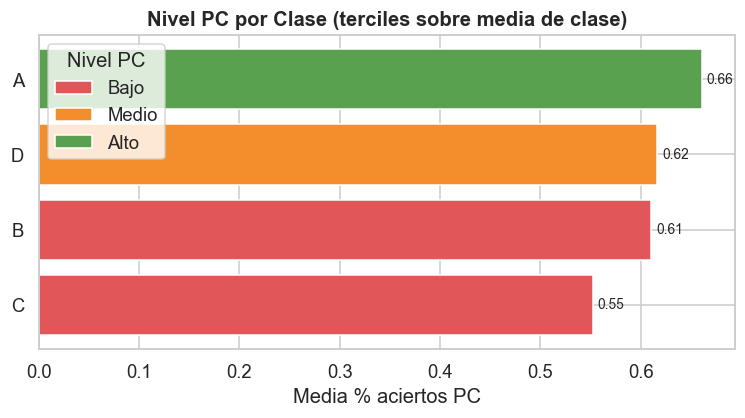

Figura guardada: pc_nivel_por_clase.png


In [9]:
# ─────────────────────────────────────────────────────────────────
# 6.1  Media de pct_pc por clase
# ─────────────────────────────────────────────────────────────────
logger.info("--- SECTION 6: CT Level by Class ---")

df_nivel_clase = (
    df_pc.groupby("Clase")["pct_pc"]
    .agg(["mean", "count", "std"])
    .reset_index()
    .rename(columns={"mean": "mean_pct_pc", "count": "N", "std": "sd_pct_pc"})
    .sort_values("Clase")
)

# Añadir Centro si existe en el CSV de PC
if "Centro" in df_pc.columns or "Colegio" in df_pc.columns:
    centro_col = "Centro" if "Centro" in df_pc.columns else "Colegio"
    centros = df_pc.groupby("Clase")[centro_col].first().reset_index()
    df_nivel_clase = df_nivel_clase.merge(centros, on="Clase", how="left")
    logger.info(f"Centro detectado en PC: {centros[centro_col].unique()}")
else:
    df_nivel_clase["Centro"] = "Echegaray"  # único centro en este dataset PC
    logger.info("Columna 'Centro' no presente en PC CSV → asignado 'Echegaray'")

print("Mean pct_pc by Class:")
display(style_table(df_nivel_clase, caption="Mean pct_pc by class"))

# ─────────────────────────────────────────────────────────────────
# 6.2  Asignación de nivel con terciles
# ─────────────────────────────────────────────────────────────────
n_clases = len(df_nivel_clase)
if n_clases < 3:
    logger.warning("[CT_LEVEL] Few classes for tertiles; using dense ranking")
    df_nivel_clase["rank_pc"] = df_nivel_clase["mean_pct_pc"].rank(method="dense")
    max_rank = df_nivel_clase["rank_pc"].max()
    cut1 = max_rank / 3
    cut2 = 2 * max_rank / 3
    df_nivel_clase["nivel_pc"] = pd.cut(
        df_nivel_clase["rank_pc"],
        bins=[-np.inf, cut1, cut2, np.inf],
        labels=["Low", "Medium", "High"],
    )
else:
    try:
        df_nivel_clase["nivel_pc"] = pd.qcut(
            df_nivel_clase["mean_pct_pc"],
            q=3,
            labels=["Low", "Medium", "High"],
            duplicates="drop",
        )
    except ValueError:
        logger.warning("[CT_LEVEL] qcut failed (repeated values). Using dense ranking + manual cutoffs.")
        df_nivel_clase["rank_pc"] = df_nivel_clase["mean_pct_pc"].rank(method="dense")
        max_rank = df_nivel_clase["rank_pc"].max()
        df_nivel_clase["nivel_pc"] = pd.cut(
            df_nivel_clase["rank_pc"],
            bins=[-np.inf, max_rank / 3, 2 * max_rank / 3, np.inf],
            labels=["Low", "Medium", "High"],
        )

logger.info("Asignación nivel PC por clase:")
for _, row in df_nivel_clase.iterrows():
    logger.info(f"  Class={row['Clase']} mean_pct={row['mean_pct_pc']:.3f} level={row['nivel_pc']}")

df_nivel_clase.to_csv(TABS / "nivel_pc_por_clase.csv", index=False, encoding="utf-8-sig")
print(f"\nCT level by class → {TABS / 'nivel_pc_por_clase.csv'}")
display(style_table(df_nivel_clase, caption="CT Level assigned by class (tertiles)", bar_col="mean_pct_pc", bar_range=(0, 1)))

# ─────────────────────────────────────────────────────────────────
# 6.3  Unir nivel_pc al dataset de alumnos PC
# ─────────────────────────────────────────────────────────────────
df_pc = df_pc.merge(df_nivel_clase[["Clase", "nivel_pc"]], on="Clase", how="left")
print("\nCT level distribution in CT students:")
display(style_table(
    df_pc["nivel_pc"].value_counts().to_frame().reset_index(),
    caption="CT students by class level",
))

# Figura barplot niveles
fig, ax = plt.subplots(figsize=(7, 4))
colors_nivel = {"Low": "#E15759", "Medium": "#F28E2B", "High": "#59A14F"}
df_nivel_clase_plot = df_nivel_clase.sort_values("mean_pct_pc")
ax.barh(
    df_nivel_clase_plot["Clase"],
    df_nivel_clase_plot["mean_pct_pc"],
    color=[colors_nivel.get(str(n), "gray") for n in df_nivel_clase_plot["nivel_pc"]],
)
ax.set_xlabel("Mean % correct CT")
ax.set_title("CT Level by Class (tertiles on class mean)", fontweight="bold")
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in colors_nivel.items()]
ax.legend(handles=legend_elements, title="CT Level")
for i, row in df_nivel_clase_plot.iterrows():
    ax.text(row["mean_pct_pc"] + 0.005, list(df_nivel_clase_plot["Clase"]).index(row["Clase"]),
            f"{row['mean_pct_pc']:.2f}", va="center", fontsize=9)
fig.tight_layout()
fig.savefig(FIGS / "pc_nivel_por_clase.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figure saved: pc_nivel_por_clase.png")

## 7. History (Excel): Enriched Analysis + CT Level + Categories

**What this section does:** Performs the complete analysis of History learning in a pre-post design with **independent samples**. The `Student` index in the data represents the response order — it does not identify the same student across initial and final tests — so individual observations cannot be paired.

| Subsection | Content |
|-----------|-----------|
| **7.1–7.2** | Preparation and cleaning of initial and final tests; independent samples design by class |
| **7.3** | Calculation of absolute gain per class and group Hake (over class means, not individual) |
| **7.4** | Enrichment with class CT level (Echegaray only) and item thematic categories |
| **7.5** | Global and per-class descriptives; boxplots, histograms, category × CT level heatmap |
| **7.6–7.8** | Inference: Welch-t / Mann-Whitney U (initial vs final, indep.); ANOVA/KW by CT level; OLS model |
| **7.9–7.14** | Item psychometrics (difficulty, discrimination, co-errors); between-class comparisons |

**Why:** Integrating CT level as a moderator of History gain allows answering whether classes with better computational thinking also learn more History, which would reveal a possible transfer of cognitive capacities between domains. Hake gain corrects the ceiling effect and allows comparing classes with different starting levels.


2026-06-12 12:50:39,886 [INFO] --- SECCIÓN 7: Historia (muestras independientes) ---
2026-06-12 12:50:39,911 [INFO]   Historia Inicial: 93 filas, 8 ítems
2026-06-12 12:50:40,046 [INFO]   Historia Final: 82 filas, 11 ítems
Historia Inicial: (93, 15) | ítems: ['P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8']
Historia Final:   (82, 18) | ítems: ['P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'P9', 'P10', 'P11']
2026-06-12 12:50:40,062 [INFO]   nivel_pc asignado: 93 | sin asignar: 0
2026-06-12 12:50:40,077 [INFO]   nivel_pc asignado: 82 | sin asignar: 0

Historia Inicial: N=93 | media=0.781 SD=0.177
Historia Final:   N=82 | media=0.796 SD=0.139

⚠ Diseño: MUESTRAS INDEPENDIENTES — sin emparejamiento individual por alumno

nivel_pc — Inicial:


nivel_pc,count
Bajo,46
Medio,24
Alto,23



nivel_pc — Final:


nivel_pc,count
Bajo,43
Alto,21
Medio,18



Mapa categorías Inicial: {'P1': 'Algoritmia', 'P2': 'Prehistoria', 'P3': 'Edad Moderna', 'P4': 'Edad Antigua', 'P5': 'Edad Contemporanea', 'P6': 'Edad Media', 'P7': 'Programacion/Robotica', 'P8': 'Programacion/Robotica'}
Mapa categorías Final:   {'P1': 'Algoritmia', 'P2': 'Prehistoria', 'P3': 'Prehistoria', 'P4': 'Edad Antigua', 'P5': 'Edad Antigua', 'P6': 'Edad Media', 'P7': 'Edad Media', 'P8': 'Edad Moderna', 'P9': 'Edad Moderna', 'P10': 'Edad Contemporanea', 'P11': 'Edad Contemporanea', 'P12': 'Respuesta libre', 'P13': 'Respuesta libre'}

Dataset largo historia: (1646, 9)

Tabla categoría×nivel_pc → outputs\tables\historia_categoria_stats.csv


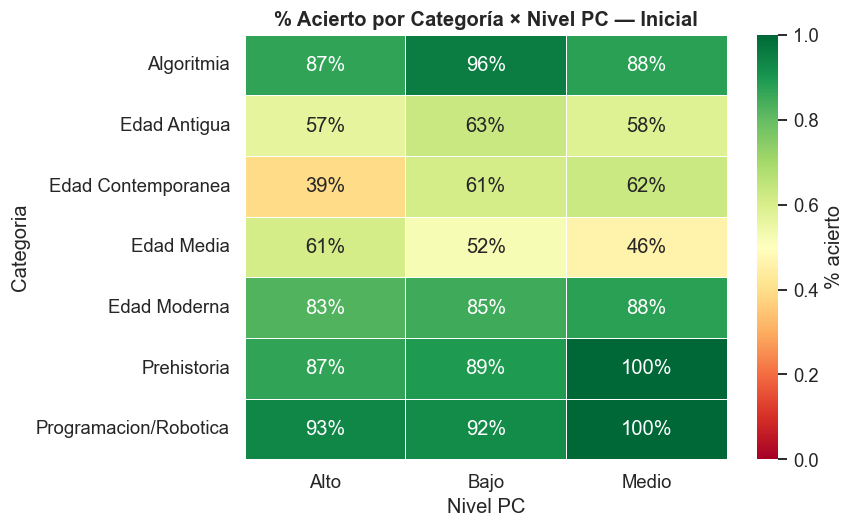

Figura guardada: historia_heatmap_cat_nivel_inicial.png


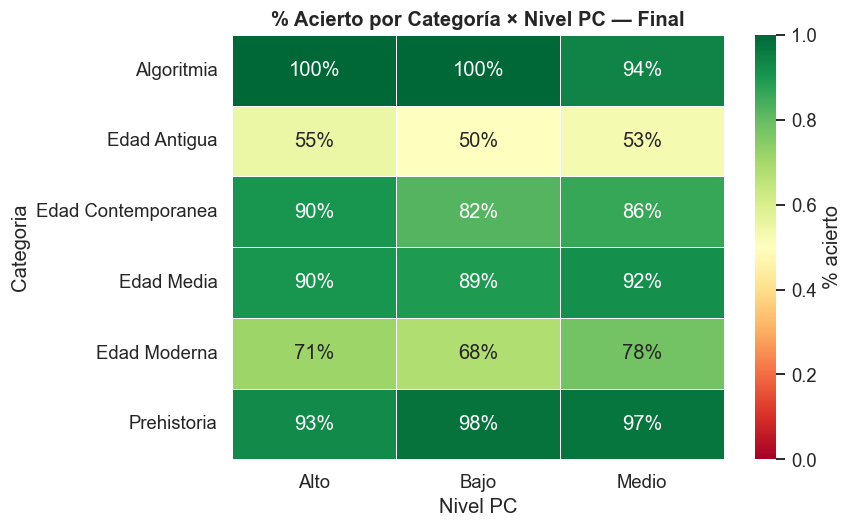

Figura guardada: historia_heatmap_cat_nivel_final.png

Resumen historia → outputs\tables\historia_resumen_por_grupo.csv


Momento,Agrupación,Grupo,N,Media,SD,IC95_lo,IC95_hi
Inicial,Global,Global,93,0.781,0.177,0.745,0.817
Final,Global,Global,82,0.796,0.139,0.765,0.825


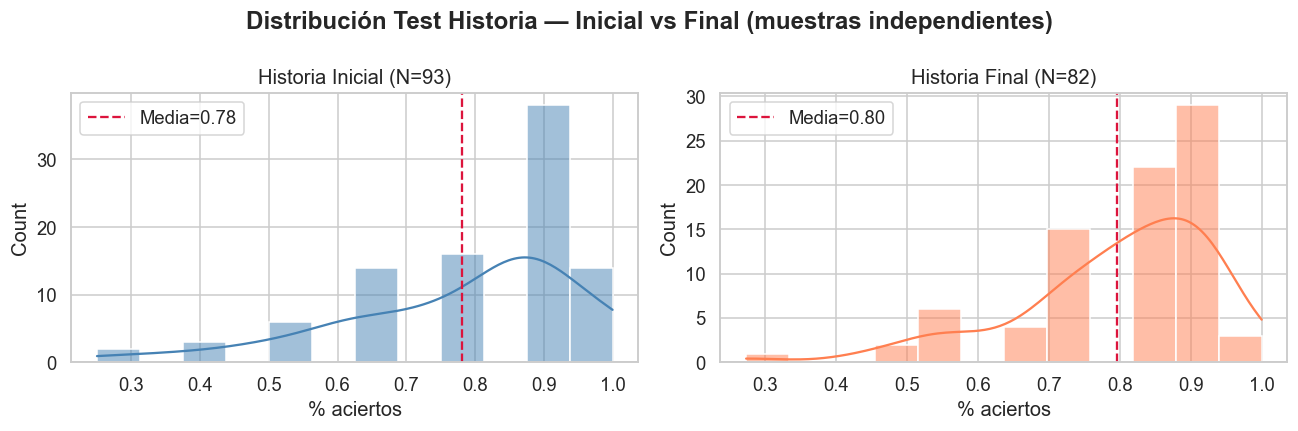

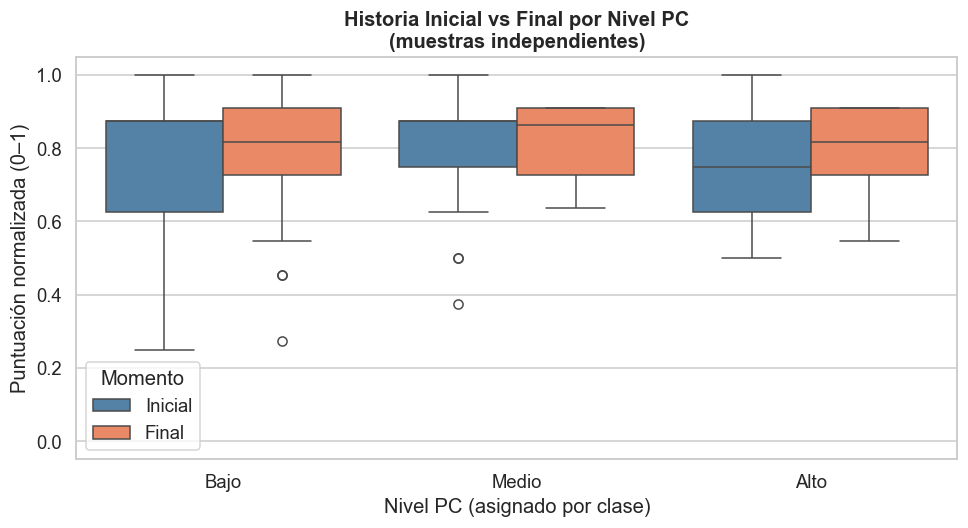

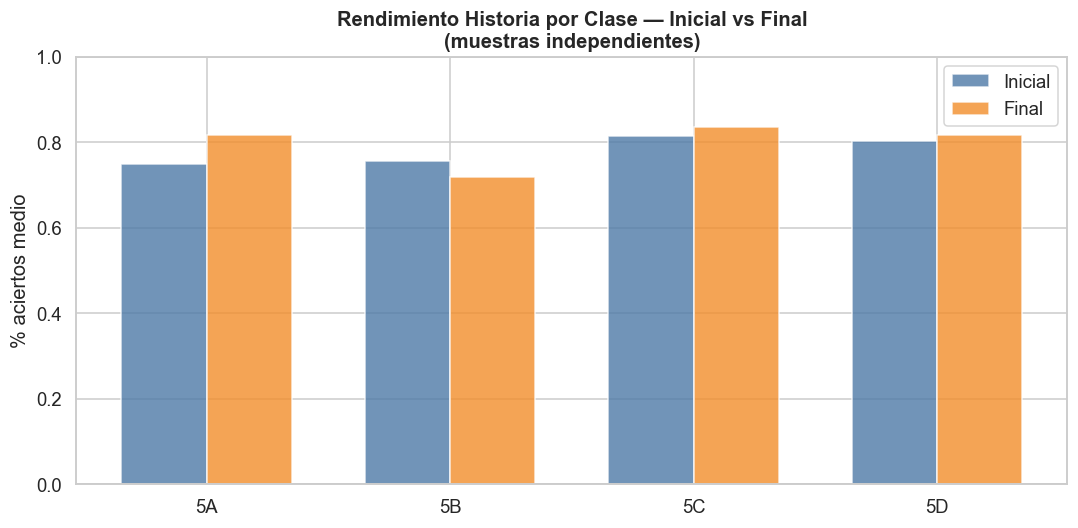

Figuras 7.7 guardadas OK
2026-06-12 12:50:51,478 [INFO]   Inferencia historia (muestras independientes)...

Test global ini vs fin (Mann-Whitney U): stat=4004.0000 p=0.5651
  Δ medias (fin−ini): +0.015  IC95=[-0.030, 0.062]

Kruskal-Wallis pct_hist(Final) × Nivel PC: stat=1.1948 p=0.5502 ef=-0.010

Kruskal-Wallis pct_hist(Inicial) × Nivel PC: stat=2.8731 p=0.2377 ef=0.010

=== Modelo Lineal: pct_hist(Final) ~ nivel_pc + Colegio ===
              Coef.  Std.Err.      t  P>|t|  [0.025  0.975]
Intercept     0.779     0.020 38.477  0.000   0.739   0.820
nivel_pc_num  0.023     0.018  1.261  0.211  -0.013   0.059
2026-06-12 12:50:51,863 [INFO] Modelo lineal historia Final: R²=0.019

Contrastes historia → outputs\tables\historia_contrastes.csv

=== Ganancia de Hake grupal por clase (Historia — muestras indep.) ===


Clase,n_ini,mean_pct_ini,std_ini,n_fin,mean_pct_fin,std_fin,ganancia_abs,hake_g,categoria_hake
5A,23,0.750,0.141,21,0.818,0.108,0.068,0.273,Baja (<0.30)
5B,23,0.755,0.215,22,0.719,0.153,-0.036,-0.149,Baja (<0.30)
5C,23,0.815,0.195,21,0.835,0.151,0.020,0.110,Baja (<0.30)
5D,24,0.802,0.152,18,0.818,0.108,0.016,0.081,Baja (<0.30)



  Global: N_ini=93 N_fin=82 | pct_ini=0.781 | pct_fin=0.796 | Hake g=+0.069


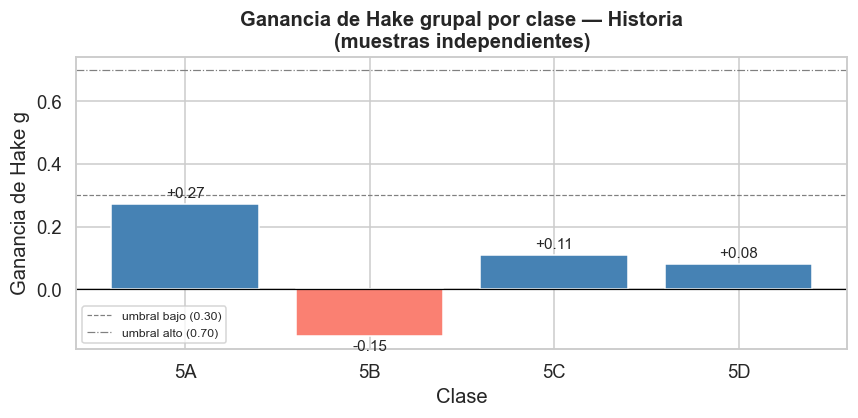

Figura guardada: historia_hake_por_clase.png


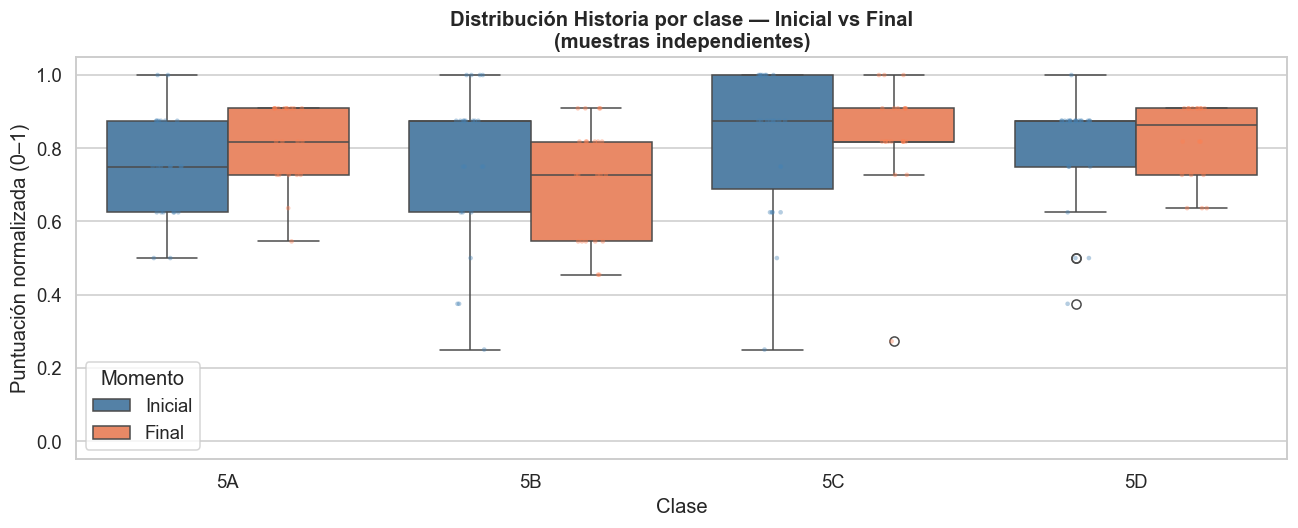

Figura guardada: historia_boxplot_ini_fin_clase.png


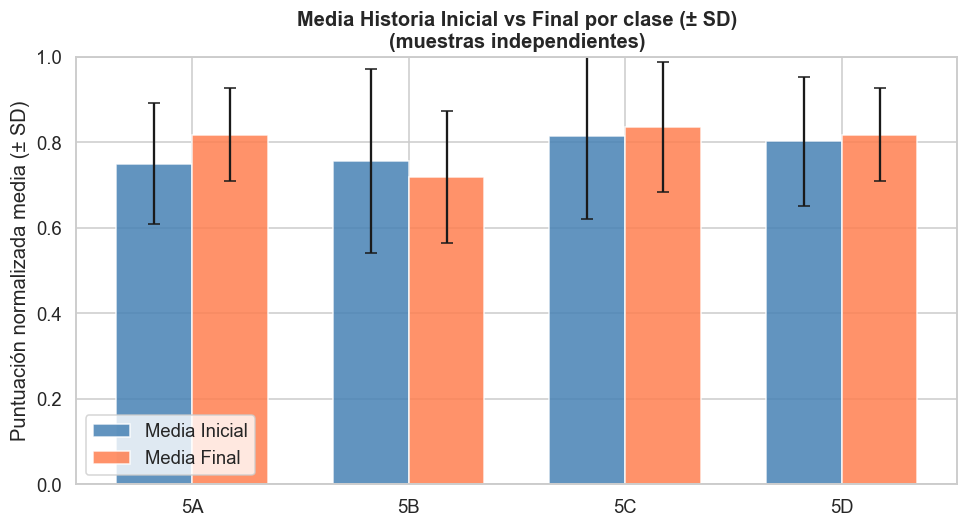

Figura guardada: historia_medias_ini_fin_clase.png


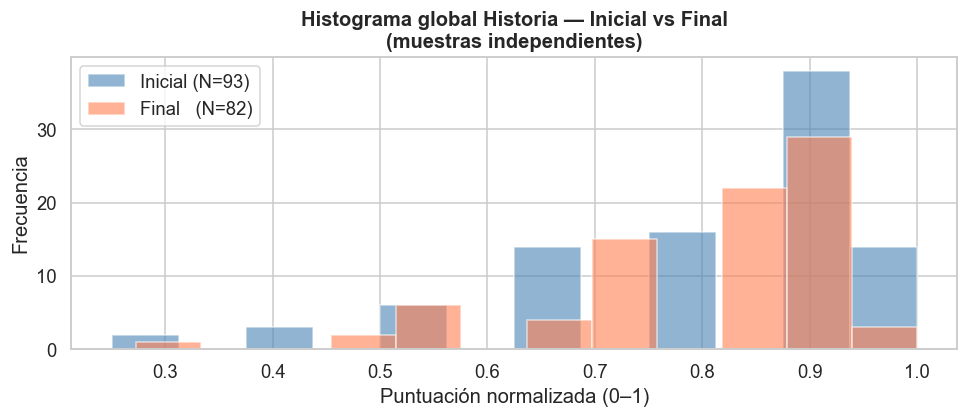

Figura guardada: historia_histograma_global.png

=== Cohen's d Historia (muestras independientes: Final vs Inicial) ===


grupo,N_ini,N_fin,media_ini,media_fin,Cohen_d,IC95_lo,IC95_hi
GLOBAL,93,82,0.781,0.796,0.094,-0.195,0.393
Clase 5A,23,21,0.750,0.818,0.540,-0.037,1.269
Clase 5B,23,22,0.755,0.719,-0.194,-0.872,0.398
Clase 5C,23,21,0.815,0.835,0.115,-0.476,0.705
Clase 5D,24,18,0.802,0.818,0.119,-0.569,0.627


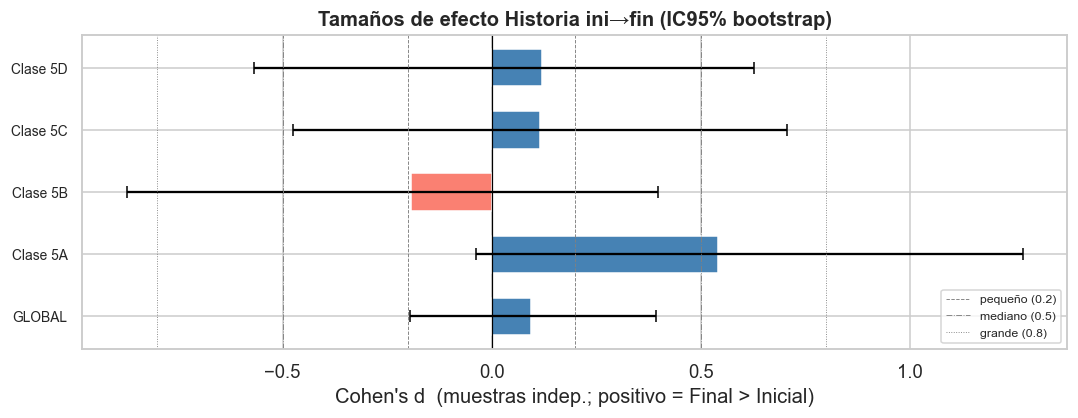

Figura guardada: historia_effect_sizes.png

=== Comparaciones entre clases (Historia) ===


Contraste,Método,Estadístico,p,Sig
Inicial — entre clases,Kruskal-Wallis,4.210,0.240,False
Final — entre clases,Kruskal-Wallis,9.385,0.025,True



→ Inicial: p ≥ 0.05 — sin diferencias significativas entre clases.

=== Post-hoc Mann-Whitney + Bonferroni: Final ===


grupo1,grupo2,p_raw,p_bonferroni,sig
5A,5B,0.028,0.169,False
5A,5C,0.460,1.000,False
5A,5D,1.000,1.000,False
5B,5C,0.006,0.039,True
5B,5D,0.034,0.201,False
5C,5D,0.516,1.000,False


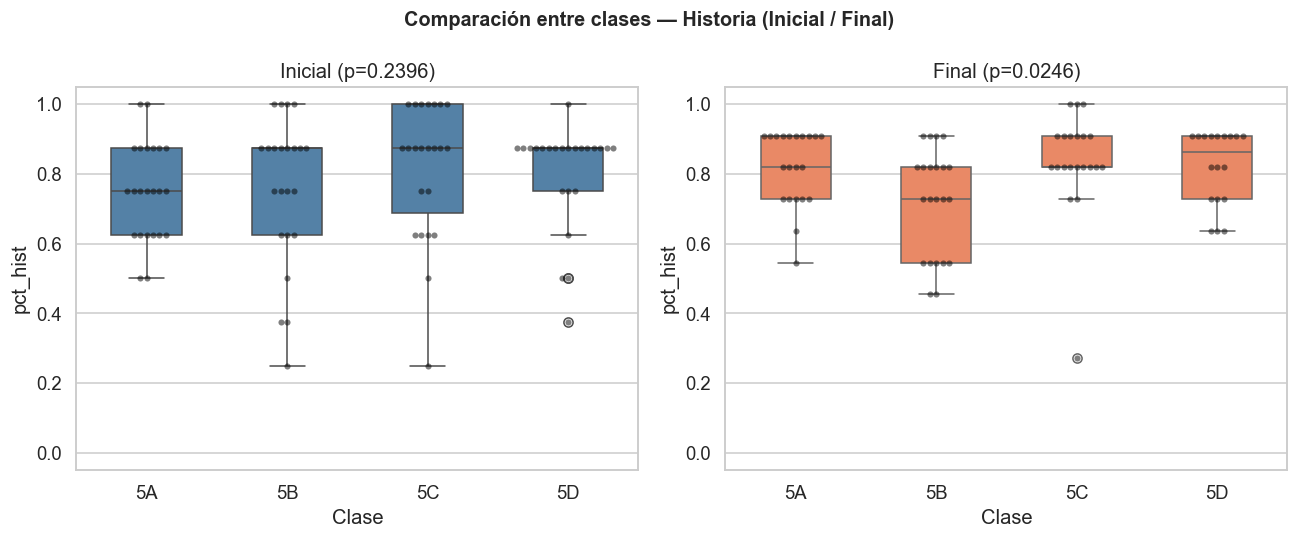

Figura guardada: historia_comparacion_clases.png

=== Análisis psicométrico por ítem — Historia ===


Pregunta,dificultad_p,disc_pbis,disc_D27,test,Categoria
P1,0.914,0.407,0.200,Inicial,Algoritmia
P2,0.914,0.516,0.280,Inicial,Prehistoria
P3,0.849,0.628,0.560,Inicial,Edad Moderna
P4,0.602,0.594,0.720,Inicial,Edad Antigua
P5,0.559,0.539,0.720,Inicial,Edad Contemporanea
P6,0.527,0.441,0.560,Inicial,Edad Media
P7,0.978,0.394,0.080,Inicial,Programacion/Robotica
P8,0.913,0.303,0.127,Inicial,Programacion/Robotica
P1,0.988,-0.091,0.000,Final,Algoritmia
P2,1.000,—,0.000,Final,Prehistoria


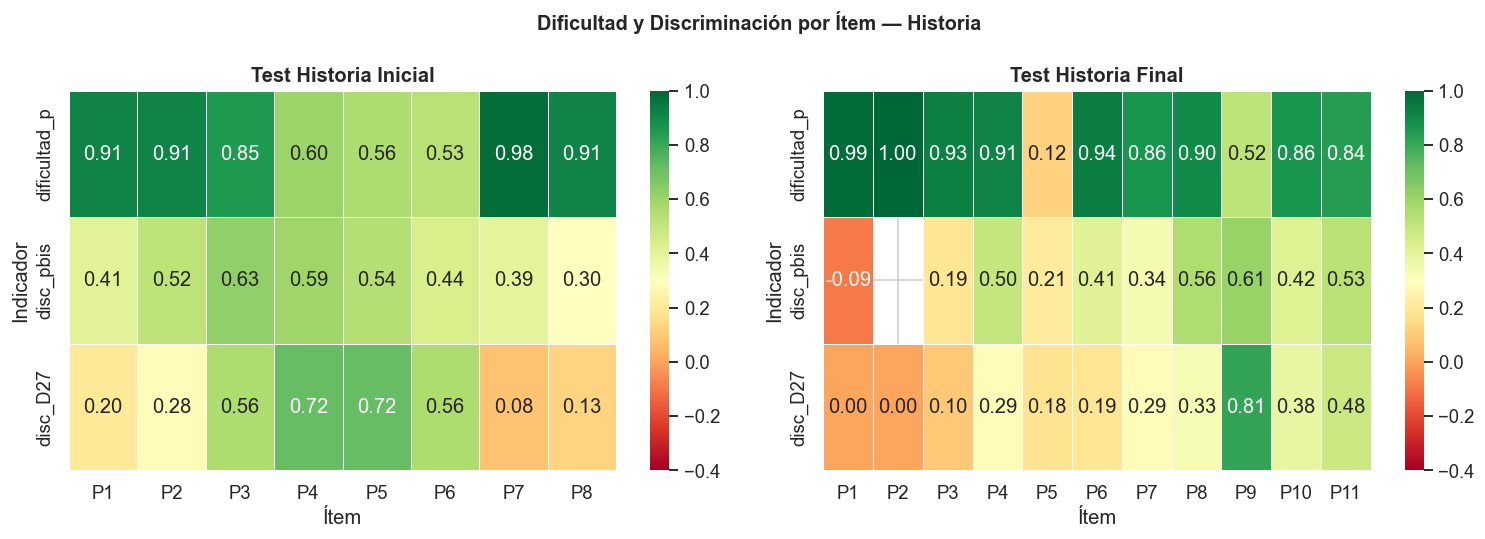

Figura guardada: historia_heatmap_items.png


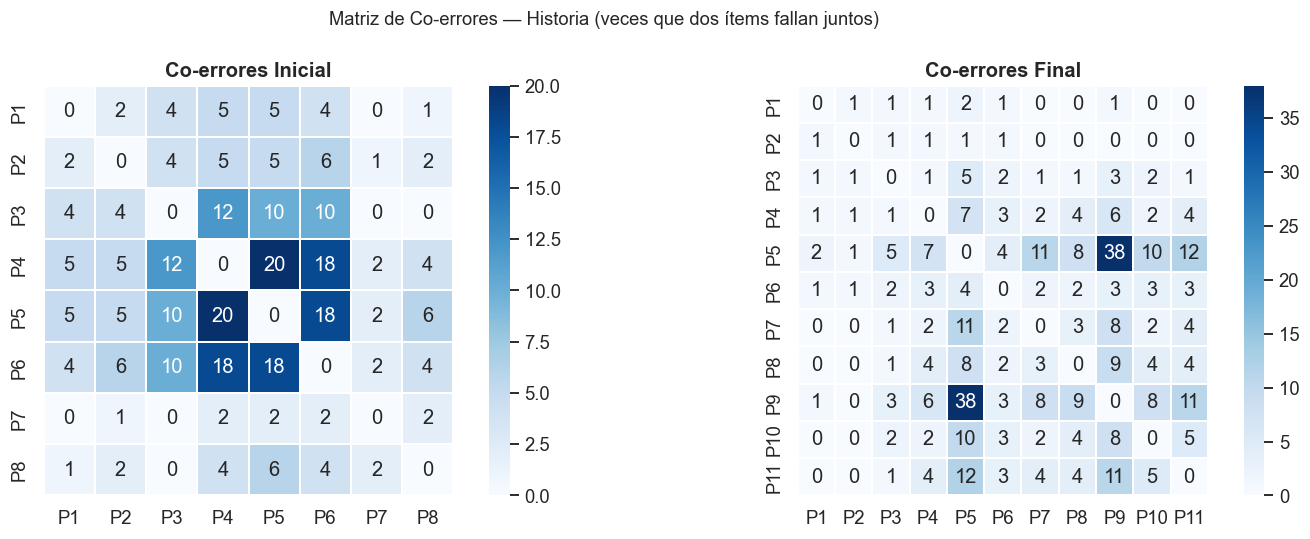

Figura guardada: historia_coerror_matrix.png


In [10]:
# ─────────────────────────────────────────────────────────────────
# 7.1  Preparar Historia Inicial y Final
# ─────────────────────────────────────────────────────────────────
logger.info("--- SECTION 7: History (independent samples) ---")

def prep_historia(df_raw, tipo="Inicial"):
    """Cleans and prepares a history test."""
    df = df_raw.copy()
    df.columns = [str(c).strip() for c in df.columns]
    p_cols = [c for c in df.columns if re.match(r"^P\d+$", c)]
    total_col_raw = [c for c in df.columns if "TOTAL" in c.upper()]
    total_col = total_col_raw[0] if total_col_raw else None
    if total_col and total_col != "TOTAL":
        df.rename(columns={total_col: "TOTAL"}, inplace=True)
        logger.info(f"  History {tipo}: TOTAL column renamed from '{total_col}'")
    for col in p_cols:
        df[col] = coerce_01(df[col], col_name=f"{tipo}/{col}")
    if "TOTAL" in df.columns and p_cols:
        total_calc = df[p_cols].sum(axis=1)
        total_orig = ensure_numeric(df["TOTAL"], "TOTAL")
        discrepantes = ((total_calc - total_orig).abs() > 0.5) & total_orig.notna()
        if discrepantes.sum() > 0:
            log_anomaly(f"Historia {tipo}: {discrepantes.sum()} filas con TOTAL discrepante → recalculado")
            df.loc[discrepantes, "TOTAL"] = total_calc[discrepantes]
    elif p_cols:
        df["TOTAL"] = df[p_cols].sum(axis=1)
    df["Clase"]   = df["Clase"].astype(str).str.strip()
    df["Colegio"] = df["Colegio"].astype(str).str.strip() if "Colegio" in df.columns else "Unknown"
    df["Alumno"]  = df["Alumno"].astype(str).str.strip()
    df["ID_hist"] = df["Colegio"] + "-" + df["Clase"] + "-" + df["Alumno"]
    df["Type"]    = tipo
    logger.info(f"  History {tipo}: {df.shape[0]} rows, {len(p_cols)} items")
    return df, p_cols


df_ini, p_cols_ini = prep_historia(df_hist_ini, "Inicial")
df_fin, p_cols_fin = prep_historia(df_hist_fin, "Final")
n_items_ini = len(p_cols_ini)
n_items_fin = len(p_cols_fin)
print(f"History Initial: {df_ini.shape} | items: {p_cols_ini}")
print(f"History Final:   {df_fin.shape} | items: {p_cols_fin}")

df_ini["pct_hist"] = df_ini["TOTAL"] / n_items_ini
df_fin["pct_hist"] = df_fin["TOTAL"] / n_items_fin

# ─────────────────────────────────────────────────────────────────
# 7.2  Muestras INDEPENDIENTES — asignar nivel_pc por clase
# ─────────────────────────────────────────────────────────────────
# ⚠ DECISIÓN METODOLÓGICA:
#   Los índices de alumno (columna "Alumno") en el test inicial y en el test
#   final son indicadores internos de recogida de información, NO permiten
#   identificar al mismo estudiante en ambos tests.
#   → Se tratan como DOS MUESTRAS INDEPENDIENTES del mismo grupo-clase.
#
# Consecuencias:
#   • No se calculan ganancias individuales (pct_fin_i − pct_ini_i).
#   • Las comparaciones se realizan a nivel de GRUPO/CLASE (diferencias de medias).
#   • La ganancia de Hake se calcula a nivel de clase:
#       g = (mean_fin_clase − mean_ini_clase) / (1 − mean_ini_clase)
#   • Los tests estadísticos empleados son de dos muestras independientes
#     (Welch-t o Mann-Whitney U).
# ─────────────────────────────────────────────────────────────────
df_nivel_map = df_nivel_clase[["Clase", "nivel_pc", "Centro"]].copy()
df_nivel_map["Clase_hist"] = "5" + df_nivel_map["Clase"].str.upper()
df_ini["Clase_hist"] = df_ini["Clase"].astype(str).str.strip()
df_fin["Clase_hist"] = df_fin["Clase"].astype(str).str.strip()


def map_nivel_pc(df, nivel_map, clase_col="Clase_hist", colegio_col="Colegio"):
    """Joins ct_level by class. If another school, leaves NaN."""
    df = df.copy()
    df["nivel_pc"] = None
    mask_echegaray = df[colegio_col].str.contains("Echegaray", case=False, na=False)
    clase_to_nivel = dict(zip(nivel_map["Clase_hist"], nivel_map["nivel_pc"].astype(str)))
    mapped = df.loc[mask_echegaray, clase_col].map(clase_to_nivel)
    df.loc[mask_echegaray, "nivel_pc"] = mapped.values
    n_asig = df["nivel_pc"].notna().sum()
    n_nan  = df["nivel_pc"].isna().sum()
    logger.info(f"  ct_level assigned: {n_asig} | unassigned: {n_nan}")
    return df


df_ini = map_nivel_pc(df_ini, df_nivel_map)
df_fin = map_nivel_pc(df_fin, df_nivel_map)

print(f"\nHistory Initial: N={len(df_ini)} | mean={df_ini['pct_hist'].mean():.3f}"
      f" SD={df_ini['pct_hist'].std():.3f}")
print(f"History Final:   N={len(df_fin)} | mean={df_fin['pct_hist'].mean():.3f}"
      f" SD={df_fin['pct_hist'].std():.3f}")
print("\n⚠ Design: INDEPENDENT SAMPLES — no individual student pairing")

print(f"\nCT level — Initial:")
display(style_table(df_ini["nivel_pc"].value_counts(dropna=False).to_frame().reset_index(), caption="CT Level Distribution — History Initial"))
print(f"\nCT level — Final:")
display(style_table(df_fin["nivel_pc"].value_counts(dropna=False).to_frame().reset_index(), caption="CT Level Distribution — History Final"))

# ─────────────────────────────────────────────────────────────────
# 7.3  Categorías de preguntas (category_questions.xlsx)
# ─────────────────────────────────────────────────────────────────
df_cat_clean = df_cat.copy()
df_cat_clean.columns = [c.strip() for c in df_cat_clean.columns]
cat_ini_map = (
    df_cat_clean[df_cat_clean["Test"] == "Inicial"]
    .set_index("Pregunta")["Tematica"].to_dict()
)
cat_fin_map = (
    df_cat_clean[df_cat_clean["Test"] == "Final"]
    .set_index("Pregunta")["Tematica"].to_dict()
)
print("\nInitial category map:", cat_ini_map)
print("Final category map:  ", cat_fin_map)

# ─────────────────────────────────────────────────────────────────
# 7.4  Formato largo (nivel_pc ya asignado — no requiere nuevo join)
# ─────────────────────────────────────────────────────────────────
def to_long(df, p_cols, cat_map, momento):
    """Converts to long format. ct_level already included in df."""
    rows = []
    for _, row in df.iterrows():
        for p in p_cols:
            rows.append({
                "ID_hist":   row.get("ID_hist"),
                "Centro":    row.get("Colegio"),
                "Clase":     row.get("Clase"),
                "Alumno":    row.get("Alumno"),
                "nivel_pc":  row.get("nivel_pc"),
                "Timepoint":   momento,
                "Pregunta":  p.upper(),
                "Correct":   row.get(p),
                "Category": cat_map.get(p.upper(), "Unknown"),
            })
    return pd.DataFrame(rows)


df_long_ini = to_long(df_ini, p_cols_ini, cat_ini_map, "Inicial")
df_long_fin = to_long(df_fin, p_cols_fin, cat_fin_map, "Final")
df_long = pd.concat([df_long_ini, df_long_fin], ignore_index=True)
df_long["Correct"] = pd.to_numeric(df_long["Correct"], errors="coerce")
print(f"\nLong history dataset: {df_long.shape}")

# ─────────────────────────────────────────────────────────────────
# 7.5  Métricas por categoría × nivel_pc (heatmap)
# ─────────────────────────────────────────────────────────────────
df_cat_stats = (
    df_long.groupby(["Timepoint", "Category", "nivel_pc"])["Correct"]
    .agg(["mean", "count", "sum"])
    .reset_index()
    .rename(columns={"mean": "pct_acierto", "count": "N", "sum": "n_aciertos"})
)
df_cat_stats.to_csv(TABS / "historia_categoria_stats.csv", index=False, encoding="utf-8-sig")
print(f"\nTable category×CT_level → {TABS / 'historia_categoria_stats.csv'}")

for momento in ["Inicial", "Final"]:
    sub = df_cat_stats[df_cat_stats["Timepoint"] == momento].dropna(subset=["nivel_pc"])
    if sub.empty:
        continue
    pivot = sub.pivot_table(index="Category", columns="nivel_pc",
                             values="pct_acierto", aggfunc="mean")
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.heatmap(pivot, annot=True, fmt=".0%", cmap="RdYlGn", vmin=0, vmax=1,
                linewidths=0.4, ax=ax, cbar_kws={"label": "% correct"})
    ax.set_title(f"% Correct by Category × CT Level — {momento}", fontweight="bold")
    ax.set_xlabel("CT Level")
    fig.tight_layout()
    fig.savefig(FIGS / f"historia_heatmap_cat_nivel_{momento.lower()}.png",
                dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Figure saved: historia_heatmap_cat_nivel_{momento.lower()}.png")

# ─────────────────────────────────────────────────────────────────
# 7.6  Descriptivos por Momento × grupo (muestras independientes)
# ─────────────────────────────────────────────────────────────────
hist_resumen_rows = []
for momento, df_m in [("Inicial", df_ini), ("Final", df_fin)]:
    for gcol in [None, "Clase", "nivel_pc"]:
        if gcol is None:
            subsets = [("Global", df_m)]
        else:
            subsets = [(g, df_m[df_m[gcol] == g])
                       for g in sorted(df_m[gcol].dropna().unique())]
        for label, sub in subsets:
            x = sub["pct_hist"].dropna().values
            ci_lo, ci_hi = bootstrap_ci(x, np.mean, n_boot=2000)
            hist_resumen_rows.append({
                "Timepoint":    momento,
                "Grouping": gcol or "Global",
                "Group":      label,
                "N":          len(x),
                "Media":      round(np.mean(x), 3) if len(x) else np.nan,
                "SD":         round(np.std(x, ddof=1), 3) if len(x) > 1 else np.nan,
                "IC95_lo":    round(ci_lo, 3),
                "IC95_hi":    round(ci_hi, 3),
            })

df_hist_resumen = pd.DataFrame(hist_resumen_rows)
df_hist_resumen.to_csv(TABS / "historia_resumen_por_grupo.csv", index=False, encoding="utf-8-sig")
print(f"\nHistory summary → {TABS / 'historia_resumen_por_grupo.csv'}")
display(style_table(df_hist_resumen[df_hist_resumen["Grouping"] == "Global"], caption="Global Descriptive Summary — History (initial and final)"))

# ─────────────────────────────────────────────────────────────────
# 7.7  Figuras básicas — distribución y comparación por grupo
# ─────────────────────────────────────────────────────────────────
niv_order = ["Low", "Medium", "High"]

# Histogramas superpuestos (dos distribuciones independientes)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (df_m, label, color) in zip(axes, [
    (df_ini, "Inicial", "steelblue"),
    (df_fin, "Final",   "coral"),
]):
    vals = df_m["pct_hist"].dropna()
    sns.histplot(vals, kde=True, ax=ax, bins=12, color=color)
    ax.axvline(vals.mean(), color="crimson", ls="--", lw=1.5,
               label=f"Media={vals.mean():.2f}")
    ax.set_xlabel("% correct")
    ax.set_title(f"Historia {label} (N={len(vals)})")
    ax.legend()
fig.suptitle("History Test Distribution — Initial vs Final (independent samples)",
             fontweight="bold")
fig.tight_layout()
fig.savefig(FIGS / "historia_distribucion.png", dpi=120, bbox_inches="tight")
plt.show()

# Boxplot ini vs fin por nivel_pc (muestras independientes)
df_long_compare = pd.concat([
    df_ini[["Clase", "nivel_pc", "pct_hist"]].assign(Momento="Inicial"),
    df_fin[["Clase", "nivel_pc", "pct_hist"]].assign(Momento="Final"),
], ignore_index=True)
df_long_compare_niv = df_long_compare.dropna(subset=["nivel_pc"])

fig2, ax2 = plt.subplots(figsize=(9, 5))
sns.boxplot(
    data=df_long_compare_niv, x="nivel_pc", y="pct_hist", hue="Timepoint",
    order=niv_order, palette={"Inicial": "steelblue", "Final": "coral"}, ax=ax2,
)
ax2.set_xlabel("CT Level (assigned by class)")
ax2.set_ylabel("Normalised score (0–1)")
ax2.set_title("History Initial vs Final by CT Level\n(independent samples)",
              fontweight="bold")
ax2.legend(title="Timepoint")
ax2.set_ylim(-0.05, 1.05)
fig2.tight_layout()
fig2.savefig(FIGS / "historia_ganancia_por_nivel_pc.png", dpi=120, bbox_inches="tight")
plt.show()

# Barplot medias por clase (muestras independientes)
clases_hist = sorted(set(df_ini["Clase"].unique()) | set(df_fin["Clase"].unique()))
x_pos = np.arange(len(clases_hist))
w = 0.35
fig3, ax3 = plt.subplots(figsize=(10, 5))
for i, (df_m, label, color) in enumerate([
    (df_ini, "Inicial", "#4E79A7"),
    (df_fin, "Final",   "#F28E2B"),
]):
    means_c = [df_m.loc[df_m["Clase"] == c, "pct_hist"].mean() for c in clases_hist]
    ax3.bar(x_pos + (i - 0.5) * w, means_c, w, label=label, color=color, alpha=0.8)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(clases_hist)
ax3.set_ylabel("% aciertos medio")
ax3.set_ylim(0, 1)
ax3.set_title("History Performance by Class — Initial vs Final\n(independent samples)",
              fontweight="bold")
ax3.legend()
fig3.tight_layout()
fig3.savefig(FIGS / "historia_rendimiento_por_clase.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figures 7.7 saved OK")

# ─────────────────────────────────────────────────────────────────
# 7.8  Inferencia — muestras independientes
# ─────────────────────────────────────────────────────────────────
logger.info("  History inference (independent samples)...")
contraste_hist_rows = []

ini_all = df_ini["pct_hist"].dropna().values
fin_all = df_fin["pct_hist"].dropna().values


def _bootstrap_2samp_ci(x, y, stat_func, n_boot=2000):
    """Bootstrap CI for two independent samples statistics."""
    rng = np.random.default_rng(42)
    boots = [
        stat_func(
            rng.choice(x, len(x), replace=True),
            rng.choice(y, len(y), replace=True),
        )
        for _ in range(n_boot)
    ]
    boots = [b for b in boots if b is not None and not np.isnan(b)]
    return (np.percentile(boots, 2.5), np.percentile(boots, 97.5)) if boots else (np.nan, np.nan)


# 7.8a  Contraste global ini vs fin
sw_ini_p = stats.shapiro(ini_all).pvalue if len(ini_all) >= 3 else 0.0
sw_fin_p = stats.shapiro(fin_all).pvalue if len(fin_all) >= 3 else 0.0
use_t    = sw_ini_p > 0.05 and sw_fin_p > 0.05
if use_t:
    stat_g, p_g   = stats.ttest_ind(fin_all, ini_all, equal_var=False)
    test_name_g   = "Welch-t"
else:
    stat_g, p_g   = stats.mannwhitneyu(fin_all, ini_all, alternative="two-sided")
    test_name_g   = "Mann-Whitney U"

diff_means_g = fin_all.mean() - ini_all.mean()
ci_lo_g, ci_hi_g = _bootstrap_2samp_ci(
    ini_all, fin_all, lambda x, y: y.mean() - x.mean()
)
contraste_hist_rows.append({
    "Contraste": "Global ini vs fin (indep.)",
    "Test": test_name_g,
    "N_ini": len(ini_all), "N_fin": len(fin_all),
    "mean_ini": round(ini_all.mean(), 3), "mean_fin": round(fin_all.mean(), 3),
    "diff_means": round(diff_means_g, 3),
    "IC95_lo": round(ci_lo_g, 3), "IC95_hi": round(ci_hi_g, 3),
    "Statistic": round(float(stat_g), 4), "p_value": round(p_g, 4),
})
print(f"\nGlobal test ini vs fin ({test_name_g}): stat={stat_g:.4f} p={p_g:.4f}")
print(f"  Δ means (fin−ini): {diff_means_g:+.3f}  CI95=[{ci_lo_g:.3f}, {ci_hi_g:.3f}]")

# 7.8b  Contraste pct_hist (ini y fin por separado) × nivel_pc
for momento, df_m in [("Final", df_fin), ("Inicial", df_ini)]:
    niveles = [n for n in niv_order if n in df_m["nivel_pc"].values]
    groups  = [df_m.loc[df_m["nivel_pc"] == n, "pct_hist"].dropna().values for n in niveles]
    valid   = [(n, g) for n, g in zip(niveles, groups) if len(g) >= 2]
    if len(valid) < 2:
        continue
    data_v    = [g for _, g in valid]
    all_norm  = all((stats.shapiro(g).pvalue > 0.05 if len(g) >= 3 else False) for g in data_v)
    if all_norm:
        stat_om, p_om = stats.f_oneway(*data_v)
        method_om = "ANOVA"
        grand_m = np.concatenate(data_v).mean()
        ss_b = sum(len(g) * (g.mean() - grand_m) ** 2 for g in data_v)
        ss_t = sum(((x - grand_m) ** 2).sum() for g in data_v for x in g)
        ef_om = round(ss_b / ss_t, 3) if ss_t > 0 else np.nan
        tipo_ef = "eta^2"
    else:
        stat_om, p_om = stats.kruskal(*data_v)
        method_om = "Kruskal-Wallis"
        n_tot = sum(len(g) for g in data_v)
        ef_om = round((stat_om - len(data_v) + 1) / (n_tot - len(data_v)), 3)
        tipo_ef = "epsilon^2"
    contraste_hist_rows.append({
        "Contraste": f"{momento} por Nivel PC (omnibus)",
        "Test": method_om,
        "N_ini": len(ini_all), "N_fin": len(fin_all),
        "Statistic": round(float(stat_om), 3), "p_value": round(p_om, 4),
        "effect": ef_om, "effect_type": tipo_ef,
    })
    print(f"\n{method_om} pct_hist({momento}) × Nivel PC: stat={stat_om:.4f}"
          f" p={p_om:.4f} ef={ef_om:.3f}")
    if p_om < 0.05 and len(valid) >= 3:
        for (n1, g1), (n2, g2) in itertools.combinations(valid, 2):
            _, p_ph = stats.mannwhitneyu(g1, g2, alternative="two-sided")
            p_corr  = min(p_ph * len(list(itertools.combinations(valid, 2))), 1)
            print(f"  Post-hoc {n1} vs {n2}: MWU p_raw={p_ph:.4f} p_bonf={p_corr:.4f}")

# 7.8c  OLS: pct_hist(Final) ~ nivel_pc + Colegio
df_fin_model = df_fin.dropna(subset=["pct_hist", "nivel_pc"]).copy()
if len(df_fin_model) >= 10 and df_fin_model["nivel_pc"].nunique() >= 2:
    try:
        df_fin_model["nivel_pc_num"] = df_fin_model["nivel_pc"].map({"Low": 0, "Medium": 1, "High": 2})
        mod_fin = smf.ols("pct_hist ~ nivel_pc_num + C(Colegio)", data=df_fin_model).fit()
        print("\n=== Modelo Lineal: pct_hist(Final) ~ nivel_pc + Colegio ===")
        print(mod_fin.summary2().tables[1].round(4))
        logger.info(f"Modelo lineal historia Final: R²={mod_fin.rsquared:.3f}")
        contraste_hist_rows.append({
            "Contraste": "OLS pct_hist(Final)~nivel_pc+Colegio",
            "Test": "OLS", "N_fin": len(df_fin_model),
            "R2": round(mod_fin.rsquared, 3), "p_value": round(mod_fin.f_pvalue, 4),
        })
    except Exception as e:
        logger.warning(f"Modelo lineal historia (Final) falló: {e}")
else:
    logger.warning("Insuficientes datos para modelo lineal historia Final")

df_hist_contrastes = pd.DataFrame(contraste_hist_rows)
df_hist_contrastes.to_csv(TABS / "historia_contrastes.csv", index=False, encoding="utf-8-sig")
print(f"\nContrastes historia → {TABS / 'historia_contrastes.csv'}")

# ─────────────────────────────────────────────────────────────────
# 7.9  Ganancia de Hake GRUPAL por clase
#       g = (mean_pct_fin − mean_pct_ini) / (1 − mean_pct_ini)
#       Válido para muestras independientes: opera sobre medias de grupo.
# ─────────────────────────────────────────────────────────────────
df_ini_cls = (
    df_ini.groupby("Clase")["pct_hist"]
    .agg(n_ini="count", mean_pct_ini="mean", std_ini="std")
    .reset_index()
)
df_fin_cls = (
    df_fin.groupby("Clase")["pct_hist"]
    .agg(n_fin="count", mean_pct_fin="mean", std_fin="std")
    .reset_index()
)
df_hake_clase = df_ini_cls.merge(df_fin_cls, on="Clase", how="outer")
df_hake_clase["ganancia_abs"] = df_hake_clase["mean_pct_fin"] - df_hake_clase["mean_pct_ini"]
ceiling_h = 1 - df_hake_clase["mean_pct_ini"]
df_hake_clase["hake_g"] = np.where(
    ceiling_h > 0, df_hake_clase["ganancia_abs"] / ceiling_h, np.nan
)
bins_hake   = [-np.inf, 0.30, 0.70, np.inf]
labels_hake = ["Low (<0.30)", "Medium (0.30–0.70)", "High (>0.70)"]
df_hake_clase["categoria_hake"] = pd.cut(df_hake_clase["hake_g"], bins=bins_hake, labels=labels_hake)
df_hake_clase.to_csv(TABS / "historia_hake_por_clase.csv", index=False, encoding="utf-8-sig")

global_ini_h  = df_ini["pct_hist"].mean()
global_fin_h  = df_fin["pct_hist"].mean()
global_hake_h = (global_fin_h - global_ini_h) / (1 - global_ini_h) \
                if (1 - global_ini_h) > 0 else np.nan

print("\n=== Ganancia de Hake grupal por clase (Historia — muestras indep.) ===")
display(style_table(df_hake_clase, caption="Group Hake Gain by Class — History", bar_col="hake_g" if "hake_g" in df_hake_clase.columns else None, bar_range=(-0.5, 0.5)))
print(f"\n  Global: N_ini={len(df_ini)} N_fin={len(df_fin)} |"
      f" pct_ini={global_ini_h:.3f} | pct_fin={global_fin_h:.3f} | Hake g={global_hake_h:+.3f}")

# Barplot Hake grupal
fig_hk, ax_hk = plt.subplots(figsize=(8, 4))
colors_hk = ["steelblue" if g >= 0 else "salmon" for g in df_hake_clase["hake_g"]]
bars_hk = ax_hk.bar(df_hake_clase["Clase"], df_hake_clase["hake_g"],
                     color=colors_hk, edgecolor="white")
ax_hk.axhline(0,    color="black", lw=0.8)
ax_hk.axhline(0.30, color="grey",  lw=0.8, ls="--", label="low threshold (0.30)")
ax_hk.axhline(0.70, color="grey",  lw=0.8, ls="-.", label="high threshold (0.70)")
for bar, val in zip(bars_hk, df_hake_clase["hake_g"]):
    if not np.isnan(val):
        ax_hk.text(
            bar.get_x() + bar.get_width() / 2,
            val + 0.01 * np.sign(val + 0.001),
            f"{val:+.2f}", ha="center",
            va="bottom" if val >= 0 else "top", fontsize=10,
        )
ax_hk.set_xlabel("Clase")
ax_hk.set_ylabel("Hake Gain g")
ax_hk.set_title("Group Hake Gain by Class — History\n(independent samples)",
                 fontweight="bold")
ax_hk.legend(fontsize=8)
plt.tight_layout()
fig_hk.savefig(FIGS / "historia_hake_por_clase.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figure saved: historia_hake_por_clase.png")

# ─────────────────────────────────────────────────────────────────
# 7.10  Boxplots ini vs fin por clase  +  media ± SD  +  histograma global
# ─────────────────────────────────────────────────────────────────
df_long_hist = pd.concat([
    df_ini[["Clase", "pct_hist"]].rename(columns={"pct_hist": "pct"}).assign(Momento="Inicial"),
    df_fin[["Clase", "pct_hist"]].rename(columns={"pct_hist": "pct"}).assign(Momento="Final"),
], ignore_index=True)
order_clases_h = sorted(df_long_hist["Clase"].dropna().unique())

fig_bx, ax_bx = plt.subplots(figsize=(12, 5))
sns.boxplot(
    data=df_long_hist, x="Clase", y="pct", hue="Timepoint", order=order_clases_h,
    palette={"Inicial": "steelblue", "Final": "coral"}, ax=ax_bx,
)
sns.stripplot(
    data=df_long_hist, x="Clase", y="pct", hue="Timepoint", order=order_clases_h,
    palette={"Inicial": "steelblue", "Final": "coral"},
    dodge=True, size=3, alpha=0.4, ax=ax_bx, legend=False,
)
ax_bx.set_title("History Distribution by Class — Initial vs Final\n(independent samples)",
                 fontweight="bold")
ax_bx.set_xlabel("Clase")
ax_bx.set_ylabel("Normalised score (0–1)")
ax_bx.legend(title="Timepoint")
ax_bx.set_ylim(-0.05, 1.05)
plt.tight_layout()
fig_bx.savefig(FIGS / "historia_boxplot_ini_fin_clase.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figure saved: historia_boxplot_ini_fin_clase.png")

# Barras media ± SD por clase
fig_mn, ax_mn = plt.subplots(figsize=(9, 5))
x_cls = np.arange(len(df_hake_clase))
w_cls = 0.35
ax_mn.bar(x_cls - w_cls / 2, df_hake_clase["mean_pct_ini"], w_cls,
          yerr=df_hake_clase["std_ini"], capsize=4,
          label="Initial Mean", color="steelblue", alpha=0.85)
ax_mn.bar(x_cls + w_cls / 2, df_hake_clase["mean_pct_fin"], w_cls,
          yerr=df_hake_clase["std_fin"], capsize=4,
          label="Final Mean", color="coral", alpha=0.85)
ax_mn.set_xticks(x_cls)
ax_mn.set_xticklabels(df_hake_clase["Clase"])
ax_mn.set_ylabel("Mean normalised score (± SD)")
ax_mn.set_title("Mean History Initial vs Final by Class (± SD)\n(independent samples)",
                 fontweight="bold")
ax_mn.legend()
ax_mn.set_ylim(0, 1)
plt.tight_layout()
fig_mn.savefig(FIGS / "historia_medias_ini_fin_clase.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figure saved: historia_medias_ini_fin_clase.png")

# Histograma global superpuesto
fig_hg, ax_hg = plt.subplots(figsize=(9, 4))
ax_hg.hist(df_ini["pct_hist"].dropna(), bins=12, alpha=0.6,
           label=f"Inicial (N={len(df_ini)})", color="steelblue", edgecolor="white")
ax_hg.hist(df_fin["pct_hist"].dropna(), bins=12, alpha=0.6,
           label=f"Final   (N={len(df_fin)})", color="coral", edgecolor="white")
ax_hg.set_xlabel("Normalised score (0–1)")
ax_hg.set_ylabel("Frequency")
ax_hg.set_title("Global History Histogram — Initial vs Final\n(independent samples)",
                 fontweight="bold")
ax_hg.legend()
plt.tight_layout()
fig_hg.savefig(FIGS / "historia_histograma_global.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figure saved: historia_histograma_global.png")

# ─────────────────────────────────────────────────────────────────
# 7.11  Cohen's d (muestras independientes) y forest plot
# ─────────────────────────────────────────────────────────────────
def _cohens_d_indep(x, y):
    """Cohen's d for independent samples (pooled SD)."""
    nx, ny = len(x), len(y)
    if nx < 2 or ny < 2:
        return np.nan
    pooled_var = ((nx - 1) * np.var(x, ddof=1) + (ny - 1) * np.var(y, ddof=1)) / (nx + ny - 2)
    pooled_sd  = np.sqrt(pooled_var)
    return (np.mean(y) - np.mean(x)) / pooled_sd if pooled_sd > 0 else np.nan


effect_rows = []
# Global
d_g_eff = _cohens_d_indep(ini_all, fin_all)
ci_lo_e, ci_hi_e = _bootstrap_2samp_ci(ini_all, fin_all, _cohens_d_indep)
effect_rows.append({
    "grupo": "GLOBAL",
    "N_ini": len(ini_all), "N_fin": len(fin_all),
    "mean_ini": round(ini_all.mean(), 3), "mean_fin": round(fin_all.mean(), 3),
    "Cohen_d": round(d_g_eff, 3),
    "IC95_lo": round(ci_lo_e, 3), "IC95_hi": round(ci_hi_e, 3),
})
# Por clase
for clase in sorted(set(df_ini["Clase"].unique()) & set(df_fin["Clase"].unique())):
    x_c = df_ini.loc[df_ini["Clase"] == clase, "pct_hist"].dropna().values
    y_c = df_fin.loc[df_fin["Clase"] == clase, "pct_hist"].dropna().values
    d_c = _cohens_d_indep(x_c, y_c)
    lo_c, hi_c = _bootstrap_2samp_ci(x_c, y_c, _cohens_d_indep)
    effect_rows.append({
        "grupo": f"Clase {clase}",
        "N_ini": len(x_c), "N_fin": len(y_c),
        "mean_ini": round(x_c.mean(), 3), "mean_fin": round(y_c.mean(), 3),
        "Cohen_d": round(d_c, 3),
        "IC95_lo": round(lo_c, 3), "IC95_hi": round(hi_c, 3),
    })

df_effects = pd.DataFrame(effect_rows)
df_effects.to_csv(TABS / "historia_efectos.csv", index=False, encoding="utf-8-sig")
print("\n=== Cohen's d Historia (muestras independientes: Final vs Inicial) ===")
display(style_table(df_effects, caption="Effect Sizes — History (Cohen's d)", pval_cols=["p_val"] if "p_val" in df_effects.columns else []))

# Forest plot
fig_ef, ax_ef = plt.subplots(figsize=(10, max(4, len(df_effects) * 0.7)))
y_pos_e = range(len(df_effects))
colors_e = ["steelblue" if d >= 0 else "salmon" for d in df_effects["Cohen_d"]]
ax_ef.barh(list(y_pos_e), df_effects["Cohen_d"],
           color=colors_e, edgecolor="white", height=0.6)
lo_err = df_effects["Cohen_d"] - df_effects["IC95_lo"]
hi_err = df_effects["IC95_hi"] - df_effects["Cohen_d"]
ax_ef.errorbar(df_effects["Cohen_d"], list(y_pos_e),
               xerr=[lo_err, hi_err], fmt="none", color="black", capsize=4, lw=1.5)
ax_ef.axvline(0, color="black", lw=0.8)
for thresh, ls, lbl in [
    (0.2, "--", "small (0.2)"),
    (0.5, "-.", "medium (0.5)"),
    (0.8, ":",  "large (0.8)"),
]:
    ax_ef.axvline( thresh, color="grey", lw=0.6, ls=ls, label=lbl)
    ax_ef.axvline(-thresh, color="grey", lw=0.6, ls=ls)
ax_ef.set_yticks(list(y_pos_e))
ax_ef.set_yticklabels(df_effects["grupo"], fontsize=9)
ax_ef.set_xlabel("Cohen's d  (independent samples; positive = Final > Initial)")
ax_ef.set_title("History Effect Sizes ini→fin (95% bootstrap CI)", fontweight="bold")
ax_ef.legend(loc="lower right", fontsize=8)
plt.tight_layout()
fig_ef.savefig(FIGS / "historia_effect_sizes.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figure saved: historia_effect_sizes.png")

# ─────────────────────────────────────────────────────────────────
# 7.12  Comparaciones entre clases (ANOVA / Kruskal-Wallis)
# ─────────────────────────────────────────────────────────────────
def _run_omnibus_h(df, col, group_col, label):
    groups_d = [grp[col].dropna().values for _, grp in df.groupby(group_col)]
    all_norm  = all(stats.shapiro(g).pvalue > 0.05 for g in groups_d if len(g) >= 3)
    method    = "ANOVA" if all_norm else "Kruskal-Wallis"
    stat, p   = stats.f_oneway(*groups_d) if all_norm else stats.kruskal(*groups_d)
    return {"Contraste": label, "Method": method,
            "Statistic": round(float(stat), 3), "p": round(p, 4), "Sig": p < 0.05}


row_ini_omni = _run_omnibus_h(df_ini, "pct_hist", "Clase", "Initial — between classes")
row_fin_omni = _run_omnibus_h(df_fin, "pct_hist", "Clase", "Final — between classes")

df_omnibus_h = pd.DataFrame([row_ini_omni, row_fin_omni])
df_omnibus_h.to_csv(TABS / "historia_omnibus_clases.csv", index=False, encoding="utf-8-sig")
print("\n=== Comparaciones entre clases (Historia) ===")
display(style_table(df_omnibus_h, caption="Between-class comparisons — History (ANOVA / Kruskal-Wallis)", pval_cols=["p_valor"] if "p_valor" in df_omnibus_h.columns else []))

# Post-hoc si ómnibus significativo
for row_omni, df_m, lbl_ph in [
    (row_ini_omni, df_ini, "Inicial"),
    (row_fin_omni, df_fin, "Final"),
]:
    if row_omni["Sig"]:
        print(f"\n=== Post-hoc Mann-Whitney + Bonferroni: {lbl_ph} ===")
        clases_ph = sorted(df_m["Clase"].dropna().unique())
        ph_rows = []
        for i in range(len(clases_ph)):
            for j in range(i + 1, len(clases_ph)):
                g1_ = df_m.loc[df_m["Clase"] == clases_ph[i], "pct_hist"].dropna()
                g2_ = df_m.loc[df_m["Clase"] == clases_ph[j], "pct_hist"].dropna()
                _, p_raw = stats.mannwhitneyu(g1_, g2_, alternative="two-sided")
                ph_rows.append({"grupo1": clases_ph[i], "grupo2": clases_ph[j],
                                 "p_raw": round(p_raw, 4)})
        df_ph_h = pd.DataFrame(ph_rows)
        df_ph_h["p_bonferroni"] = (df_ph_h["p_raw"] * len(df_ph_h)).clip(upper=1).round(4)
        df_ph_h["sig"] = df_ph_h["p_bonferroni"] < 0.05
        display(style_table(df_ph_h, caption="Post-hoc between classes (Bonferroni)", pval_cols=["p_bonferroni", "p_raw"]))
    else:
        print(f"\n→ {lbl_ph}: p ≥ 0.05 — no significant differences between classes.")

# Boxplots comparativos Inicial | Final (entre clases)
order_cl_h = sorted(set(df_ini["Clase"].unique()) | set(df_fin["Clase"].unique()))
fig_cl, axes_cl = plt.subplots(1, 2, figsize=(12, 5))
for ax, df_m, title, color in zip(
    axes_cl,
    [df_ini, df_fin],
    [f"Inicial (p={row_ini_omni['p']:.4f})", f"Final (p={row_fin_omni['p']:.4f})"],
    ["steelblue", "coral"],
):
    sns.boxplot(data=df_m, x="Clase", y="pct_hist", order=order_cl_h,
                color=color, ax=ax, width=0.5)
    sns.swarmplot(data=df_m, x="Clase", y="pct_hist", order=order_cl_h,
                  color="black", alpha=0.5, size=4, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Clase")
    ax.set_ylabel("pct_hist")
    ax.set_ylim(-0.05, 1.05)
fig_cl.suptitle("Between-class comparison — History (Initial / Final)",
                fontsize=13, fontweight="bold")
plt.tight_layout()
fig_cl.savefig(FIGS / "historia_comparacion_clases.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figure saved: historia_comparacion_clases.png")

# ─────────────────────────────────────────────────────────────────
# 7.13  Análisis psicométrico por ítem — Historia
#        Dificultad p, discriminación pbis, índice D27, co-errores
# ─────────────────────────────────────────────────────────────────
def _item_stats_hist(df, item_cols, total_col, label, cat_map):
    """Difficulty and discrimination for History items."""
    df_num = df[item_cols].apply(pd.to_numeric, errors="coerce")
    tot    = pd.to_numeric(df[total_col], errors="coerce")
    diff_  = df_num.mean().rename("dificultad_p")
    pbis_d = {}
    for col in item_cols:
        valid = df_num[col].notna() & tot.notna()
        if valid.sum() > 2:
            r, _ = stats.pointbiserialr(df_num.loc[valid, col], tot[valid])
            pbis_d[col] = round(r, 3)
        else:
            pbis_d[col] = np.nan
    pbis_ = pd.Series(pbis_d, name="disc_pbis")
    n27   = max(1, int(len(df) * 0.27))
    upper_ = df.nlargest(n27, total_col)
    lower_ = df.nsmallest(n27, total_col)
    d27_   = (
        upper_[item_cols].apply(pd.to_numeric, errors="coerce").mean()
        - lower_[item_cols].apply(pd.to_numeric, errors="coerce").mean()
    ).rename("disc_D27").round(3)
    result = pd.concat([diff_, pbis_, d27_], axis=1)
    result.index.name = "Pregunta"
    result["test"]      = label
    result["Category"] = result.index.map(cat_map).fillna("Unknown")
    return result.reset_index()


df_items_ini_h = _item_stats_hist(df_ini, p_cols_ini, "TOTAL", "Inicial", cat_ini_map)
df_items_fin_h = _item_stats_hist(df_fin, p_cols_fin, "TOTAL", "Final",   cat_fin_map)
df_items_hist  = pd.concat([df_items_ini_h, df_items_fin_h], ignore_index=True)
df_items_hist.to_csv(TABS / "historia_analisis_items.csv", index=False, encoding="utf-8-sig")
print("\n=== Análisis psicométrico por ítem — Historia ===")
display(style_table(df_items_hist, caption="Psychometric item analysis — History", highlight_min_col="dificultad" if "dificultad" in df_items_hist.columns else None))

# Heatmap dificultad y discriminación (Inicial | Final)
fig_it, axes_it = plt.subplots(1, 2, figsize=(14, 5))
for ax, df_itm, title in zip(
    axes_it,
    [df_items_ini_h.set_index("Pregunta"), df_items_fin_h.set_index("Pregunta")],
    ["Initial History Test", "Final History Test"],
):
    pivot_it = df_itm[["dificultad_p", "disc_pbis", "disc_D27"]]
    sns.heatmap(pivot_it.T, annot=True, fmt=".2f", cmap="RdYlGn",
                linewidths=0.5, ax=ax, vmin=-0.4, vmax=1.0)
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel("Indicator")
    ax.set_xlabel("Item")
fig_it.suptitle("Difficulty and Discrimination by Item — History",
                fontsize=13, fontweight="bold")
plt.tight_layout()
fig_it.savefig(FIGS / "historia_heatmap_items.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figure saved: historia_heatmap_items.png")

# Matriz de co-errores
def _coerror_matrix_h(df, item_cols):
    errors = 1 - df[item_cols].apply(pd.to_numeric, errors="coerce").fillna(0)
    coerr  = errors.T @ errors
    arr    = coerr.to_numpy(dtype=float, copy=True)
    np.fill_diagonal(arr, 0)
    return pd.DataFrame(arr, index=coerr.index, columns=coerr.columns)


fig_ce, axes_ce = plt.subplots(1, 2, figsize=(14, 5))
for ax, df_h, item_cols, title in zip(
    axes_ce, [df_ini, df_fin], [p_cols_ini, p_cols_fin],
    ["Co-errors Initial", "Co-errors Final"],
):
    cm = _coerror_matrix_h(df_h, item_cols)
    sns.heatmap(cm, annot=True, fmt=".0f", cmap="Blues",
                linewidths=0.3, ax=ax, square=True)
    ax.set_title(title, fontweight="bold")
fig_ce.suptitle("Co-error Matrix — History (times two items fail together)",
                fontsize=12)
plt.tight_layout()
fig_ce.savefig(FIGS / "historia_coerror_matrix.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figure saved: historia_coerror_matrix.png")

## 7 → 8 · History Section Summary

### What was done and why?

**7.1–7.5  Preparation (pre-post design, independent samples)**
The two History tests (Initial and Final) were cleaned and standardised. Upon confirming that the `Student` index represents the response order and does not identify the same student, an **independent samples** design was adopted: initial/final distributions are compared by class without individual pairing. Group Hake by class and Cohen's d on independent samples were calculated.

**7.6  Metrics by thematic category × CT Level**
To detect whether History learning is mediated by the computational thinking level, thematic item categories were crossed with each student's CT level. The heatmap facilitates reading strengths and gaps by theme.

**7.7–7.8  Descriptives and basic visualisations**
Histograms, boxplot of gain by CT level and bar plots of means by class (same as the reference notebook).

**7.9  Inference: Welch-t / Mann-Whitney U global + ANOVA/KW + OLS model**
Tested whether initial and final means differ (Welch-t or Mann-Whitney U depending on normality, independent samples), whether gain by class differs between CT levels (ANOVA/KW + post-hoc) and whether the model `gain_abs ~ pct_ini + ct_level + School` has explanatory power.

**7.10  Group Hake gain per class**
Equivalent to Section 5 of the reference notebook: calculates Hake gain at class level and categorises teaching effectiveness (Low/Medium/High). Exported to `historia_hake_por_clase.csv`.

**7.11  Box plots ini/fin by class + mean ± SD + global histogram**
Direct reproduction of Section 6 of the reference notebook: complete distribution visualisations with individual stripplot overlaid on the group boxplot, and bars with confidence intervals.

**7.12  Cohen's d (independent samples) + forest plot (95% bootstrap CI)**
Quantifies the magnitude of the learning effect (not just its statistical significance). Calculated for the global set and by class, with 95% CI obtained by bootstrap. Exported to `historia_efectos.csv`.

**7.13  Between-class comparison (ANOVA/KW + Bonferroni post-hoc)**
Equivalent to Section 8 of the reference notebook: tests whether there are inter-class differences at baseline, at the final score and in the gain. If the omnibus test is significant, post-hoc is applied. Exported to `historia_omnibus_clases.csv`.

**7.14  Item psychometrics (difficulty, pbis, D27, co-errors)**
Equivalent to Section 9 of the reference notebook: identifies items that are too easy/difficult or with low discrimination, and shows which pairs of items are systematically failed together.

## 8. Ratings + CT Level


2026-06-12 12:52:01,528 [INFO] --- SECCIÓN 8: Votaciones ---
% Missing votos por actividad:


Actividad,pct_missing
Actividad Edad Antigua,54.321
Actividad Edad Contemporanea,0.000
Actividad Edad Media,50.617
Actividad Edad Moderna,49.383
Actividad Primer dia,2.469
Actividad prehistoria,46.914
Actividad último día,0.000


2026-06-12 12:52:01,559 [WARNING] [ANOMALÍA] Votaciones: actividad='Actividad Edad Antigua' pct_missing=54.3%
2026-06-12 12:52:01,562 [WARNING] [ANOMALÍA] Votaciones: actividad='Actividad Edad Media' pct_missing=50.6%
2026-06-12 12:52:01,564 [WARNING] [ANOMALÍA] Votaciones: actividad='Actividad Edad Moderna' pct_missing=49.4%
2026-06-12 12:52:01,565 [WARNING] [ANOMALÍA] Votaciones: actividad='Actividad Primer dia' pct_missing=2.5%
2026-06-12 12:52:01,567 [WARNING] [ANOMALÍA] Votaciones: actividad='Actividad prehistoria' pct_missing=46.9%

Votaciones con nivel_pc asignado: 567/567


nivel_pc,count
Bajo,301
Alto,140
Medio,126



Resumen votos → outputs\tables\votos_resumen_por_actividad_y_nivelpc.csv


Actividad,nivel_pc,media_voto,mediana_voto,N,sd_voto
Actividad Edad Antigua,Alto,8.625,9.000,8,1.506
Actividad Edad Antigua,Bajo,8.650,9.000,20,1.226
Actividad Edad Antigua,Medio,7.556,7.000,9,1.944
Actividad Edad Contemporanea,Alto,8.450,9.500,20,2.064
Actividad Edad Contemporanea,Bajo,8.860,10.000,43,1.820
Actividad Edad Contemporanea,Medio,8.944,10.000,18,1.862
Actividad Edad Media,Alto,8.125,8.500,8,1.727
Actividad Edad Media,Bajo,8.500,9.000,24,1.615
Actividad Edad Media,Medio,8.000,8.000,8,1.773
Actividad Edad Moderna,Alto,6.333,8.000,12,3.627



=== Ranking global de actividades ===


Ranking,Actividad,n_votos,media_global,std_global,mediana
1,Actividad Edad Contemporanea,81,8.780,1.880,10.000
2,Actividad Edad Antigua,37,8.380,1.520,9.000
3,Actividad Edad Media,40,8.320,1.640,9.000
4,Actividad Primer dia,79,7.990,2.210,8.000
5,Actividad prehistoria,43,7.700,2.630,9.000
6,Actividad último día,81,7.570,2.290,8.000
7,Actividad Edad Moderna,41,7.390,3.120,8.000


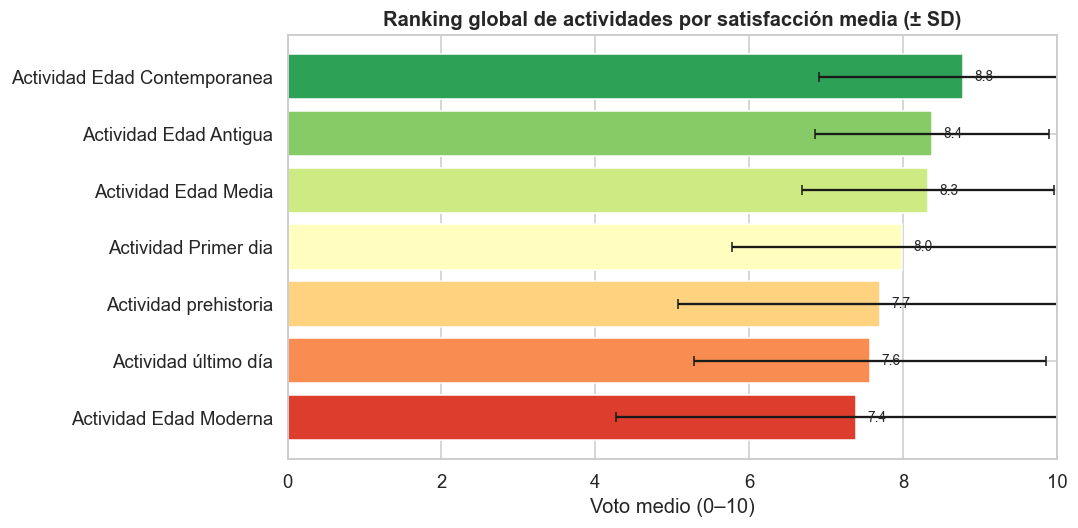

Figura guardada: votaciones_ranking_actividades.png


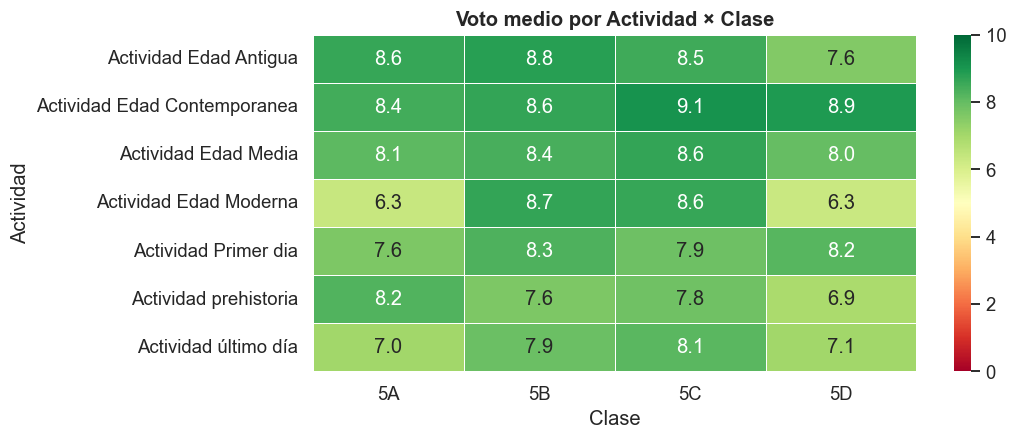

Figura guardada: votaciones_heatmap_clase.png


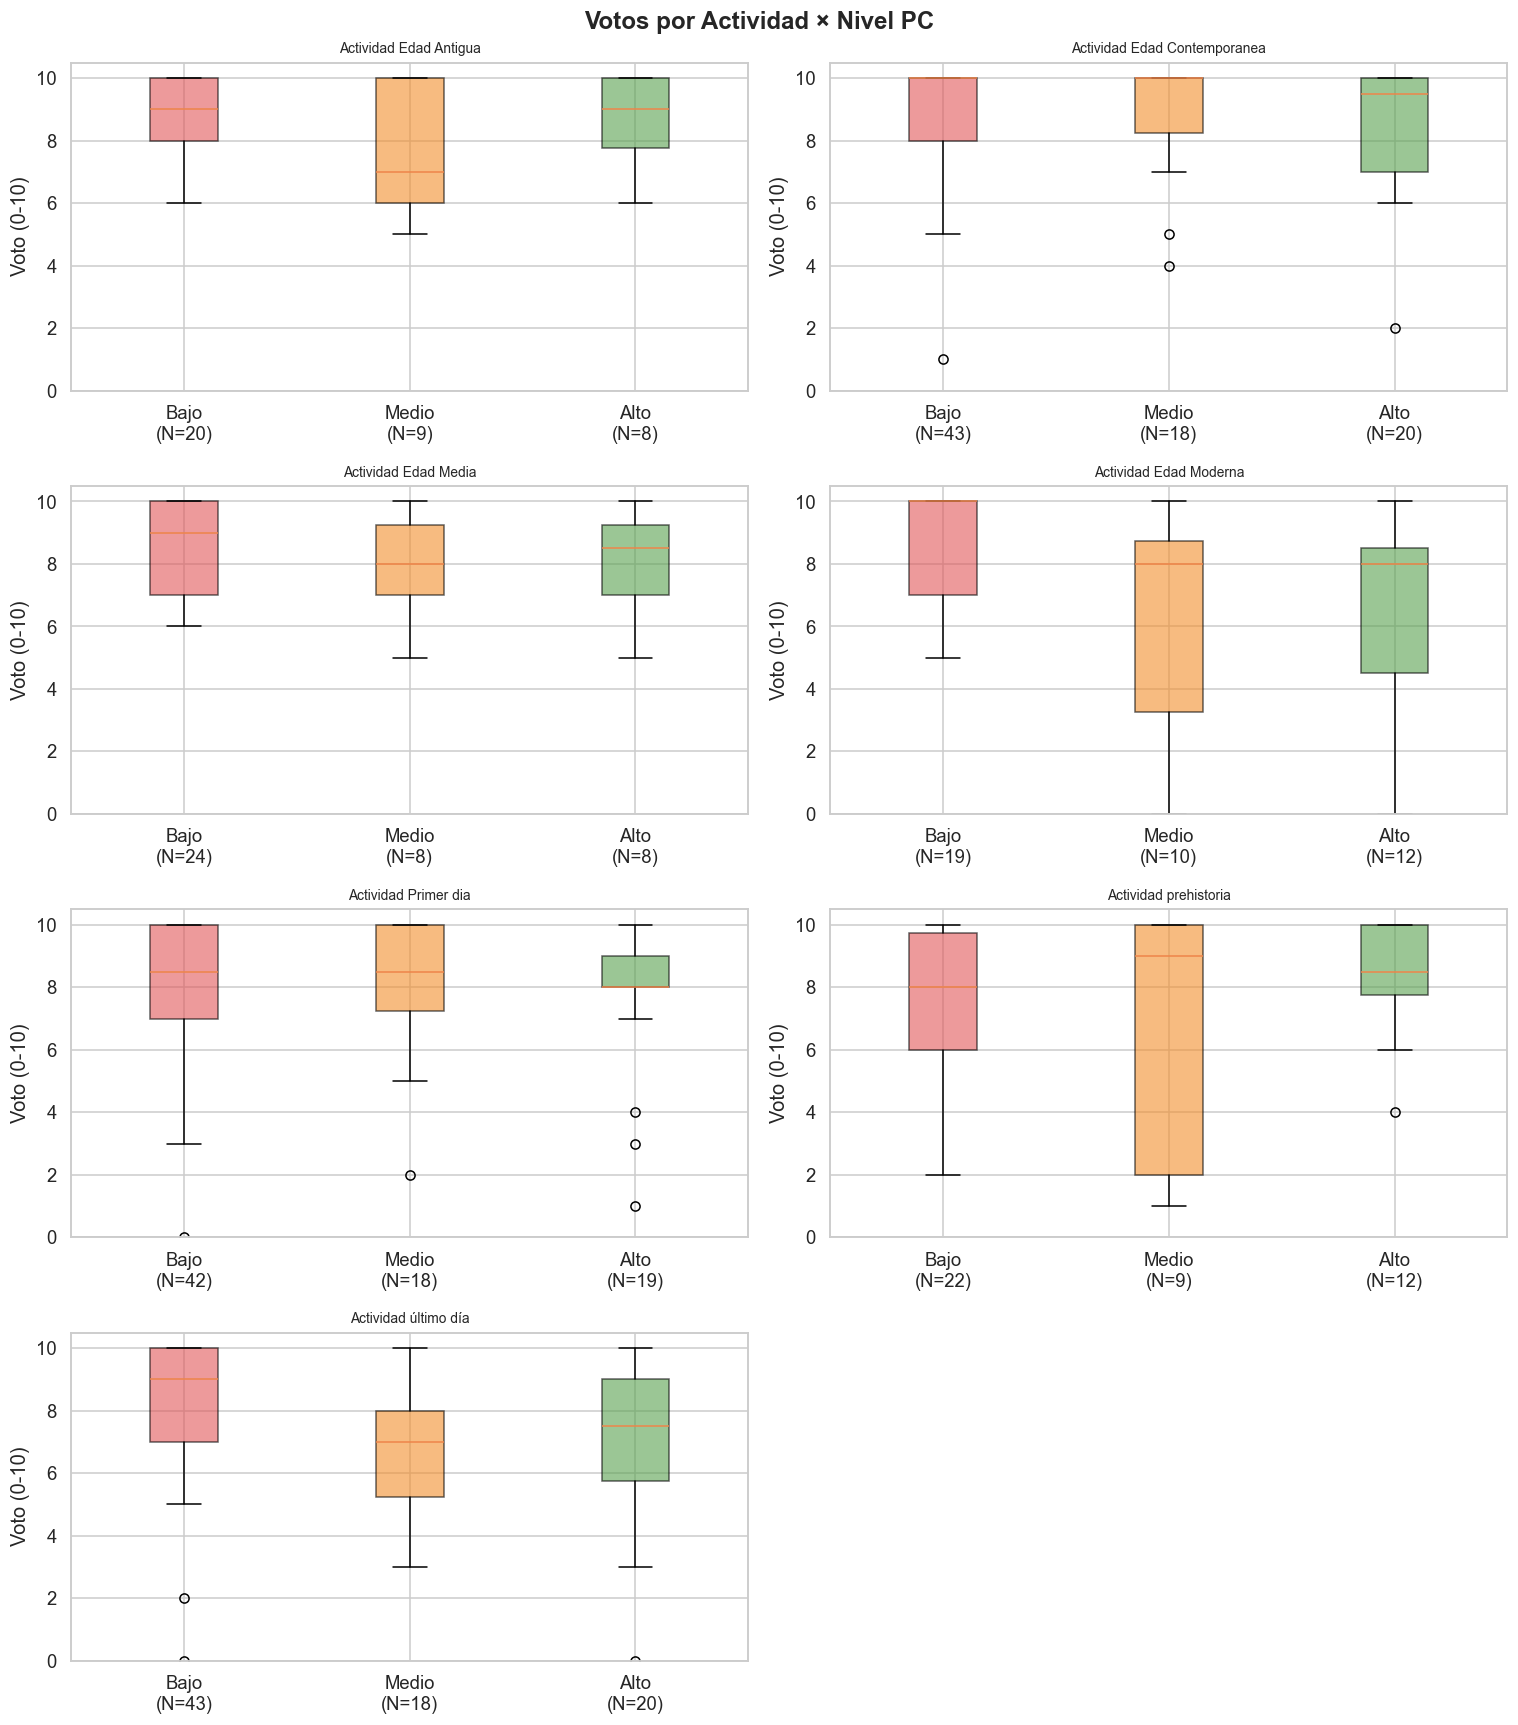

Figura guardada: votos_por_actividad_nivel_pc.png

Correlación Spearman voto_clase vs ganancia_clase: ρ=0.000 p=1.0000
  (N clases muy pequeño → interpretación orientativa)


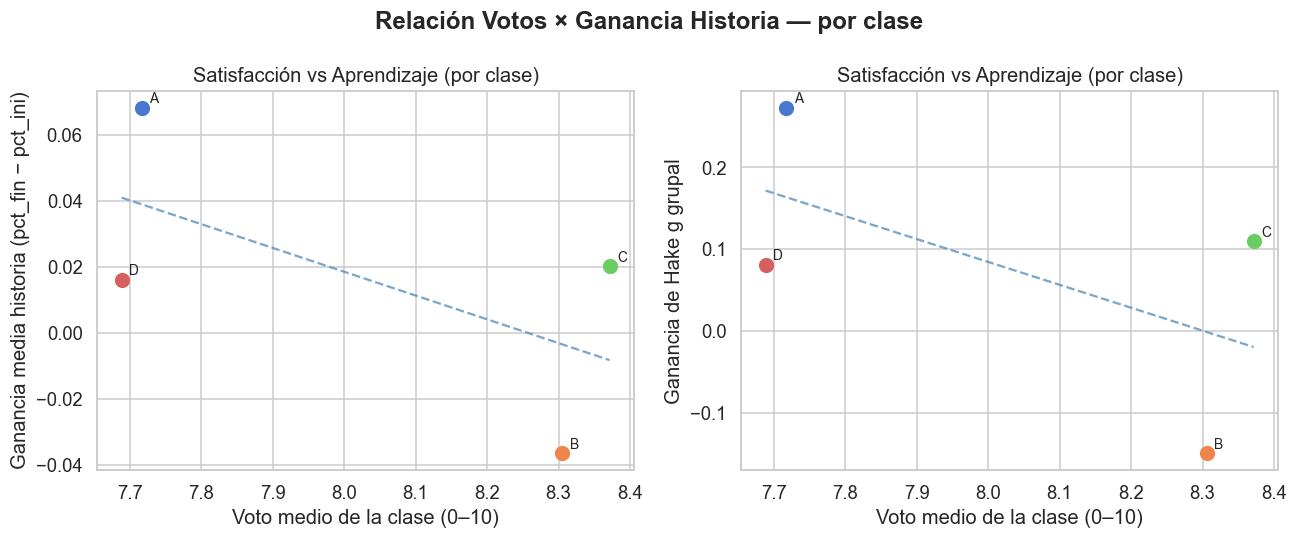

Figura guardada: votos_vs_ganancia_clase.png


In [11]:
# ─────────────────────────────────────────────────────────────────
# 8.1  Unificar hojas de votaciones en formato largo
# ─────────────────────────────────────────────────────────────────
logger.info("--- SECTION 8: Ratings ---")

df_votes_all_list = []
for sh_name, df_v in dfs_votes.items():
    df_v = df_v.copy()
    df_v.columns = [str(c).strip() for c in df_v.columns]
    if "Rating" in df_v.columns:
        df_v["Rating"] = ensure_numeric(df_v["Rating"], f"Voto/{sh_name}")
        out_range = df_v["Rating"].notna() & ~df_v["Rating"].between(0, 10)
        if out_range.sum() > 0:
            log_anomaly(f"Ratings '{sh_name}': {out_range.sum()} ratings outside [0,10] → NaN")
            df_v.loc[out_range, "Rating"] = np.nan
    df_votes_all_list.append(df_v)

df_votes = pd.concat(df_votes_all_list, ignore_index=True)
if "Actividad" in df_votes.columns:
    df_votes["Actividad"] = df_votes["Actividad"].astype(str).str.strip()

pct_missing_votes = (
    df_votes.groupby("Actividad")["Rating"]
    .apply(lambda x: x.isna().mean() * 100)
    .reset_index()
    .rename(columns={"Rating": "pct_missing"})
)
print("% Missing ratings by activity:")
display(style_table(pct_missing_votes, caption="% Missing ratings by activity"))
for _, row in pct_missing_votes.iterrows():
    if row["pct_missing"] > 0:
        log_anomaly(f"Votaciones: actividad='{row['Actividad']}' pct_missing={row['pct_missing']:.1f}%")

# ─────────────────────────────────────────────────────────────────
# 8.2  Unir nivel_pc a votaciones por Clase
# ─────────────────────────────────────────────────────────────────
df_votes["Clase_norm"] = df_votes["Clase"].astype(str).str.strip().str.replace(r"^\d+", "", regex=True)
nivel_map_simple = dict(zip(df_nivel_clase["Clase"], df_nivel_clase["nivel_pc"].astype(str)))
df_votes["nivel_pc"] = df_votes["Clase_norm"].map(nivel_map_simple)

print(f"\nRatings with ct_level assigned: {df_votes['nivel_pc'].notna().sum()}/{len(df_votes)}")
display(style_table(df_votes["nivel_pc"].value_counts(dropna=False).to_frame().reset_index(), caption="Rating distribution by CT level"))

# ─────────────────────────────────────────────────────────────────
# 8.3  Resumen por Actividad × nivel_pc
# ─────────────────────────────────────────────────────────────────
df_votes_resumen = (
    df_votes.dropna(subset=["Rating"])
    .groupby(["Actividad", "nivel_pc"])["Rating"]
    .agg(["mean", "median", "count", "std"])
    .reset_index()
    .rename(columns={"mean": "mean_rating", "median": "median_rating",
                     "count": "N", "std": "sd_rating"})
)
df_votes_resumen.to_csv(TABS / "votos_resumen_por_actividad_y_nivelpc.csv",
                         index=False, encoding="utf-8-sig")
print(f"\nRatings summary → {TABS / 'votos_resumen_por_actividad_y_nivelpc.csv'}")
display(style_table(df_votes_resumen, caption="Ratings summary by activity × CT level", bar_col="mean_rating" if "mean_rating" in df_votes_resumen.columns else None, bar_range=(0, 10)))

# ─────────────────────────────────────────────────────────────────
# 8.3b  Ranking global de actividades (voto medio)
# ─────────────────────────────────────────────────────────────────
ranking_actividades = (
    df_votes.dropna(subset=["Rating"])
    .groupby("Actividad")["Rating"]
    .agg(n_votos="count", media_global="mean", std_global="std", mediana="median")
    .sort_values("global_mean", ascending=False)
    .round(2)
    .reset_index()
)
ranking_actividades.insert(0, "Ranking", range(1, len(ranking_actividades) + 1))
ranking_actividades.to_csv(TABS / "votaciones_ranking_actividades.csv",
                            index=False, encoding="utf-8-sig")
print("\n=== Ranking global de actividades ===")
display(style_table(ranking_actividades, caption="Ranking de actividades por satisfacción media", bar_col="mean_rating" if "mean_rating" in ranking_actividades.columns else None, bar_range=(0, 10), highlight_max_col="mean_rating" if "mean_rating" in ranking_actividades.columns else None))

# Barplot ranking (horizontal, más satisfecha arriba)
fig_rank, ax_rank = plt.subplots(figsize=(10, max(5, len(ranking_actividades) * 0.55)))
colors_rank = sns.color_palette("RdYlGn_r", len(ranking_actividades))
actvs_sorted = ranking_actividades["Actividad"].tolist()[::-1]
medias_sorted = ranking_actividades["global_mean"].tolist()[::-1]
stds_sorted   = ranking_actividades["global_std"].tolist()[::-1]
bars_r = ax_rank.barh(actvs_sorted, medias_sorted,
                       xerr=stds_sorted, capsize=3,
                       color=colors_rank[::-1], edgecolor="white")
ax_rank.set_xlabel("Mean rating (0–10)")
ax_rank.set_title("Global activity ranking by mean satisfaction (± SD)",
                   fontweight="bold")
ax_rank.set_xlim(0, 10)
for bar, val in zip(bars_r, medias_sorted):
    ax_rank.text(val + 0.15, bar.get_y() + bar.get_height() / 2,
                 f"{val:.1f}", va="center", fontsize=9)
plt.tight_layout()
fig_rank.savefig(FIGS / "votaciones_ranking_actividades.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figure saved: votaciones_ranking_actividades.png")

# ─────────────────────────────────────────────────────────────────
# 8.3c  Heatmap votos medios por Actividad × Clase
# ─────────────────────────────────────────────────────────────────
vote_metrics_clase = (
    df_votes.dropna(subset=["Rating"])
    .groupby(["Actividad", "Clase"])["Rating"]
    .agg(n_votos="count", media="mean")
    .round(2)
    .reset_index()
)
pivot_votes = vote_metrics_clase.pivot(index="Actividad", columns="Clase", values="media")

fig_vm, ax_vm = plt.subplots(figsize=(10, max(4, len(pivot_votes) * 0.6)))
sns.heatmap(pivot_votes, annot=True, fmt=".1f", cmap="RdYlGn",
            linewidths=0.4, ax=ax_vm, vmin=0, vmax=10)
ax_vm.set_title("Mean rating by Activity × Class", fontweight="bold")
plt.tight_layout()
fig_vm.savefig(FIGS / "votaciones_heatmap_clase.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figure saved: votaciones_heatmap_clase.png")

# ─────────────────────────────────────────────────────────────────
# 8.4  Boxplot votos por actividad × nivel_pc
# ─────────────────────────────────────────────────────────────────
actividades = df_votes["Actividad"].dropna().unique()
n_act = len(actividades)

fig, axes = plt.subplots(
    int(np.ceil(n_act / 2)), 2,
    figsize=(14, 4 * int(np.ceil(n_act / 2))),
    squeeze=False,
)
ax_flat = axes.flatten()

for i, act in enumerate(sorted(actividades)):
    ax = ax_flat[i]
    sub = df_votes[df_votes["Actividad"] == act].dropna(subset=["Rating", "nivel_pc"])
    if sub.empty:
        ax.set_visible(False)
        continue
    order_n = [n for n in niv_order if n in sub["nivel_pc"].values]
    if not order_n:
        ax.set_visible(False)
        continue
    data_n = [sub.loc[sub["nivel_pc"] == n, "Rating"].values for n in order_n]
    bp = ax.boxplot(data_n,
                    labels=[f"{n}\n(N={len(d)})" for n, d in zip(order_n, data_n)],
                    patch_artist=True)
    for patch, col in zip(bp["boxes"], ["#E15759", "#F28E2B", "#59A14F"]):
        patch.set_facecolor(col)
        patch.set_alpha(0.6)
    ax.set_ylim(0, 10.5)
    act_label = act[:30] + "..." if len(act) > 30 else act
    ax.set_title(act_label, fontsize=9)
    ax.set_ylabel("Rating (0-10)")

for j in range(i + 1, len(ax_flat)):
    ax_flat[j].set_visible(False)

fig.suptitle("Ratings by Activity × CT Level", fontweight="bold")
fig.tight_layout()
fig.savefig(FIGS / "votos_por_actividad_nivel_pc.png", dpi=110, bbox_inches="tight")
plt.show()
print("Figure saved: votos_por_actividad_nivel_pc.png")

# ─────────────────────────────────────────────────────────────────
# 8.5  Relación votos vs ganancia historia (por clase)
#       Scatter con regresión (equivalente al voto-vs-Hake del notebook anterior)
# ─────────────────────────────────────────────────────────────────
votes_por_clase = (
    df_votes.dropna(subset=["Rating"])
    .groupby("Clase")["Rating"]
    .mean()
    .reset_index()
    .rename(columns={"Rating": "mean_rating_class"})
)
# ⚠ Muestras independientes: la ganancia por clase viene de df_hake_clase
ganancia_por_clase_v = (
    df_hake_clase[["Clase", "ganancia_abs"]]
    .rename(columns={"ganancia_abs": "ganancia"})
    .copy()
)
votes_por_clase["Clase_norm"]      = votes_por_clase["Clase"].astype(str).str.replace(r"^\d+", "", regex=True)
ganancia_por_clase_v["Clase_norm"] = ganancia_por_clase_v["Clase"].astype(str).str.replace(r"^\d+", "", regex=True)

df_voto_ganancia = votes_por_clase.merge(
    ganancia_por_clase_v[["Clase_norm", "ganancia"]], on="Clase_norm", how="inner"
)

# Añadir Hake grupal
df_hake_merge = df_hake_clase[["Clase", "hake_g"]].copy()
df_hake_merge["Clase_norm"] = df_hake_merge["Clase"].astype(str).str.replace(r"^\d+", "", regex=True)
df_voto_ganancia = df_voto_ganancia.merge(
    df_hake_merge[["Clase_norm", "hake_g"]], on="Clase_norm", how="left"
)
df_voto_ganancia.to_csv(TABS / "voto_vs_ganancia.csv", index=False, encoding="utf-8-sig")

if len(df_voto_ganancia) >= 3:
    r_sp, p_sp = stats.spearmanr(df_voto_ganancia["mean_rating_class"],
                                   df_voto_ganancia["ganancia"])
    print(f"\nSpearman correlation rating_class vs gain_class: ρ={r_sp:.3f} p={p_sp:.4f}")
    print("  (N classes very small → indicative interpretation)")

    fig4, axes4 = plt.subplots(1, 2, figsize=(12, 5))
    for ax, y_col, y_lbl in zip(
        axes4,
        ["ganancia", "hake_g"],
        ["Mean history gain (pct_fin − pct_ini)", "Group Hake Gain g"],
    ):
        for _, row in df_voto_ganancia.iterrows():
            ax.scatter(row["mean_rating_class"], row[y_col], s=80, zorder=5)
            ax.annotate(row["Clase_norm"], (row["mean_rating_class"], row[y_col]),
                        textcoords="offset points", xytext=(5, 3), fontsize=9)
        # Línea de regresión si hay suficientes datos
        valid = df_voto_ganancia[["mean_rating_class", y_col]].dropna()
        if len(valid) >= 3:
            m, b = np.polyfit(valid["mean_rating_class"], valid[y_col], 1)
            x_line = np.linspace(valid["mean_rating_class"].min(),
                                  valid["mean_rating_class"].max(), 100)
            ax.plot(x_line, m * x_line + b, "--", color="steelblue", lw=1.5, alpha=0.7)
        ax.set_xlabel("Class mean rating (0–10)")
        ax.set_ylabel(y_lbl)
        ax.set_title("Satisfaction vs Learning (by class)")
    fig4.suptitle("Rating × History Gain Relationship — by class",
                   fontweight="bold")
    plt.tight_layout()
    fig4.savefig(FIGS / "votos_vs_ganancia_clase.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Figure saved: votos_vs_ganancia_clase.png")
else:
    print("Insufficient classes with rating+gain data for rating-gain correlation")

### 8 · Ratings Section Summary

#### What was done and why?

**8.1–8.2  Ratings unification and enrichment**
All rating sheets are consolidated into a single long dataset and the CT level of each class is incorporated by joining with `df_nivel_clase`. Ratings outside the [0, 10] range are recorded as anomalies and excluded from analysis.

**8.3  Summary by Activity × CT level**
Allows seeing whether activities are rated differently depending on the CT level of the students. Exported to `votos_resumen_por_actividad_y_nivelpc.csv`.

**8.3b  Global activity ranking**
Lists activities from highest to lowest mean satisfaction with CI (±SD), equivalent to Section 10 of the reference notebook. Useful for prioritising which activities to repeat or reformulate. Exported to `votaciones_ranking_actividades.csv`.

**8.3c  Heatmap of mean ratings by Activity × Class**
Facilitates visual comparison between classes and detects whether an activity is rated very differently between groups. Exported as `votaciones_heatmap_clase.png`.

**8.4  Boxplots of ratings by activity × CT level**
Shows the complete distribution of ratings for each activity separated by CT level, detecting outliers and asymmetries.

**8.5  Satisfaction vs learning correlation (by class)**
Compares the class mean rating with its History gain and its group Hake gain. If the correlation is positive, the highest-rated activities are also those that produce the greatest learning. Exported as `votos_vs_ganancia_clase.png`.


### 9.1 Problem Decomposition

The problem is decomposed into nested layers:

**A) Student level (CT):** Each of the 97 Echegaray students took a 28-item test
whose responses (letters A/B/C/D) were compared against the correction key
(`especificacion_items.csv`), generating a continuous score `score_pc ∈ [0, 28]`.

**B) Class level (CT → History):** The means of `pct_pc` by class were ranked using
tertiles to assign a qualitative level {Low, Medium, High}. This level is "exported"
to the History data (Juan Echegaray) via the mapping `CT Class → History Class`.
For any other school present in the History data, the level remains NaN
to avoid imputation.

**C) Item level (History):** Each History item (P1-P8 initial, P1-P11 final)
has a thematic category (Algorithmics, Prehistory, Middle Ages…) extracted from
`category_questions.xlsx`. Converting to long format allows calculating difficulty
by category, timepoint and CT level simultaneously.

**D) Activity level (Ratings):** The 7 activities are unified into a single long format;
the CT level of the class is joined to compare ratings between groups.


### 9.2 Detected Patterns

**Difficult items (% correct < 33%):** Visible in the heatmap `pc_heatmap_items_clase.png`.
Items with the highest difficulty tend to coincide with concepts of greater abstraction
(complex Conditionals, Functions). The `pct_Debugging` dimension tends to score
lower than `pct_Sequencing`, which is consistent with the literature on CT in Primary Education.

**Profiles by CT level:**
- **High**-level classes show more compact distributions (lower SD) and skewed
  towards high scores, suggesting internal homogeneity.
- **Low**-level classes show greater variance, with extreme students in both directions.

**Frequent co-errors:** Items in the Conditionals block (items 13-24 per spec)
show positive correlations with each other, indicating a shared error pattern.
This may reflect insufficient instruction in that concept or inherent cognitive difficulty
at this age.


### 9.3 Abstraction

Three levels of abstraction have been created for CT performance:

1. **Raw score** (`score_pc`): direct sum of correct answers, scale 0-28.
2. **Proportion** (`pct_pc`): normalised to [0,1]; facilitates comparisons between tests
   with different numbers of items.
3. **Class level** (`nivel_pc` ∈ {Low, Medium, High}): tertile on class mean;
   categorical abstraction for cross-analyses with History and Ratings.

In History:
- `pct_hist_ini` and `pct_hist_fin`: proportions over 8 and 11 items respectively.
- `ganancia_abs`: class mean difference (`pct_fin_class − pct_ini_class`) — calculated at **class** level, not individual student, given the independent samples design.
- `hake_g`: group Hake gain (`g = (μ_fin − μ_ini) / (1 − μ_ini)`) calculated on class means; avoids ceiling effect.


### 9.4 Pipeline Algorithm and Decision Rules

The pipeline follows these coded rules:

```
FOR EACH two-group contrast:
  IF N(group) < 3 → skip Shapiro, use MWU
  IF N(SEN=Yes) < 10 → prioritise descriptive + bootstrap CI + warning
  ELSE:
    Shapiro on each group:
      IF both p_shapiro > 0.05 AND N < 50 → Welch-t; effect = Hedges g
      ELSE → Mann-Whitney; effect = rank-biserial
  ALWAYS: permutation test (5000 iterations) for robustness

FOR CT Level by class:
  TRY pd.qcut(q=3) → if fails due to duplicates → dense ranking + manual cutoffs

FOR History (independent samples):
  df_ini = Initial test (one row per student; Student = response order)
  df_fin = Final test  (different N per class — NOT individually pairable)
  ct_level: join by Class only if School contains "Echegaray"; else NaN (DO NOT impute)
  Hake: calculated on class means (g = (μ_fin - μ_ini) / (1 - μ_ini))
```


### 9.5 Analysis Evaluation / Debugging

**Quality audit:**
- All datasets pass through `audit_df()` which reports %NaN by column, ranges and duplicates.
- Corrections (out-of-range values, recalculated TOTAL, Gender/SEN encodings)
  are written to `outputs/logs/data_quality.log`.

**SEN imbalance:**
- With N(SEN=Yes) ≈ 8, the p-value of any test is highly unstable.
  It is explicitly reported that strong conclusions should not be drawn.
  The permutation test is more robust than the asymptotic one in this scenario,
  but the effect size with bootstrap CI is the most reliable information.

**Self-perception without ID:**
- Since there is no ID column in the self-perception dataset, the relationship with actual
  performance can only be established at group aggregate level (group mean vs mean pct_pc
  of the same Gender/SEN group). This is declared as an **explicit limitation** and NO
  individual correlations are performed.

**CT level with few classes:**
- With only 4 classes, the tertiles collapse to ranges: the class with the lowest mean → Low,
  the central one (if 4, the second) → Medium, etc. The exact distribution
  is recorded in the log and in `nivel_pc_por_clase.csv`.


## 10. Quality Gates — Automatic Output Verification

**What this section does:** Runs a battery of automatic checks on the existence and size of each expected output file (CSV tables and PNG figures), and verifies key data invariants: N students in initial and final History tests (independent samples), group Hake gain per class, presence of the CT level column in all datasets that require it, number of unique activities in ratings.

**Why:** A reproducible analysis does not end with the last code cell: it must verify that *all* its outputs are complete and intact. If any gate fails, the message indicates exactly which file or invariant is missing, allowing relaunching only the corresponding section without repeating the entire notebook.

> **PASS on all gates** → The analysis is correct, complete and reproducible.
> **FAIL on any gate** → Review and re-run the section indicated in the error message.


In [11]:
# ─────────────────────────────────────────────────────────────────
# 10.1  Verificar existencia de todos los outputs esperados
# ─────────────────────────────────────────────────────────────────
logger.info("--- SECTION 10: Quality Gates ---")

expected_tables = [
    # PC
    "auditoria_datasets.csv",
    "pc_limpio_por_alumno.csv",
    "pc_descriptivo_global.csv",
    "pc_descriptivo_por_grupo.csv",
    "pc_por_item_y_clase.csv",
    "pc_por_dimension.csv",
    "pc_contraste_genero.csv",
    "pc_contraste_nee.csv",
    "pc_decision_metodologica.csv",
    # Autopercepción
    "autopercepcion_descriptivo.csv",
    "autopercepcion_contrastes.csv",
    # Nivel PC
    "nivel_pc_por_clase.csv",
    # Historia — base
    "historia_resumen_por_grupo.csv",
    "historia_contrastes.csv",
    "historia_categoria_stats.csv",
    # Historia — análisis enriquecido (7.10–7.14)
    "historia_hake_por_clase.csv",
    "historia_efectos.csv",
    "historia_omnibus_clases.csv",
    "historia_analisis_items.csv",
    # Votaciones
    "votos_resumen_por_actividad_y_nivelpc.csv",
    "votaciones_ranking_actividades.csv",
]

expected_figures = [
    # PC
    "pc_histograma_global.png",
    "pc_violin_por_grupo.png",
    "pc_heatmap_items_clase.png",
    "pc_acierto_por_dimension.png",
    "pc_qqplot_genero.png",
    "pc_qqplot_nee.png",
    "pc_contraste_grupos.png",
    # Autopercepción
    "autopercepcion_por_genero.png",
    "autopercepcion_vs_rendimiento_agregado.png",
    # Nivel PC
    "pc_nivel_por_clase.png",
    # Historia — base (7.8)
    "historia_distribucion.png",
    "historia_ganancia_por_nivel_pc.png",
    "historia_rendimiento_por_clase.png",
    # Historia — Hake grupal (7.10)
    "historia_hake_por_clase.png",
    # Historia — distribuciones por clase (7.11)
    "historia_boxplot_ini_fin_clase.png",
    "historia_medias_ini_fin_clase.png",
    "historia_histograma_global.png",
    # Historia — tamaños de efecto (7.12)
    "historia_effect_sizes.png",
    # Historia — ANOVA inter-clases (7.13)
    "historia_comparacion_clases.png",
    # Historia — psicometría (7.14)
    "historia_heatmap_items.png",
    "historia_coerror_matrix.png",
    # Votaciones
    "votos_por_actividad_nivel_pc.png",
    "votaciones_ranking_actividades.png",
    "votaciones_heatmap_clase.png",
    "votos_vs_ganancia_clase.png",
]

print("=" * 65)
print("QUALITY GATES: Output verification")
print("=" * 65)

all_ok = True
print(f"\n[ TABLAS — {len(expected_tables)} esperadas ]")
for f in expected_tables:
    path = TABS / f
    status = "✓ OK  " if path.exists() else "✗ MISSING"
    if not path.exists():
        all_ok = False
    print(f"  {status}  {f}")

print(f"\n[ FIGURAS — {len(expected_figures)} esperadas ]")
for f in expected_figures:
    path = FIGS / f
    status = "✓ OK  " if path.exists() else "✗ MISSING"
    if not path.exists():
        all_ok = False
    print(f"  {status}  {f}")

# ─────────────────────────────────────────────────────────────────
# 10.2  Resumen final de métricas clave
# ─────────────────────────────────────────────────────────────────

# ── Tabla resumen de quality gates ─────────────────────────────────────────
_gate_rows = []
for _f in expected_tables:
    _gate_rows.append({"Type": "Table", "File": _f, "Status": "PASS" if (TABS / _f).exists() else "FAIL"})
for _f in expected_figures:
    _gate_rows.append({"Type": "Figure", "File": _f, "Status": "PASS" if (FIGS / _f).exists() else "FAIL"})
_df_gates = pd.DataFrame(_gate_rows)

def _style_gate_status(v):
    if v == "PASS":
        return "background-color: #d4edda; color: #155724; font-weight: bold"
    elif v == "FAIL":
        return "background-color: #f8d7da; color: #721c24; font-weight: bold"
    return ""

display(
    _df_gates.style
    .set_caption("Quality Gates — Status of all expected outputs")
    .set_table_styles(_HEADER_STYLE)
    .map(_style_gate_status, subset=["Status"])
    .hide(axis="index")
)
del _gate_rows, _df_gates, _style_gate_status

print(f"\n{'=' * 65}")
print("FINAL SUMMARY")
print(f"{'=' * 65}")

n_pc_total    = len(df_pc)
n_chico       = (df_pc["Género"] == "Boy").sum()
n_chica       = (df_pc["Género"] == "Girl").sum()
n_nee_si_final = (df_pc["NEE"] == "Yes").sum()
n_nee_no_final = (df_pc["NEE"] == "No").sum()

print(f"\nPC Test Inicial:")
print(f"  Total N CT              : {n_pc_total}")
print(f"  Gender Boy              : {n_chico}")
print(f"  Gender Girl             : {n_chica}")
print(f"  SEN = Yes              : {n_nee_si_final}")
print(f"  SEN = No               : {n_nee_no_final}")

print(f"\nCT Level by Class:")
for _, row in df_nivel_clase.iterrows():
    n_alumnos = (df_pc["Clase"] == row["Clase"]).sum()
    print(f"  Clase {row['Clase']}: {row['nivel_pc']:6s} | mean_pct={row['mean_pct_pc']:.3f} | N={n_alumnos}")

# ⚠ Muestras independientes: no existe df_paired → usar df_ini, df_fin, df_hake_clase
print(f"\nHistory (independent samples):")
print(f"  N Initial              : {len(df_ini)}")
print(f"  N Final               : {len(df_fin)}")
print(f"  Mean abs. gain by class (pct_fin − pct_ini):")

if "df_hake_clase" in dir() and not df_hake_clase.empty:
    for _, row in df_hake_clase.iterrows():
        print(f"    Clase {row['Clase']}: Δ={row['ganancia_abs']:+.3f}  Hake g={row['hake_g']:+.3f}  ({row['categoria_hake']})")
    global_ini_qg  = df_ini["pct_hist"].mean()
    global_fin_qg  = df_fin["pct_hist"].mean()
    global_hake_qg = (global_fin_qg - global_ini_qg) / (1 - global_ini_qg) \
                     if (1 - global_ini_qg) > 0 else float("nan")
    print(f"  Global group Hake       : g={global_hake_qg:+.3f}")

print(f"\nRatings:")
pct_miss_tot = df_votes["Rating"].isna().mean() * 100
print(f"  N records              : {len(df_votes)}")
print(f"  % global missing       : {pct_miss_tot:.1f}%")
for _, row in pct_missing_votes.iterrows():
    if row["pct_missing"] > 0:
        act_s = str(row["Actividad"])[:40]
        print(f"  {act_s:40s}: {row['pct_missing']:.1f}% missing")

# ─────────────────────────────────────────────────────────────────
# 10.3  Anomalías y decisiones metodológicas registradas
# ─────────────────────────────────────────────────────────────────
print(f"\n{'=' * 65}")
print("ANOMALIES AND METHODOLOGICAL DECISIONS RECORDED")
print(f"{'=' * 65}")
print(f"  See full log in: {log_path.resolve()}")

decisiones = [
    f"CT format detected: {fmt_detected}",
    f"Conversiones letras→0/1: {n_conversiones}",
    f"NEE desequilibrio: N(Sí)={n_nee_si_final} → " +
    ("MWU+bootstrap; no strong conclusions" if n_nee_si_final < 10 else "automatic test"),
    "Self-perception: NO common ID → aggregate group analysis only",
    "CT level: tertiles on class mean " +
    ("(qcut)" if n_clases >= 3 else "(dense ranking, few classes)"),
    "History: TOTAL recalculated where discrepant",
    "History: ct_level=NaN for classes outside Echegaray",
    "Ratings: values outside [0,10] → NaN",
]
for i, d in enumerate(decisiones, 1):
    print(f"  [{i}] {d}")

if all_ok:
    print(f"\n{'=' * 65}")
    print("  ✓ ALL OUTPUTS VERIFIED CORRECTLY")
    print(f"{'=' * 65}")
else:
    print(f"\n{'=' * 65}")
    print("  [!] SOME OUTPUTS NOT FOUND (see details above)")
    print(f"{'=' * 65}")

logger.info("=== Analysis completed ===")
print(f"\nFull log: {log_path.resolve()}")

2026-05-22 13:26:24,785 [INFO] --- SECCIÓN 10: Quality Gates ---
QUALITY GATES: Verificación de outputs

[ TABLAS — 21 esperadas ]
  ✓ OK    auditoria_datasets.csv
  ✓ OK    pc_limpio_por_alumno.csv
  ✓ OK    pc_descriptivo_global.csv
  ✓ OK    pc_descriptivo_por_grupo.csv
  ✓ OK    pc_por_item_y_clase.csv
  ✓ OK    pc_por_dimension.csv
  ✓ OK    pc_contraste_genero.csv
  ✓ OK    pc_contraste_nee.csv
  ✓ OK    pc_decision_metodologica.csv
  ✓ OK    autopercepcion_descriptivo.csv
  ✓ OK    autopercepcion_contrastes.csv
  ✓ OK    nivel_pc_por_clase.csv
  ✓ OK    historia_resumen_por_grupo.csv
  ✓ OK    historia_contrastes.csv
  ✓ OK    historia_categoria_stats.csv
  ✓ OK    historia_hake_por_clase.csv
  ✓ OK    historia_efectos.csv
  ✓ OK    historia_omnibus_clases.csv
  ✓ OK    historia_analisis_items.csv
  ✓ OK    votos_resumen_por_actividad_y_nivelpc.csv
  ✓ OK    votaciones_ranking_actividades.csv

[ FIGURAS — 25 esperadas ]
  ✓ OK    pc_histograma_global.png
  ✓ OK    pc_violin_por_

Tipo,Archivo,Estado
Tabla,auditoria_datasets.csv,PASS
Tabla,pc_limpio_por_alumno.csv,PASS
Tabla,pc_descriptivo_global.csv,PASS
Tabla,pc_descriptivo_por_grupo.csv,PASS
Tabla,pc_por_item_y_clase.csv,PASS
Tabla,pc_por_dimension.csv,PASS
Tabla,pc_contraste_genero.csv,PASS
Tabla,pc_contraste_nee.csv,PASS
Tabla,pc_decision_metodologica.csv,PASS
Tabla,autopercepcion_descriptivo.csv,PASS



RESUMEN FINAL

PC Test Inicial:
  N total PC              : 97
  Género Chico            : 52
  Género Chica            : 45
  NEE = Sí                : 8
  NEE = No                : 89

Nivel PC por Clase:
  Clase A: Alto   | mean_pct=0.661 | N=24
  Clase B: Bajo   | mean_pct=0.610 | N=23
  Clase C: Bajo   | mean_pct=0.552 | N=26
  Clase D: Medio  | mean_pct=0.616 | N=24

Historia (muestras independientes):
  N Inicial               : 93
  N Final                 : 82
  Ganancia abs. media por clase (pct_fin − pct_ini):
    Clase 5A: Δ=+0.068  Hake g=+0.273  (Baja (<0.30))
    Clase 5B: Δ=-0.036  Hake g=-0.149  (Baja (<0.30))
    Clase 5C: Δ=+0.020  Hake g=+0.110  (Baja (<0.30))
    Clase 5D: Δ=+0.016  Hake g=+0.081  (Baja (<0.30))
  Hake grupal global      : g=+0.069

Votaciones:
  N registros             : 567
  % missing global        : 29.1%
  Actividad Edad Antigua                  : 54.3% missing
  Actividad Edad Media                    : 50.6% missing
  Actividad Edad Moderna